# Proyecto Final: Predicción del Éxito Académico en Educación Superior

**Asignatura:** Aprendizaje Automático

**Nombre:** Rodrigo Alejandro Sicilia Maroto

**Curso:** 2025/2026  

---

Este notebook recoge el trabajo completo del proyecto final. La idea es trabajar con un dataset real sobre la trayectoria académica de estudiantes universitarios y, a partir de él, desarrollar las tres tareas que se han planteado en el enunciado, las cuales son, una de clasificación, una de regresión y una de aprendizaje no supervisado. Por el camino se hace un análisis exploratorio detallado, se justifica cada decisión de preprocesado, se comparan varios modelos, se analizan los resultados que se van obteniendo y se sacan conclusiones.

La estrucutara del notebook es:

1. Importaciones y carga de datos.
2. Análisis exploratorio (EDA) con observaciones y análisis de patrones de comportamiento.
3. Preprocesado: codificación, agrupación de categorías raras, división train/test y escalado.
4. **Tarea 1 - Clasificación**: predecir la variable objetivo (abandono / matriculado / graduado).
5. **Tarea 2 - Regresión**: predecir la variable nota_media_2sem evitando fuga de información.
6. **Tarea 3 - Aprendizaje no supervisado**: PCA y clustering.
7. Interpretación global y conclusiones.

## 1. Importaciones y Carga de Datos

In [1]:
#Librerias principales 
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Preprocesado y validación
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

#Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#Modelos de regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

#Aprendizaje no supervisado (para la tarea 3)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

#Métricas
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42  # Semilla común para hacer reproducibles los experimentos.
N_JOBS = min(4, os.cpu_count() or 1)  # Evita saturar equipos con muchos núcleos.
np.random.seed(RANDOM_STATE)
print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [2]:
# Carga del dataset
# El CSV usa punto y coma como delimitador. Se contemplan las dos ubicaciones
# habituales de ejecución: la raíz del repositorio y la carpeta notebooks/.
data_candidates = [
    Path('../data/rendimiento_estudiantes.csv'),
    Path('data/rendimiento_estudiantes.csv'),
    Path('rendimiento_estudiantes.csv'),
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        'No se encontró rendimiento_estudiantes.csv. '
        'Ejecuta el notebook desde la raíz del repositorio o desde notebooks/.'
    )

df = pd.read_csv(DATA_PATH, sep=';')
print(f'Dataset cargado desde {DATA_PATH.as_posix()}')
print(f'{df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado desde ../data/rendimiento_estudiantes.csv
4424 filas x 37 columnas


,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,ocupacion_madre,ocupacion_padre,nota_admision,desplazado,necesidades_educativas_especiales,deudor,matricula_al_dia,genero,becado,edad_al_matricularse,internacional,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,trabajadoras_de_servicios_personales_seguridad...,trabajadores_no_cualificados,127.3,si,no,no,si,hombre,no,20,no,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,tecnicos_y_profesiones_de_nivel_intermedio,tecnicos_y_profesiones_de_nivel_intermedio,142.5,si,no,no,no,hombre,no,19,no,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,trabajadoras_no_cualificadas,trabajadores_no_cualificados,124.8,si,no,no,no,hombre,no,19,no,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,trabajadoras_de_servicios_personales_seguridad...,tecnicos_y_profesiones_de_nivel_intermedio,119.6,si,no,no,si,mujer,no,20,no,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,trabajadoras_no_cualificadas,trabajadores_no_cualificados,141.5,no,no,no,si,mujer,no,45,no,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


## 2. Análisis Exploratorio de Datos (EDA)

Antes de entrenar ningún modelo, hace falta entender bien con que datos se trabaja. En este EDA se hará lo siguiente: comprobar la estructura del dataset, mirar distribuciones, detectar valores faltantes o atípicos, ver cómo se relacionan las variables entre sí y con el objetivo, y en general entender mejor lo datos. Todo lo que se haga después, como decisiones de preprocesado, elección de modelos, interpretación de resultados, se apoya en lo que se observa aquí.

El objetivo del EDA no es sacar conclusiones definitivas, sino formar hipótesis y guiar las decisiones posteriores.

### 2.1 Estructura general del dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    4424 non-null   objec

In [4]:
# Identificamos columnas numéricas y categóricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas ({len(cols_numericas)}): {cols_numericas}')
print(f'\nVariables categóricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numéricas (19): ['orden_solicitud', 'nota_cualificacion_previa', 'nota_admision', 'edad_al_matricularse', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion', 'tasa_desempleo', 'tasa_inflacion', 'pib']

Variables categóricas (18): ['estado_civil', 'modo_solicitud', 'curso', 'asistencia_diurna_vespertina', 'cualificacion_previa', 'nacionalidad', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'desplazado', 'necesidades_educativas_especiales', 'deudor', 'matricula_al_dia', 'genero', 'becado', 'internacional', 'objetivo']


Tenemos 19 variables numéricas, principalmente, notas, contadores de asignaturas, edad, variables macroeconómicas y 18 categóricas, (estado civil, vía de acceso, ocupaciones de los padres, y también variables que son binarias). La variable objetivo es categórica con tres clases, como se dice en el enunciado.

Estos resultado permiten tomar algunas decisiones de preprocesado. Las 18 variables categóricas habrá que codificarlas de alguna forma. Para las binarias es trivial (se convierten a 0/1), pero las que tienen muchas categorías (como ocupacion_padre) requieren más cuidado, aplicar one-hot encoding sin más generaría decenas de columnas nuevas, muchas de ellas casi vacías, lo que introduciría ruido y haría que se tuvieran muchísimas dimensiones. Se volverá a este punto en la sección de preprocesado.

### 2.2 Análisis de valores faltantes

Los valores faltantes son uno de los primeros problemas que hay que descartar antes de seguir. Un NaN en una variable puede hacer que un modelo falle al entrenar o produzca resultados poco fiables, y obliga a tomar decisiones adicionales, como hemos visto en la asignatura de adquisición de datos. Algunas de estas medidas son por ejemplo: eliminar filas, imputar con la media o la mediana... Por eso conviene revisar si existen antes de entrar en más detalle.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_info = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_info = missing_info[missing_info['Faltantes'] > 0]

if len(missing_info) == 0:
    print('No hay valores faltantes en el dataset.')
else:
    print('Variables con valores faltantes:')
    print(missing_info)

No hay valores faltantes en el dataset.


No hay ningún valor faltante en las 37 columnas. Esto simplifica bastante el preprocesado porque nos ahorra tomar decisiones de imputación, que siempre introducen cierto sesgo dependiendo del criterio que se use (media, mediana, moda, KNN imputation, etc.). Podemos avanzar al siguiente paso con la tranquilidad de que el dataset está completo.

### 2.2b Coherencia interna de las variables de conteo

Antes de pasar al análisis del objetivo merece la pena un control de calidad sobre las variables que cuentan asignaturas. A primera vista uno esperaría que se cumplan varias restricciones lógicas en cada semestre:

- evaluadas ≤ matriculadas + convalidadas —> no deberías tener más evaluaciones que asignaturas (matriculadas + reconocidas de estudios previos).

- aprobadas ≤ matriculadas —> no puedes aprobar asignaturas que no matriculaste.

- sin_evaluacion ≤ evaluadas —> solo tiene sentido contar "no presentadas" dentro de las evaluaciones registradas.

- matriculadas ≥ convalidadas —> si esta restricción se cumple en el 100% de los casos, muy probablemente las convalidadas estén contabilizadas dentro de las matriculadas de ese semestre (y no como un conjunto disjunto).

Comprobarlas nos sirve para dos cosas: detectar errores de codificación y, si todo cuadra, entender qué mide exactamente cada variable (porque el nombre puede ser engañoso), puede ser que se este interpretando mal alguna variable.

In [6]:
# Chequeo de restricciones lógicos sobre las cinco variables de conteo
print('Porcentaje de estudiantes que cumplen cada restricción:')
print()
print(f'{"restricciones":<48} {"1sem":>10} {"2sem":>10}')
print('-' * 70)

total = len(df)
restricciones = [
    ('evaluadas <= matriculadas + convalidadas',
     lambda s: df[f'asignaturas_{s}_evaluadas'] <= df[f'asignaturas_{s}_matriculadas'] + df[f'asignaturas_{s}_convalidadas']),
    ('aprobadas <= matriculadas',
     lambda s: df[f'asignaturas_{s}_aprobadas'] <= df[f'asignaturas_{s}_matriculadas']),
    ('sin_evaluacion <= evaluadas',
     lambda s: df[f'asignaturas_{s}_sin_evaluacion'] <= df[f'asignaturas_{s}_evaluadas']),
    ('matriculadas >= convalidadas',
     lambda s: df[f'asignaturas_{s}_matriculadas'] >= df[f'asignaturas_{s}_convalidadas']),
]
for label, test in restricciones:
    p1 = 100 * test('1sem').sum() / total
    p2 = 100 * test('2sem').sum() / total
    print(f'{label:<48} {p1:>9.2f}% {p2:>9.2f}%')

# Inspeccionamos tambien los 3 casos curiosos donde sin_evaluacion > matriculadas en 2sem
m2 = 'asignaturas_2sem_matriculadas'
e2 = 'asignaturas_2sem_evaluadas'
s2 = 'asignaturas_2sem_sin_evaluacion'
a2 = 'asignaturas_2sem_aprobadas'
raros = df[df[s2] > df[m2]]
print(f'\nCasos con sin_evaluacion > matriculadas (2sem): {len(raros)}')
if len(raros) > 0:
    print(raros[[m2, e2, s2, a2, 'nota_media_2sem', 'objetivo']].to_string(index=False))

Porcentaje de estudiantes que cumplen cada restricción:

restricciones                                          1sem       2sem
----------------------------------------------------------------------
evaluadas <= matriculadas + convalidadas             42.56%     44.42%
aprobadas <= matriculadas                           100.00%    100.00%
sin_evaluacion <= evaluadas                         100.00%    100.00%
matriculadas >= convalidadas                        100.00%    100.00%

Casos con sin_evaluacion > matriculadas (2sem): 3
 asignaturas_2sem_matriculadas  asignaturas_2sem_evaluadas  asignaturas_2sem_sin_evaluacion  asignaturas_2sem_aprobadas  nota_media_2sem objetivo
                             6                          12                               12                           0              0.0 abandono
                             6                           7                                7                           0              0.0 abandono
                            

El resultado deja un patrón muy claro al ver las cuatro comprobaciones.

La primera restricción (evaluadas ≤ matriculadas + convalidadas) falla en más del 55% de los casos en ambos semestres (cumple solo en un 42-44%): hay muchas más evaluaciones registradas que asignaturas matriculadas + convalidadas juntas. Pero las otras tres (aprobadas ≤ matriculadas, sin_evaluacion ≤ evaluadas y matriculadas ≥ convalidadas) se cumplen al 100%.

Analizando las cuatro restricciones se deduce con bastante seguridad cómo está codificado el dataset:

matriculadas, aprobadas y convalidadas cuentan asignaturas únicas (unidades del plan de estudios). Por eso aprobadas ≤ matriculadas nunca falla. Además, que matriculadas ≥ convalidadas se cumpla al 100% indica que las convalidadas están contabilizadas dentro de las matriculadas de ese semestre (no son conjuntos disjuntos).
evaluadas y sin_evaluacion cuentan eventos de evaluación (convocatorias: parciales, finales, recuperaciones). Una misma asignatura puede generar dos entradas si tuvo parcial + final, y de ahí que evaluadas pueda superar a matriculadas + convalidadas. Esto explica también que sin_evaluacion ≤ evaluadas siempre se cumpla (no presentarse es un tipo de resultado de la evaluación, no una categoría aparte).
Los tres casos anómalos donde sin_evaluacion > matriculadas en 2sem cuadran perfectamente con esta lectura: son estudiantes que abandonaron dejando muchas de las convocatorias sin presentar, y cuyos valores de evaluadas y sin_evaluacion coinciden o son muy similares (12=12 en uno, 7=7 en otro y 14 frente a 8 en el tercero). No son errores de datos, son abandonos con muchas convocatorias sin presentar.

Esta interpretación tiene consecuencias para el análisis posterior. Los ratios que construiremos en el EDA (como ratio_aprobadas_1sem = aprobadas/matriculadas) tienen sentido porque ambas variables son subject-level, es decir, cuentan asignaturas únicas (una asignatura = una unidad contada). En cambio evaluadas/matriculadas no es una fracción sino una medida de intensidad de evaluación (convocatorias por asignatura), por lo tanto valores > 1 son normales y no indican nada raro.

### 2.3 Distribución de la variable objetivo

Distribución de la variable objetivo:
objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64

Proporciones:
objetivo
graduado       0.499
abandono       0.321
matriculado    0.179
Name: proportion, dtype: float64


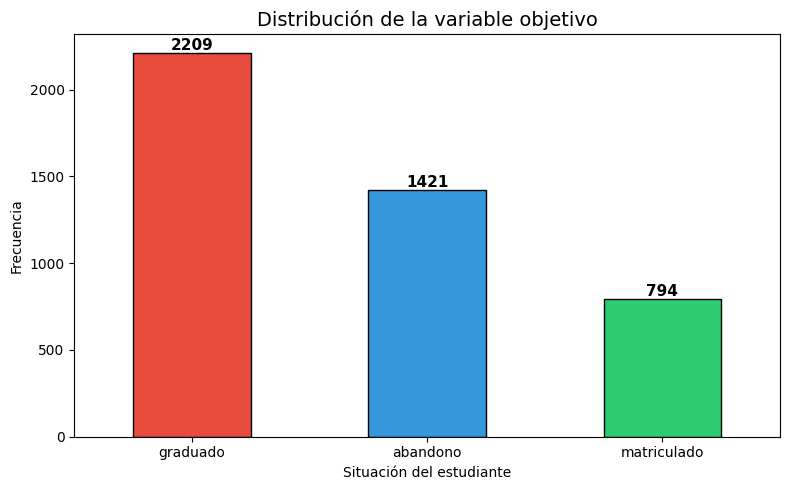

In [7]:
print('Distribución de la variable objetivo:')
print(df['objetivo'].value_counts())
print(f'\nProporciones:')
print(df['objetivo'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']
df['objetivo'].value_counts().plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Distribución de la variable objetivo', fontsize=14)
ax.set_xlabel('Situación del estudiante')
ax.set_ylabel('Frecuencia')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, (val, count) in enumerate(df['objetivo'].value_counts().items()):
    ax.text(i, count + 20, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

La variable objetivo recoge el **estado final** del estudiante observado a posteriori, no su situación durante el año capturado en los datos. Es decir: Graduado marca a quienes acabaron completando los estudios (aunque fuera años después), Abandono a quienes se fueron del todo y Matriculado a quienes en el momento del corte aún seguían cursando sin haber terminado.

La distribución de objetivo muestra un claro desbalanceo: casi la mitad de los estudiantes son graduados (49.9%), un tercio abandona (32.1%) y solo un 17.9% aparece aún como matriculado. Que las clases no estén equilibradas es importante porque afecta a cómo se evalúan los modelos. En concreto, la accuracy se vuelve poco informativa con clases desbalanceadas, ya que un modelo que siempre predijese "graduado" obtendría casi un 50% de acierto sin haber aprendido nada útil. Por eso más adelante se usará el F1-score ponderado como métrica principal y se analizará el comportamiento por clase con la matriz de confusión. El desbalanceo también justificará un análisis específico (sección 4.6) sobre si compensarlo mejora los resultados. Sin embargo el desbalanceo no es tan importante como para merezca la pena imputar datos.

### 2.4 Estadisticas descriptivas de variables numericas

In [8]:
df[cols_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
orden_solicitud,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
nota_cualificacion_previa,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
nota_admision,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
edad_al_matricularse,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
asignaturas_1sem_convalidadas,4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00
asignaturas_1sem_matriculadas,4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
asignaturas_1sem_evaluadas,4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
asignaturas_1sem_aprobadas,4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
nota_media_1sem,4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
asignaturas_1sem_sin_evaluacion,4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00


La tabla de estadísticos descriptivos permite hacerse una idea del dataset.

La variable edad_al_matricularse tiene media 23.3 y mediana 20: asimetría a la derecha, mayoría de estudiantes jóvenes con cola hasta 70 años (adultos que retoman estudios). nota_admision y nota_cualificacion_previa se mueven en rangos 95-190 con medias de 127-133 y distribuciones que parecen aproximadamente simétricas.

En asignaturas aprobadas y notas medias aparece un patrón importante: aunque la mediana es 5 aprobadas y nota 10-12, hay muchos estudiantes con 0 aprobadas y nota 0. No son errores, sino que son estudiantes que no se presentaron a examen, la pista más clara del abandono.

asignaturas_1sem_matriculadas y asignaturas_1sem_convalidadas presentan máximos muy elevados (26 y 20) frente a medias de 6.3 y 0.7: son perfiles atípicos pero reales. La explicación más razonable es que se trata de estudiantes a los que les han reconocido muchas asignaturas de estudios previos, y como vimos antes al comprobar las restricciones de coherencia, las convalidadas también se contabilizan dentro de las matriculadas del semestre; por eso que un alumno aparezca con 26 matriculadas y 20 convalidadas no es un error, sino un expediente con un volumen alto de reconocimientos. Lo mismo para el segundo semestre.

Las variables macroeconómicas (tasa_desempleo, tasa_inflacion, pib) se mueven en rangos estrechos y con pocos valores únicos: son indicadores agregados del entorno compartidos por toda una cohorte, con poder discriminativo limitado entre estudiantes aunque pueden captar diferencias entre años.

Sobre outliers: no los eliminamos. Los valores extremos tienen significado real (adultos, estudiantes que no se presentan) y los modelos de árboles son robustos por construcción.

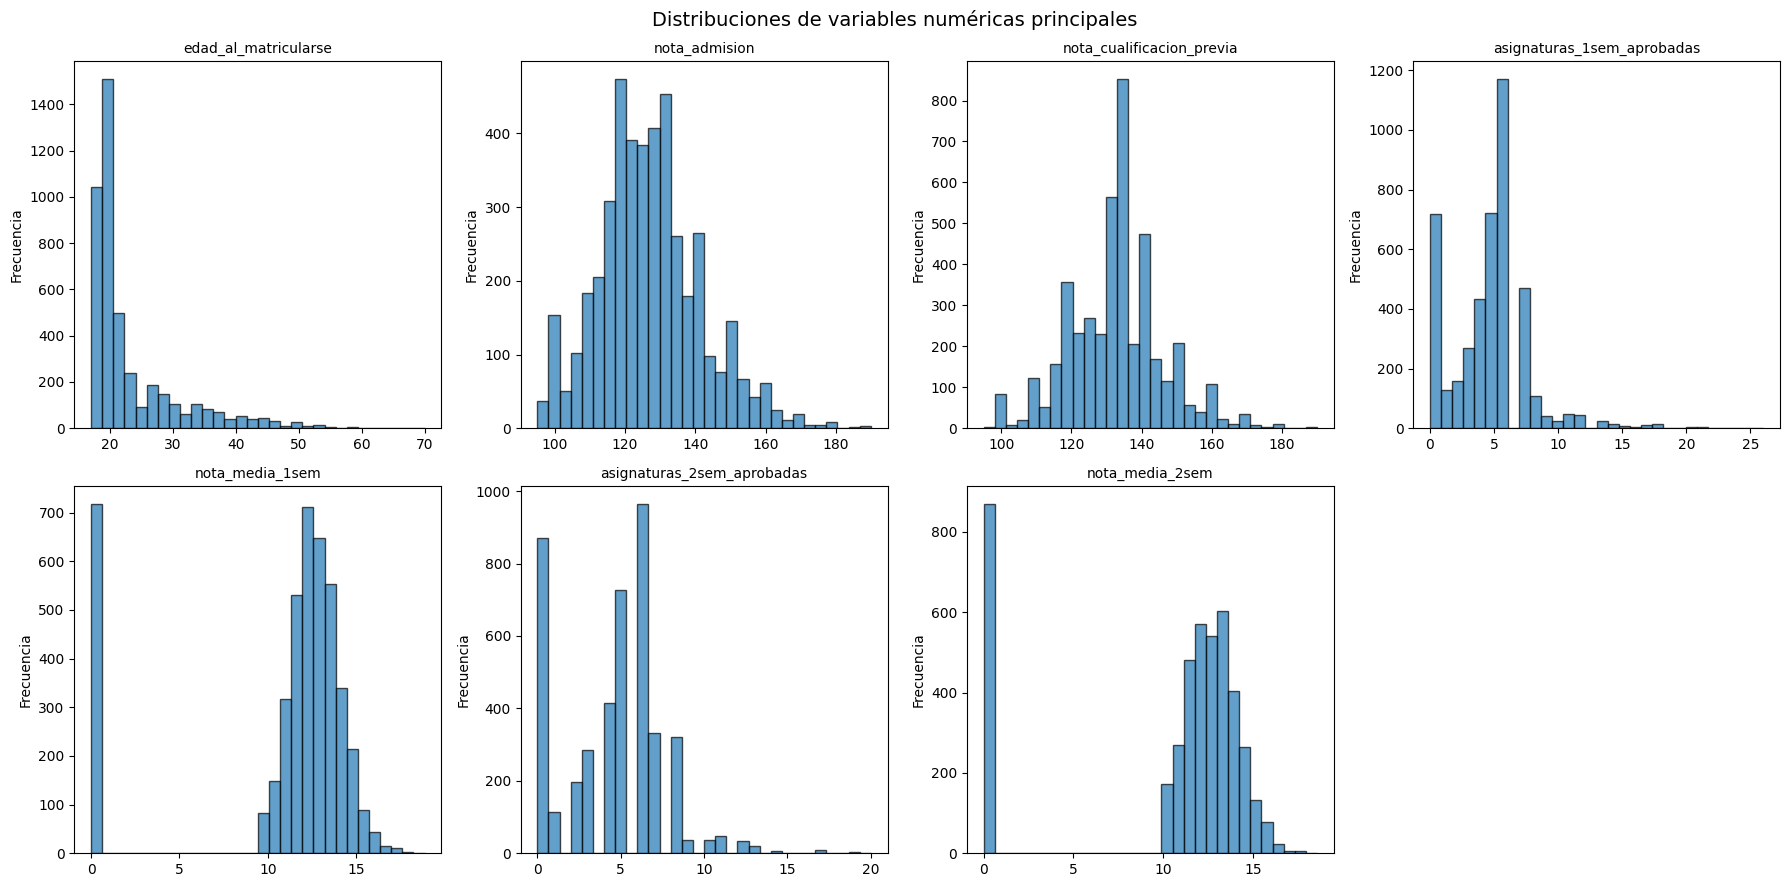

In [9]:
# Histogramas de las variables numéricas principales
vars_num_principales = [
    'edad_al_matricularse', 'nota_admision', 'nota_cualificacion_previa',
    'asignaturas_1sem_aprobadas', 'nota_media_1sem',
    'asignaturas_2sem_aprobadas', 'nota_media_2sem'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(vars_num_principales):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frecuencia')

for j in range(len(vars_num_principales), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas principales', fontsize=14)
plt.tight_layout()
plt.show()

Los histogramas confirman lo que sugerían los estadísticos y añaden detalles visuales interesantes.

La edad al matricularse está fuertemente concentrada entre los 17 y los 22 años, con una cola larga hacia la derecha. Es el patrón típico de una universidad, mayoría de alumnos jovenes y una minoría que accede más tarde. Las notas de admisión y de cualificación previa tienen distribuciones aproximadamente normales, centradas alrededor de 125-133 y bastante simétricas.

Pero las distribuciones que más revelan son las de rendimiento académico. Tanto las asignaturas aprobadas como las notas medias (1er y 2do semestre) presentan una clara bimodalidad: hay un pico enorme en el cero y después otro pico alrededor de los valores "normales" (5-6 aprobadas, notas entre 10 y 15), sin casi nadie en medio.

En el caso de las asignaturas aprobadas el patrón responde a que el dataset mezcla dos poblaciones muy distintas: estudiantes activos que van aprobando asignaturas con normalidad, y estudiantes que se matriculan pero apenas participan (suspenden o no se presentan). De ahí el pico en 0 frente al pico en 5-6.

En el caso de la nota media hay además una razón estructural que explica la ausencia total de valores entre 1 y 9. El sistema universitario portugués (origen del dataset) puntúa de 0 a 20, y la nota de aprobado es el 10. Y lo más importante, aparentemente la variable nota_media promedia solo las asignaturas aprobadas del semestre, no todas las evaluadas. Esto tiene dos consecuencias directas: si el estudiante no aprueba ninguna asignatura no hay nada sobre lo que promediar y el campo se rellena con 0, y si aprueba al menos una asignatura la media es por construcción ≥ 10 porque todos los valores promediados son aprobados. Por eso, literalmente no hay nadie con nota media entre 1 y 9 (salvo un caso aislado con 9.8 en el primer semestre, probablemente un redondeo o una situación especial desconocida). La bimodalidad aquí no refleja "dos poblaciones con notas muy distintas" sino la frontera del aprobado: o aprobaste algo, obteniendo nota media ≥ 10, o no aprobaste nada teniendo un 0 en este campo.

### 2.5 Distribución de variables categoricas

In [10]:
print('Número de categorias únicas por variable categórica:\n')
for col in cols_categoricas:
    print(f'  {col}: {df[col].nunique()} categorias')

Número de categorias únicas por variable categórica:

  estado_civil: 6 categorias
  modo_solicitud: 18 categorias
  curso: 17 categorias
  asistencia_diurna_vespertina: 2 categorias
  cualificacion_previa: 17 categorias
  nacionalidad: 21 categorias
  cualificacion_madre: 29 categorias
  cualificacion_padre: 34 categorias
  ocupacion_madre: 32 categorias
  ocupacion_padre: 46 categorias
  desplazado: 2 categorias
  necesidades_educativas_especiales: 2 categorias
  deudor: 2 categorias
  matricula_al_dia: 2 categorias
  genero: 2 categorias
  becado: 2 categorias
  internacional: 2 categorias
  objetivo: 3 categorias


El número de categorías únicas varía muchísimo entre variables. Las binarias (sí/no, hombre/mujer, diurna/vespertina) tienen 2 categorías cada una y se codifican trivialmente. Pero hay cinco variables con una cardinalidad muy alta que merecen atención especial, llegando a valores muy altos, por ejemplo ocupacion_padre llega a 46 categorías distintas, cualificacion_padre a 34, ocupacion_madre a 32, cualificacion_madre a 29 y nacionalidad a 21.

El problema con estas variables es doble. Primero, si se aplica one-hot encoding directamente, cada categoría genera una columna dummy, de modo que solo estas cinco variables producirían unas 157 columnas nuevas. Segundo, muchas de esas categorías tienen muy pocos casos (nacionalidades con dos o tres estudiantes u ocupaciones muy específicas con muy pocas observaciones). Esas columnas casi vacías no aportan información útil y ocupan espacio y generan ruido, pueden hacer que el modelo memorice casos individuales, ralentizan el entrenamiento y perjudican especialmente a los algoritmos basados en distancias como KNN, como hemos visto en el curso. En la sección 3.2 abordamos este problema agrupando las categorías raras en una categoría "otra".

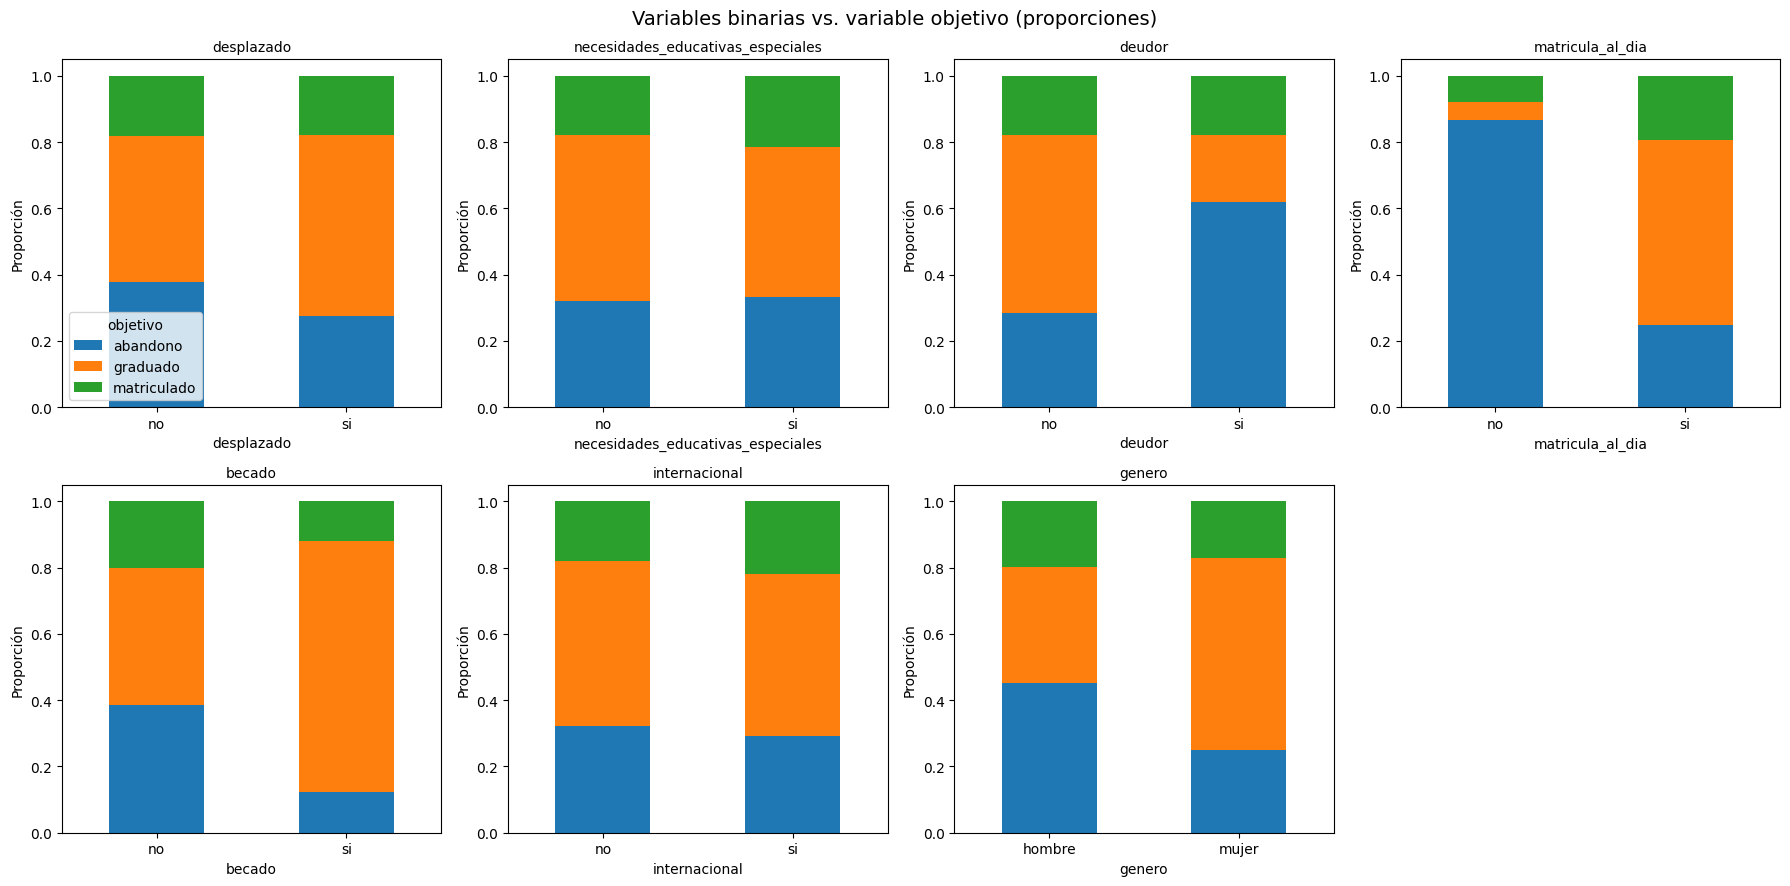

In [11]:
# Variables binarias respecto a la variable objetivo
vars_binarias = ['desplazado', 'necesidades_educativas_especiales', 'deudor',
                 'matricula_al_dia', 'becado', 'internacional', 'genero']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(vars_binarias):
    ct = pd.crosstab(df[col], df['objetivo'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], legend=(i == 0))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Proporción')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
for j in range(len(vars_binarias), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables binarias vs. variable objetivo (proporciones)', fontsize=14)
plt.tight_layout()
plt.show()

Los gráficos de barras apiladas muestran cómo se reparten las tres clases (abandono, matriculado, graduado) según el valor de cada variable binaria. Algunas diferencias son bastante llamativas.

La variable más discriminante con diferencia es matricula_al_dia. Los estudiantes con los pagos al día tienen una proporción de graduados mucho mayor y, simétricamente, una proporción de abandonos mucho menor que quienes no están al día. La diferencia es tan marcada que sugiere una relación muy fuerte entre la situación económica/administrativa y el éxito académico, aunque hay que recordar que correlación no implica causalidad, por ejemplo, pueden estar relacionadas porque comparten un factor común (dificultades económicas generales, por ejemplo).

becado y deudor se comportan de forma inversa, los becados tienden más a graduarse, los deudores tienden más a abandonar. La variable genero también muestra diferencias, ya que las mujeres tienen una proporción de graduación superior a la de los hombres, algo que la literatura educativa suele confirmar en muchos contextos.

Otras variables como necesidades_educativas_especiales o internacional muestran diferencias pequeñas, probablemente porque el número de casos positivos es bajo y las proporciones son menos fiables estadísticamente.

### 2.6 Correlaciones entre variables numericas

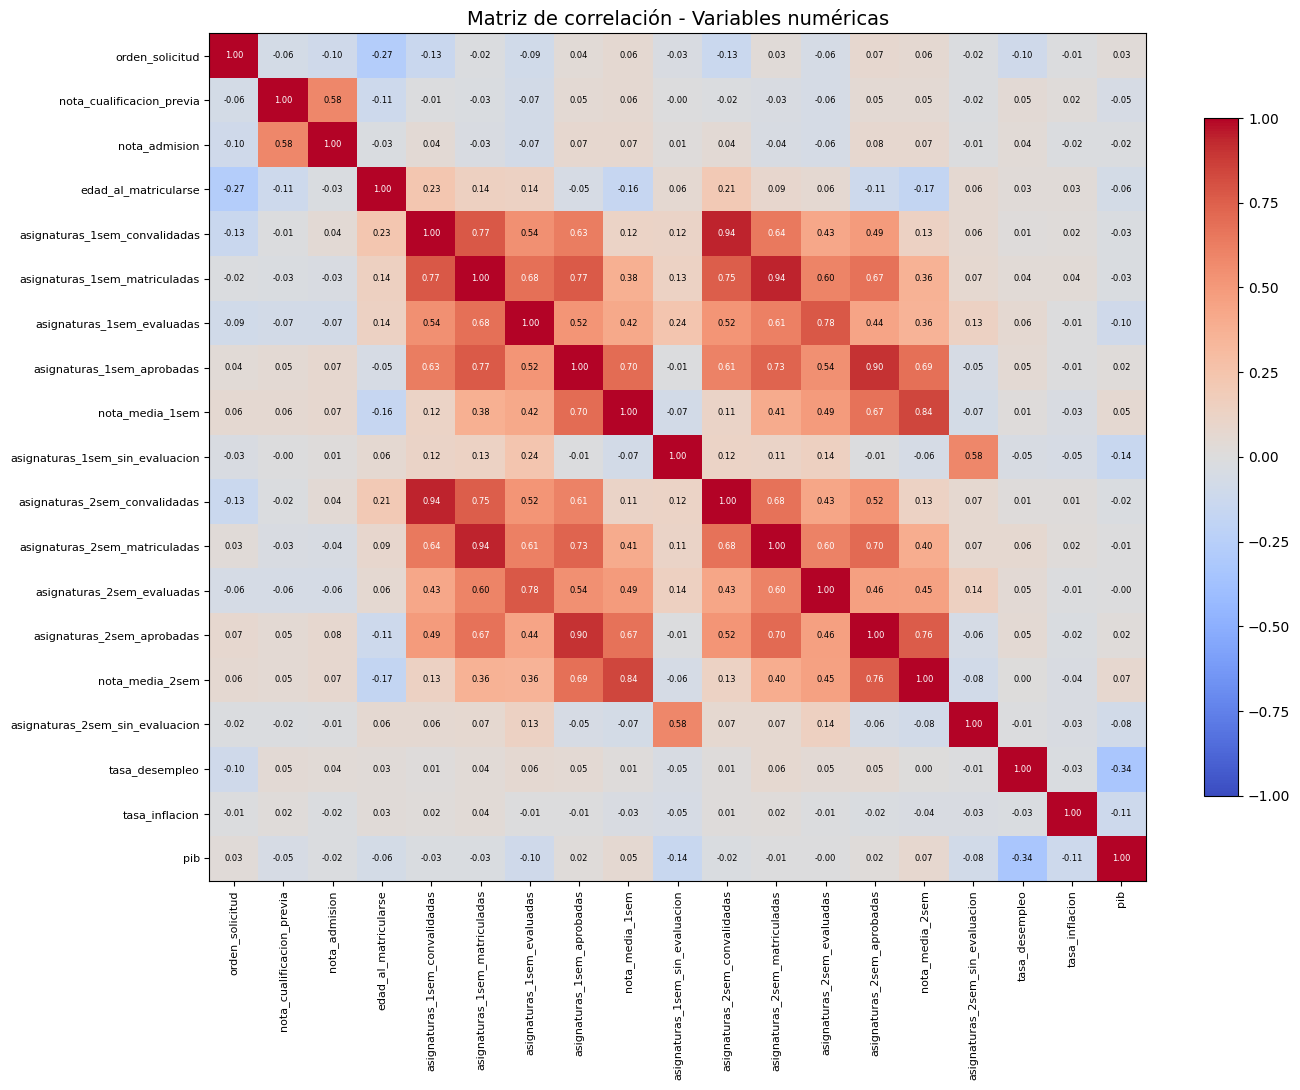

In [12]:
# Segun el temario (02-01), la correlacion entre predictores puede causar colinealidad
corr_matrix = df[cols_numericas].corr()

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(cols_numericas)))
ax.set_yticks(range(len(cols_numericas)))
ax.set_xticklabels(cols_numericas, rotation=90, fontsize=8)
ax.set_yticklabels(cols_numericas, fontsize=8)

# Anotaciones: valor numerico en cada celda
for r in range(len(cols_numericas)):
    for c in range(len(cols_numericas)):
        val = corr_matrix.iloc[r, c]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de correlación - Variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Pares con alta correlacion (>0.7) - relevante para colinealidad (tema 02-01, 02-04)
threshold = 0.7
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i], corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print(f'Pares de variables con correlación > {threshold}:\n')
for v1, v2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {v1}  <->  {v2}  :  {corr}')

Pares de variables con correlación > 0.7:

  asignaturas_1sem_convalidadas  <->  asignaturas_2sem_convalidadas  :  0.945
  asignaturas_1sem_matriculadas  <->  asignaturas_2sem_matriculadas  :  0.943
  asignaturas_1sem_aprobadas  <->  asignaturas_2sem_aprobadas  :  0.904
  nota_media_1sem  <->  nota_media_2sem  :  0.837
  asignaturas_1sem_evaluadas  <->  asignaturas_2sem_evaluadas  :  0.779
  asignaturas_1sem_convalidadas  <->  asignaturas_1sem_matriculadas  :  0.774
  asignaturas_1sem_matriculadas  <->  asignaturas_1sem_aprobadas  :  0.769
  asignaturas_2sem_aprobadas  <->  nota_media_2sem  :  0.761
  asignaturas_1sem_matriculadas  <->  asignaturas_2sem_convalidadas  :  0.754
  asignaturas_1sem_aprobadas  <->  asignaturas_2sem_matriculadas  :  0.734
  asignaturas_2sem_matriculadas  <->  asignaturas_2sem_aprobadas  :  0.703


El heatmap de correlaciones revela patrones muy esperables. Las correlaciones más altas del dataset aparecen entre variables del mismo tipo en el primer y segundo semestre: las asignaturas convalidadas en 1sem y 2sem correlan 0.945, las matriculadas 0.943, las aprobadas 0.904 y las notas medias 0.837. Esto es perfectamente lógico: un estudiante que rinde bien en un semestre tiende a hacerlo en el siguiente, y las cantidades absolutas (cuántas se matricula, cuántas aprueba) suelen ser estables entre semestres.

Dentro de un mismo semestre también aparecen altas correlaciones, asignaturas_1sem_convalidadas correla 0.774 con asignaturas_1sem_matriculadas (parte de esta correlación se explica porque como vimos en el chequeo de coherencia las convalidadas están contenidas dentro de las matriculadas), y asignaturas_1sem_matriculadas tiene una correlación de 0.769 con asignaturas_1sem_aprobadas. Son correlaciones fuertes pero no tan extremas como las inter-semestre.

Estas correlaciones altas implican colinealidad, un fenómeno que puede afectar a los modelos lineales: cuando dos variables contienen casi la misma información, los coeficientes que el modelo les asigna se vuelven inestables y poco interpretables. En la sección 3.4 discutimos en detalle cómo abordar este problema (la respuesta corta es: Lasso y los árboles ya lo gestionan, así que no hace falta eliminar variables manualmente).

### 2.7 Relación entre variables clave y la variable objetivo

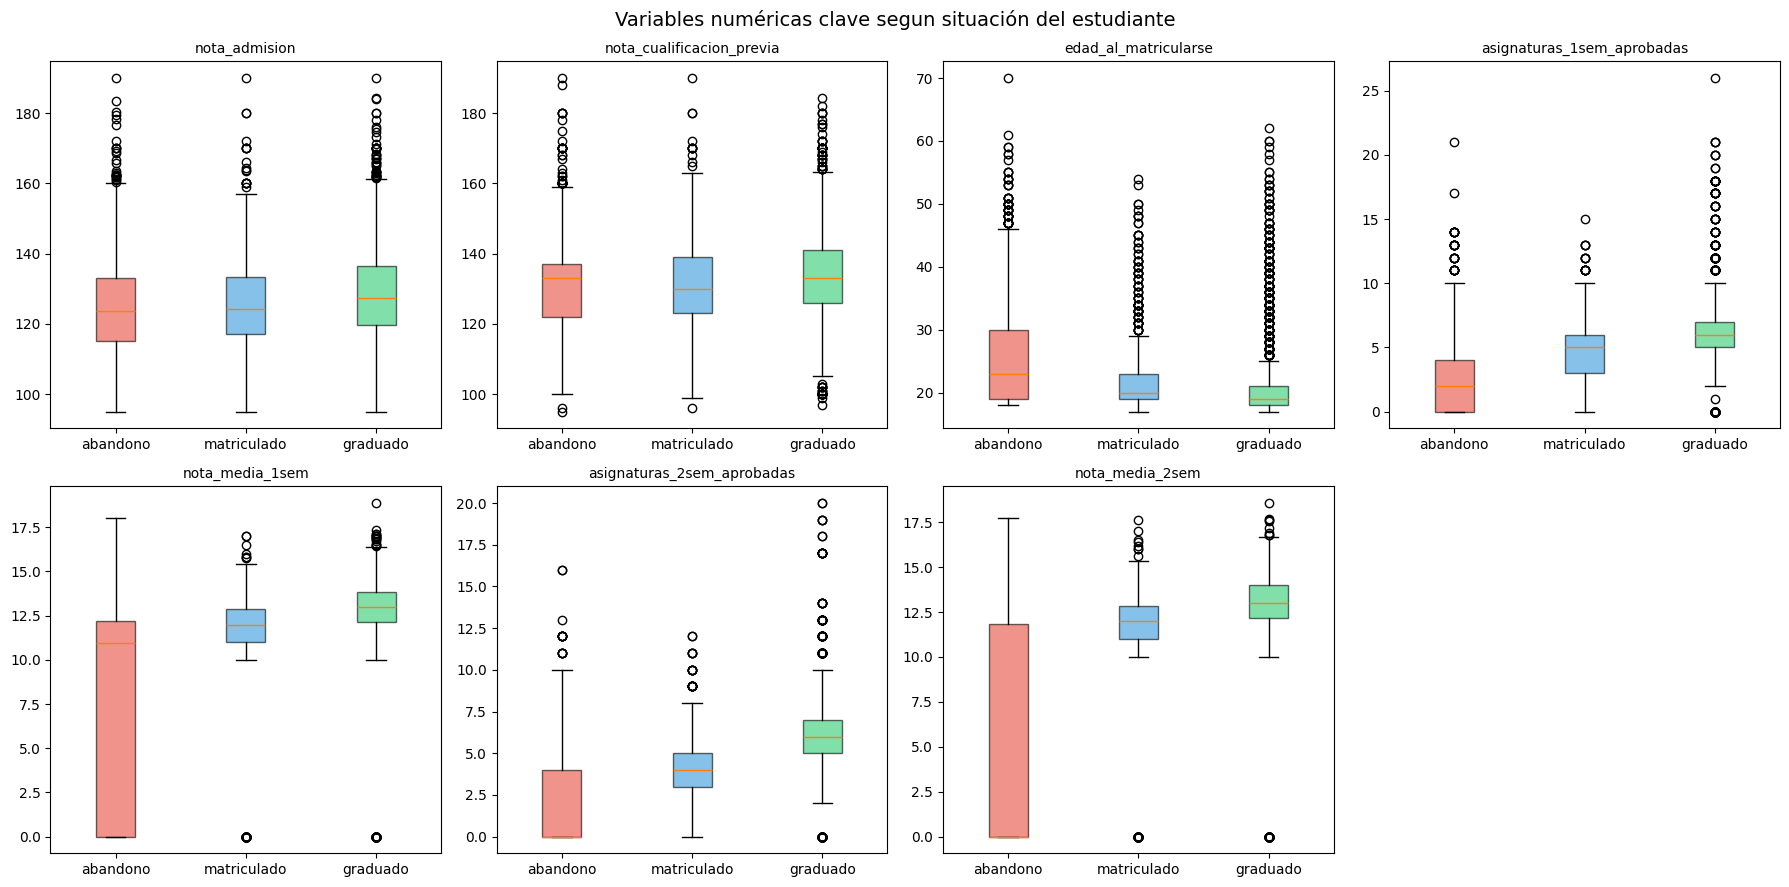

In [14]:
vars_clave = ['nota_admision', 'nota_cualificacion_previa', 'edad_al_matricularse',
              'asignaturas_1sem_aprobadas', 'nota_media_1sem',
              'asignaturas_2sem_aprobadas', 'nota_media_2sem']

grupos = ['abandono', 'matriculado', 'graduado']
colores = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(vars_clave):
    data = [df[df['objetivo'] == g][col].dropna().values for g in grupos]
    bp = axes[i].boxplot(data, labels=grupos, patch_artist=True)
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(col, fontsize=10)

for j in range(len(vars_clave), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas clave segun situación del estudiante', fontsize=14)
plt.tight_layout()
plt.show()

Los boxplots agrupados por la variable objetivo permiten ver de un vistazo qué variables separan mejor a los tres grupos.

Las que más destacan son, como cabía esperar, las de rendimiento académico. En asignaturas_1sem_aprobadas, asignaturas_2sem_aprobadas, nota_media_1sem y nota_media_2sem las cajas de los tres grupos están claramente separadas: los graduados concentran sus datos en valores altos, los abandonos en valores muy bajos (muchos en el cero), y los matriculados quedan en medio con bastante dispersión. Esta separación visual es una señal muy clara de que estas variables tendran un papel protagonista en los modelos predictivos.

En las variables de acceso (nota_admision y nota_cualificacion_previa) también hay diferencias entre grupos, pero son mucho más sutiles, ya que las cajas se solapan bastante y solo se aprecia que los graduados tienen una mediana ligeramente más alta. Esto anticipa que el rendimiento previo puede predecir el éxito futuro, pero mucho menos que el rendimiento durante los propios estudios.

La variable edad_al_matricularse muestra un patrón llamativo, los graduados tienen una distribución estrecha y centrada en torno a los 20-22 años, mientras que los abandonos presentan una distribución mucho más dispersa que se extiende hacia edades más altas, lo que sugiere que el perfil de estudiante adulto que retoma los estudios tiene más riesgo de abandono que el tradicional, aunque de nuevo correlación no implica causalidad.

In [15]:
print('Medias de variables numéricas por grupo:\n')
df.groupby('objetivo')[vars_clave].mean().round(2).T

Medias de variables numéricas por grupo:



objetivo,abandono,graduado,matriculado
nota_admision,124.96,128.79,125.53
nota_cualificacion_previa,131.11,134.08,131.21
edad_al_matricularse,26.07,21.78,22.37
asignaturas_1sem_aprobadas,2.55,6.23,4.32
nota_media_1sem,7.26,12.64,11.13
asignaturas_2sem_aprobadas,1.94,6.18,4.06
nota_media_2sem,5.90,12.70,11.12


La tabla de medias muestra cómo cambia el valor medio de cada variable numérica según el estado final del estudiante.

Las diferencias más fuertes aparecen en las variables de rendimiento del primer y segundo semestre. Graduados aprueban de media 6.2 y 6.2 asignaturas por semestre, matriculados 4.3 y 4.1, y abandonos solo 2.5 y 1.9. En nota media los graduados están en torno a 12.6-12.7, los matriculados en torno a 11.1 y los abandonos en 7.3-5.9. Estos números confirman lo que se intuía, lo que más separa los tres grupos es el rendimiento real, no las variables antes de entrar a la universidad.

Entre las variables de entrada y contexto las diferencias son más sutiles. La nota_admision es algo más alta en graduados (128.8) que en matriculados (125.5) y abandonos (125.0), una diferencia de unos 3-4 puntos que existe pero no es enorme. La edad_al_matricularse sí discrimina con claridad, los abandonos tienen media 26 años, frente a 22 en graduados.

### 2.8 Perfiles de estudiantes

Una de las preguntas que plantea el enunciado es si existen perfiles de estudiantes con características claramente diferenciadas. Para responder, en esta sección construimos una descripción comparativa de los tres grupos usando las variables más discriminantes que ha ido destacando el EDA (edad, rendimiento académico, situación económica). La idea es ir más allá de la media aislada y presentar cada grupo como un perfil coherente, que tenga varias dimensiones a la vez, de modo que se vea que tipo de estudiante representa cada clase.

In [16]:
# Perfiles de estudiantes basados en las variables mas discriminantes
print('=== PERFILES DE ESTUDIANTES ===')
print()

for grupo in ['abandono', 'matriculado', 'graduado']:
    sub = df[df['objetivo'] == grupo]
    print(f'--- Perfil: {grupo.upper()} ({len(sub)} estudiantes, {len(sub)/len(df)*100:.1f}%) ---')
    print(f'  Edad media al matricularse: {sub["edad_al_matricularse"].mean():.1f} años')
    print(f'  Nota media de admision:     {sub["nota_admision"].mean():.1f}')
    print(f'  Asignaturas aprobadas 1sem: {sub["asignaturas_1sem_aprobadas"].mean():.1f}')
    print(f'  Nota media 1sem:            {sub["nota_media_1sem"].mean():.1f}')
    print(f'  Matrícula al día:           {(sub["matricula_al_dia"]=="si").mean()*100:.1f}%')
    print(f'  Becado:                     {(sub["becado"]=="si").mean()*100:.1f}%')
    print(f'  Deudor:                     {(sub["deudor"]=="si").mean()*100:.1f}%')
    print(f'  Género (% mujeres):         {(sub["genero"]=="mujer").mean()*100:.1f}%')
    print()


=== PERFILES DE ESTUDIANTES ===

--- Perfil: ABANDONO (1421 estudiantes, 32.1%) ---
  Edad media al matricularse: 26.1 años
  Nota media de admision:     125.0
  Asignaturas aprobadas 1sem: 2.6
  Nota media 1sem:            7.3
  Matrícula al día:           67.8%
  Becado:                     9.4%
  Deudor:                     22.0%
  Género (% mujeres):         50.7%

--- Perfil: MATRICULADO (794 estudiantes, 17.9%) ---
  Edad media al matricularse: 22.4 años
  Nota media de admision:     125.5
  Asignaturas aprobadas 1sem: 4.3
  Nota media 1sem:            11.1
  Matrícula al día:           94.7%
  Becado:                     16.4%
  Deudor:                     11.3%
  Género (% mujeres):         61.3%

--- Perfil: GRADUADO (2209 estudiantes, 49.9%) ---
  Edad media al matricularse: 21.8 años
  Nota media de admision:     128.8
  Asignaturas aprobadas 1sem: 6.2
  Nota media 1sem:            12.6
  Matrícula al día:           98.7%
  Becado:                     37.8%
  Deudor:        

A partir de las medias y proporciones anteriores se pueden describir tres perfiles bastante distintos.

El **graduado típico** es joven (22 años de media), entra con nota de admisión algo por encima del resto (128.8), aprueba casi todo lo que se matricula en ambos semestres (media 6.2 y 6.2), saca notas en torno a 12.6, rara vez es deudor (4.6%) y en un 38% de los casos es becado. No hay un rasgo único que lo defina, pero la combinación de juventud + buen rendimiento sostenido + estabilidad económica es muy clara.

El **abandono típico** es mayor (26 años), su nota de admisión es algo más baja (125.0), pero la diferencia clave aparece en el rendimiento, ya que aprueba solo 2.6 asignaturas el primer semestre y 1.9 el segundo (frente a las 5-6 que se suele matricular), con notas medias de 7.3 y 5.9. Un 22% son deudores (casi 5 veces más que los graduados, que solo llegan al 4.6%) y solo un 9.4% son becados. El patrón sugiere dificultades económicas.

El **matriculado en curso** es un punto intermedio, edad 22, aprueba unas 4 asignaturas por semestre, notas en torno a 11.1, un 11% es deudor y un 16% becado. Es el grupo más difícil de clasificar porque solapa con los otros dos, tiene sentido pues aún no se sabe si se va a graduar o no.

### 2.8b Análisis de patrones de comportamiento (más perfiles de estudiantes)

Los perfiles de la sección anterior muestran diferencias medias entre los tres grupos, pero se quedan en un nivel descriptivo. Para mejorar el análisis conviene ir un paso más allá y mirar cómo nteractúan ciertas variables, buscando más perfiles de estudiantes a parte de los objetivos, algunas preguntas que se van a responder son: ¿el efecto de la edad cambia según la situación económica? ¿Existen estudiantes con buenas notas de acceso que fracasan una vez en la universidad? ¿La beca protege del abandono o simplemente se concede a los que ya tienen buen rendimiento?

Este tipo de preguntas son las que permiten descubrir patrones de comportamiento no triviales, es decir, relaciones que no se ven mirando cada variable por separado. En las siguientes celdas exploramos cuatro interacciones que resultaron especialmente reveladoras.

**Patrón 1: Ratio de aprobadas sobre matriculadas en el primer semestre**

No es lo mismo aprobar 5 asignaturas de 5 que aprobar 5 de 10. La primera persona está sacando todo adelante; la segunda, solo la mitad. Sin embargo, si miramos únicamente el número absoluto de aprobadas (como hace el perfil de la sección anterior), estas dos situaciones quedan indistinguibles.

Para capturar esta diferencia calculamos el ratio aprobadas / matriculadas. Un ratio cercano a 1 indica un estudiante eficiente que aprueba prácticamente todo lo que intenta, mientras que un ratio cercano a 0 indica que el estudiante se matricula de asignaturas pero apenas las saca. Esta métrica normaliza por la ambición del estudiante y permite compararlo con otros sin el sesgo del volumen total.

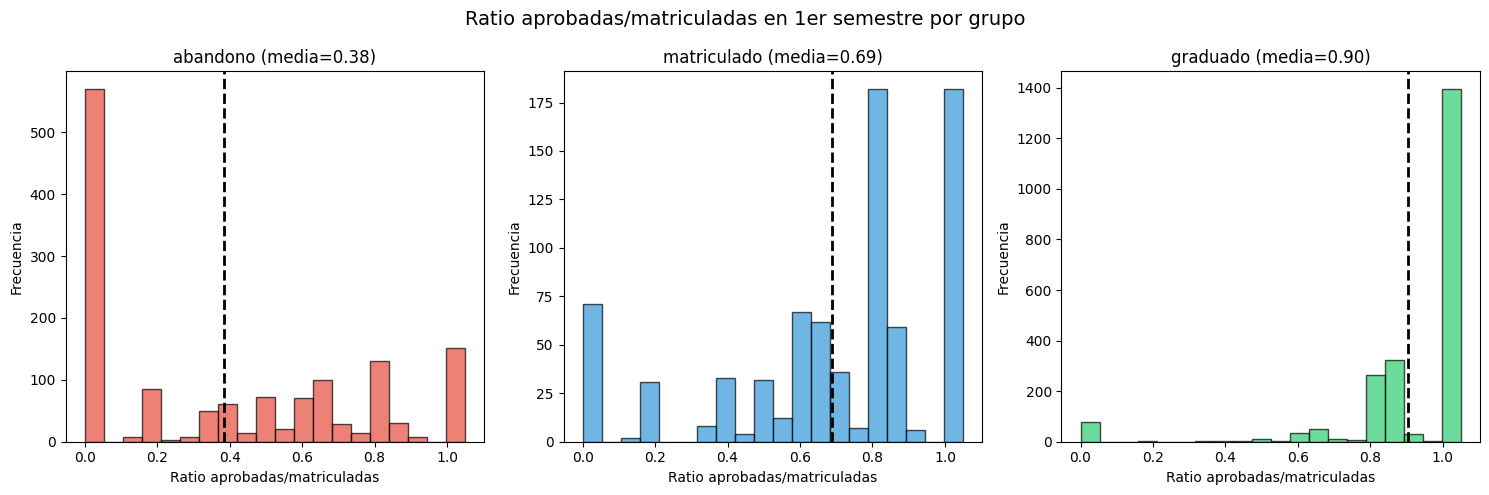

Ratio aprobadas/matriculadas (1er semestre) por grupo:

              mean    50%    std
objetivo                        
abandono     0.384  0.333  0.373
graduado     0.903  1.000  0.200
matriculado  0.688  0.800  0.299


In [17]:
# Patrón 1: Ratio aprobadas/matriculadas en 1er semestre
# Evitamos división por cero cuando matriculadas = 0
df['ratio_aprobadas_1sem'] = np.where(
    df['asignaturas_1sem_matriculadas'] > 0,
    df['asignaturas_1sem_aprobadas'] / df['asignaturas_1sem_matriculadas'],
    0
)

# Distribución del ratio por grupo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
grupos = ['abandono', 'matriculado', 'graduado']
colores = ['#e74c3c', '#3498db', '#2ecc71']

for ax, grupo, color in zip(axes, grupos, colores):
    data = df[df['objetivo'] == grupo]['ratio_aprobadas_1sem']
    ax.hist(data, bins=20, range=(0, 1.05), color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'{grupo} (media={data.mean():.2f})', fontsize=12)
    ax.set_xlabel('Ratio aprobadas/matriculadas')
    ax.set_ylabel('Frecuencia')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=2)

plt.suptitle('Ratio aprobadas/matriculadas en 1er semestre por grupo', fontsize=14)
plt.tight_layout()
plt.show()

# Tabla resumen
print('Ratio aprobadas/matriculadas (1er semestre) por grupo:\n')
print(df.groupby('objetivo')['ratio_aprobadas_1sem'].describe()[['mean', '50%', 'std']].round(3))

Los histogramas muestran cómo se distribuye este ratio dentro de cada grupo. Al tratarse de un indicador de eficiencia, las diferencias entre graduados y abandonos deberían ser muy visibles. La interpretación completa se hace más adelante, cuando veamos los cuatro patrones juntos.

**Patrón 2: Interacción entre edad y situación de pago**

Los análisis anteriores nos dicen que los estudiantes mayores abandonan más y que los que no tienen los pagos al día también. Pero queda una pregunta interesante sin responder: ¿estos dos factores actúan de forma independiente (sus efectos se suman) o se refuerzan mutuamente (la combinación es peor que la suma de sus partes)?

Para averiguarlo cruzamos las dos variables y calculamos la tasa de abandono en cada combinación, si el efecto que se obtiene es aditivo, veremos diferencias moderadas y parecidas en cada corte. Si hay interacción, veremos que una de las combinaciones tiene una tasa de abandono mucho mayor de lo que predicen los dos factores por separado.

Tasa de abandono por edad y situación de pago:

              No al día  Al día
grupo_edad                     
joven (<=22)      0.769   0.183
mayor (>22)       0.940   0.415



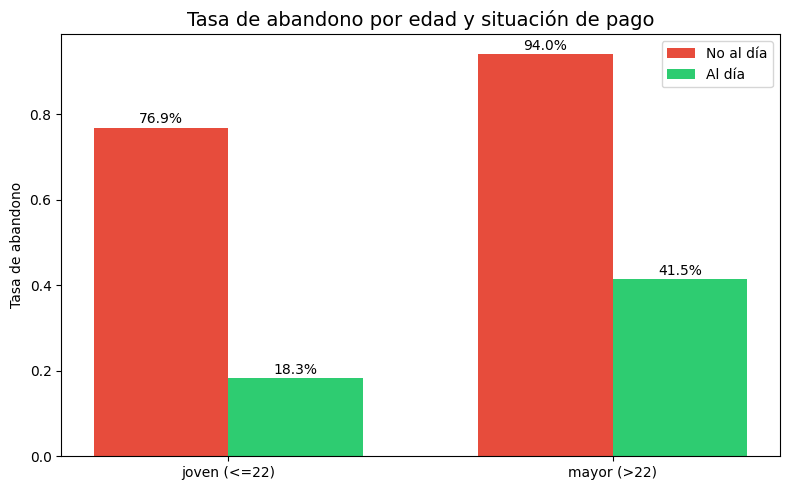

In [18]:
# Patrón 2: Tasa de abandono por edad (joven/mayor) y matrícula al día
df['grupo_edad'] = np.where(df['edad_al_matricularse'] <= 22, 'joven (<=22)', 'mayor (>22)')

# Tabla cruzada: tasa de abandono por edad x matricula_al_dia
tabla = df.groupby(['grupo_edad', 'matricula_al_dia'])['objetivo'].apply(
    lambda x: (x == 'abandono').mean()
).unstack()
tabla.columns = ['No al día', 'Al día']

print('Tasa de abandono por edad y situación de pago:\n')
print(tabla.round(3))
print()

# Grafico
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(tabla.index))
width = 0.35
ax.bar([xi - width/2 for xi in x], tabla.iloc[:, 0], width, label='No al día', color='#e74c3c')
ax.bar([xi + width/2 for xi in x], tabla.iloc[:, 1], width, label='Al día', color='#2ecc71')
ax.set_xticks(list(x))
ax.set_xticklabels(tabla.index)
ax.set_ylabel('Tasa de abandono')
ax.set_title('Tasa de abandono por edad y situación de pago', fontsize=14)
ax.legend()

for i_bar, (idx, row) in enumerate(tabla.iterrows()):
    ax.text(i_bar - width/2, row.iloc[0] + 0.01, f'{row.iloc[0]:.1%}', ha='center', fontsize=10)
    ax.text(i_bar + width/2, row.iloc[1] + 0.01, f'{row.iloc[1]:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Patrón 3: Buenas notas de acceso pero mal rendimiento en la universidad**

¿Una buena nota de acceso garantiza el éxito universitario? Intuitivamente se esperaría que sí, el que llega con buen expediente debería, en promedio, seguir rindiendo bien. Pero el EDA ya sugería que el rendimiento durante los estudios importa mucho más que el previo.

Para verlo con claridad partimos el dataset en cuatro grupos según la mediana de la nota de admisión y la mediana de la nota del primer semestre. Nos interesa especialmente el grupo "buena entrada + mal rendimiento", son estudiantes que llegan con expediente por encima de la mediana pero fracasan en el primer semestre. Si este grupo existe y abandona mucho, tendremos una evidencia clara de que la nota de acceso es un predictor débil comparado con el rendimiento real.

In [19]:
# Patron 3: Buena nota de acceso + mal rendimiento
mediana_admision = df['nota_admision'].median()
mediana_1sem = df['nota_media_1sem'].median()

df['perfil_acceso_rendimiento'] = 'otro'
mask_buena_buena = (df['nota_admision'] >= mediana_admision) & (df['nota_media_1sem'] >= mediana_1sem)
mask_buena_mala = (df['nota_admision'] >= mediana_admision) & (df['nota_media_1sem'] < mediana_1sem)
mask_mala_buena = (df['nota_admision'] < mediana_admision) & (df['nota_media_1sem'] >= mediana_1sem)
mask_mala_mala = (df['nota_admision'] < mediana_admision) & (df['nota_media_1sem'] < mediana_1sem)

df.loc[mask_buena_buena, 'perfil_acceso_rendimiento'] = 'buena entrada + buen rendimiento'
df.loc[mask_buena_mala, 'perfil_acceso_rendimiento'] = 'buena entrada + mal rendimiento'
df.loc[mask_mala_buena, 'perfil_acceso_rendimiento'] = 'mala entrada + buen rendimiento'
df.loc[mask_mala_mala, 'perfil_acceso_rendimiento'] = 'mala entrada + mal rendimiento'

# Distribucion de objetivo por perfil
tabla_perfil = pd.crosstab(df['perfil_acceso_rendimiento'], df['objetivo'], normalize='index').round(3)
tabla_perfil = tabla_perfil[['abandono', 'matriculado', 'graduado']]

print(f'Medianas usadas: nota_admision = {mediana_admision}, nota_media_1sem = {mediana_1sem}\n')
print('Proporción de cada situación por perfil de acceso/rendimiento:\n')
print(tabla_perfil)
print(f'\nNumero de estudiantes por perfil:')
print(df['perfil_acceso_rendimiento'].value_counts())

Medianas usadas: nota_admision = 126.1, nota_media_1sem = 12.285714285714286

Proporción de cada situación por perfil de acceso/rendimiento:

objetivo                          abandono  matriculado  graduado
perfil_acceso_rendimiento                                        
buena entrada + buen rendimiento     0.146        0.123     0.731
buena entrada + mal rendimiento      0.497        0.202     0.300
mala entrada + buen rendimiento      0.155        0.176     0.669
mala entrada + mal rendimiento       0.494        0.223     0.283

Numero de estudiantes por perfil:
perfil_acceso_rendimiento
buena entrada + buen rendimiento    1310
mala entrada + mal rendimiento      1287
mala entrada + buen rendimiento      918
buena entrada + mal rendimiento      909
Name: count, dtype: int64


**Patrón 4: Efecto de ser becado, controlando por rendimiento**

El EDA muestra que los becados abandonan menos. Pero aquí puede haber un sesgo de selección, donde quizás las becas se conceden precisamente a los mejores estudiantes, y el menor abandono no se debe a la beca en sí sino al nivel académico de quien la recibe. Para separar ambos efectos hay que comparar becados y no becados a igualdad de rendimiento.

Para conseguirlo dividimos a los estudiantes en tres partes según la nota media del primer semestre (bajo, medio, alto) y dentro de cada parte comparamos la tasa de abandono entre becados y no becados. Si la beca actúa como factor protector, los becados deberían abandonar menos en todos los niveles de rendimiento, no solo en el alto. Si el efecto se debe al nivel académico, la diferencia se disipará al controlar por cada parte.

Tasa de abandono por tercil de rendimiento (1sem) y beca:

             No becado  Becado
tercil_1sem                   
bajo             0.651   0.277
medio            0.286   0.109
alto             0.151   0.061



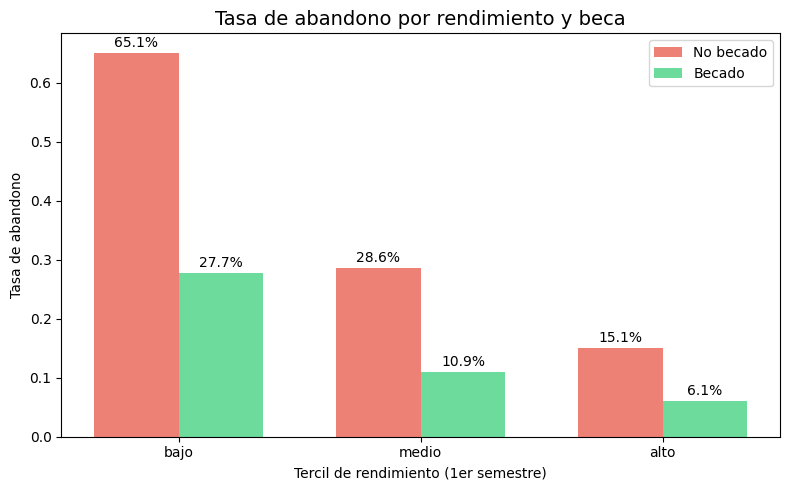

In [20]:
# Patron 4: Tasa de abandono por becado y nivel de rendimiento
# Dividimos en terciles de nota_media_1sem
df['tercil_1sem'] = pd.qcut(
    df['nota_media_1sem'], q=3, labels=['bajo', 'medio', 'alto'], duplicates='drop'
)

tabla_beca = df.groupby(['tercil_1sem', 'becado'])['objetivo'].apply(
    lambda x: (x == 'abandono').mean()
).unstack()
tabla_beca.columns = ['No becado', 'Becado']

print('Tasa de abandono por tercil de rendimiento (1sem) y beca:\n')
print(tabla_beca.round(3))
print()

# Grafico
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(tabla_beca.index))
width = 0.35
ax.bar([xi - width/2 for xi in x], tabla_beca['No becado'], width,
       label='No becado', color='#e74c3c', alpha=0.7)
ax.bar([xi + width/2 for xi in x], tabla_beca['Becado'], width,
       label='Becado', color='#2ecc71', alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels(tabla_beca.index)
ax.set_xlabel('Tercil de rendimiento (1er semestre)')
ax.set_ylabel('Tasa de abandono')
ax.set_title('Tasa de abandono por rendimiento y beca', fontsize=14)
ax.legend()

for i_bar, (idx, row) in enumerate(tabla_beca.iterrows()):
    ax.text(i_bar - width/2, row['No becado'] + 0.01, f'{row["No becado"]:.1%}', ha='center', fontsize=10)
    ax.text(i_bar + width/2, row['Becado'] + 0.01, f'{row["Becado"]:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Observaciones de los patrones de comportamiento.**

Los cuatro análisis proporcionan resultados contundentes.

En el ratio aprobadas/matriculadas las diferencias son drásticas: graduados 0.90 (mediana 1.0, aprueban todo lo que intentan), abandonos 0.38 (mediana 0.33), matriculados 0.69 en medio. Este ratio es mejor que el recuento absoluto porque normaliza por la ambición del estudiante.

La interacción edad × pagos al día es muy reveladora: joven con pagos al día 18.3% de abandono, mayor con pagos 41.5%, joven sin pagos 76.9%, mayor sin pagos 94%. Edad alta + impagos es prácticamente una sentencia de abandono, muy por encima de la suma de ambos factores.

El perfil buena entrada + mal rendimiento abandona un 49.7%, frente al 14.6% de los que mantienen buen rendimiento. Los de mala entrada pero buen rendimiento abandonan solo un 15.5%. Lo que pasa en la universidad pesa más que con qué nota se entró.

El efecto de la beca se sostiene controlando por rendimiento: tercil bajo, becados 27.7% vs no becados 65.1%; medio 10.9% vs 28.6%; alto 6.1% vs 15.1%. La beca reduce el abandono aproximadamente a la mitad en cada nivel, efecto protector real más allá del nivel académico.

Perfiles característicos identificados.

Cruzando los cuatro análisis salen unos cuantos grupos con comportamientos muy distintos entre sí:

- Perfil de éxito consolidado: joven, becado, al día con los pagos y con un buen ratio de aprobadas en el primer semestre. Aquí el abandono es por debajo del 10% y casi todos acaban graduándose. La beca y el rendimiento se refuerzan entre sí.

- Perfil de remontada: entra con nota baja pero en el primer semestre aprueba casi todo lo que se matricula. Abandona solo un 15.5%, prácticamente lo mismo que los de buena entrada y buen rendimiento. Es la prueba de que lo que ocurre dentro de la universidad pesa más que la nota con la que se entra.

- Perfil de caída temprana: buena nota de entrada pero mal rendimiento nada más llegar. Casi la mitad (49.7%) abandona a pesar de haber empezado con buenas cartas. Este es probablemente el grupo más interesante para una intervención precoz, porque mirando solo el expediente previo no se vería venir.

- Perfil de riesgo estructural: estudiante mayor y sin los pagos al día. Abandona el 94%, es casi inevitable. Aquí se juntan fragilidad económica y una situación vital complicada, y cuando el problema se detecta ya suele ser tarde.

- Perfil de riesgo económico puro: joven pero sin los pagos al día. Abandona el 76.9% aunque la edad debería jugar a su favor. Señala que el problema económico tiene peso propio y no se compensa por ser joven.

- Perfil intermedio protegido por la beca: rendimiento medio o incluso bajo, pero becado. Abandona aproximadamente la mitad que un no becado con el mismo nivel académico, lo que confirma que la ayuda económica protege de verdad y no es solo un marcador indirecto de que el alumno ya venía bien.

La conclusión conjunta es bastante clara, el abandono se explica sobre todo por la interacción entre el rendimiento del primer semestre, la situación económica (pagos al día y beca) y la edad. El rendimiento y los pagos son los factores que más empujan, y la nota de entrada pesa menos de lo que uno esperaría.

### 2.9 Síntesis del EDA por bloques temáticos del enunciado

El enunciado describe el dataset organizándolo en seis bloques de variables. Las secciones anteriores han ido tocando todas estas variables al hilo del análisis (numéricas, categóricas, correlaciones, perfiles), y conviene cerrar el EDA con una mirada por bloques que permita ver lo que cada familia aporta al problema.

**Bloque 1 - Demográficas y personales (edad, género, nacionalidad, desplazado, internacional, NEE).** La variable más informativa del bloque es edad_al_matricularse: hay una diferencia de unos 4 años entre la edad media de los graduados (22) y la de los abandonos (26), y la interacción con matrícula al día (patrón 2 de la sección 2.8b) refuerza este efecto. Género muestra una diferencia moderada a favor de las mujeres en tasa de graduación. Nacionalidad y NEE tienen baja cardinalidad útil porque casi todos los estudiantes están en una sola categoría dominante.

**Bloque 2 - Acceso y contexto académico previo (vía de acceso, nota de admisión, nota de cualificación previa, ocupación y formación de los progenitores, orden de preferencia).** Las notas previas (admisión y cualificación previa) tienen correlación con el objetivo, pero mucho menor que el rendimiento real del primer semestre, como se ve en la sección 2.7 y se confirmará después en la importancia de variables. Las variables familiares (ocupación y formación de padres) tienen una cardinalidad alta y aportan poco peso predictivo individual.

**Bloque 3 - Socioeconómicas y administrativas (becado, deudor, matrícula al día).** Es el bloque que mejor captura el riesgo administrativo. El patrón 4 de 2.8b muestra que ser becado reduce la tasa de abandono a aproximadamente la mitad en cada nivel de rendimiento, y deudor y matricula_al_dia son indicadores fuertes de abandono. Estas tres variables son las candidatas naturales para una intervención institucional, porque a diferencia de las demográficas son potencialmente accionables.

**Bloque 4 - Macroeconómicas y de entorno (tasa de desempleo, tasa de inflación, PIB).** Son variables agregadas por cohorte, no individuales: todos los estudiantes de un mismo año comparten el mismo valor. Tienen muy pocos valores únicos (uno por cada cohorte presente en el dataset) y aportan poco a la diferenciación entre estudiantes individuales. Su utilidad principal es contextual: confirman que los años con peor entorno macroeconómico tienden a tener tasas de abandono ligeramente mayores, pero no son una clave de intervención para una institución educativa concreta.

**Bloque 5 - Rendimiento del primer semestre (asignaturas matriculadas, evaluadas, aprobadas, convalidadas, sin evaluación, nota media).** Es el bloque con mayor poder predictivo del dataset. La nota media y el ratio de asignaturas aprobadas son las dos variables que aparecen en lo más alto del ranking de importancia tanto en clasificación como en regresión.

**Bloque 6 - Rendimiento del segundo semestre.** Análogo al primer semestre pero con un papel especial: nota_media_2sem es el target de la tarea de regresión, y el resto de variables del bloque se excluyen por leakage según se detalla en la sección 5. En clasificación sí se pueden usar porque el target (estado final) se observa después.

La principal lectura conjunta es que los seis bloques no aportan lo mismo al problema. El bloque 5 domina, los bloques 1 y 3 lo complementan, el bloque 4 es contextual y los bloques 2 y 6 (este último limitado por leakage) tienen un papel más secundario en este dataset concreto.



## 3. Preprocesado

Con el EDA hecho toca preparar los datos para entrenar los modelos. 

Los pasos que seguimos son, en este orden: separar la variable objetivo del resto de las features, codificar a 0/1 las binarias de tipo sí/no, dividir en train/test con estratificación, y después del split agrupar en una categoría "otra" las categorías poco frecuentes de las variables de alta cardinalidad (frecuencias calculadas solo con train), aplicar one-hot encoding al resto de categóricas alineando columnas entre train y test, y por último estandarizar con z-score (parámetros ajustados solo con train). Cada paso viene justificado en su subsección correspondiente.


### 3.1 Separación de la variable objetivo y codificación binaria

In [21]:
# Separamos la variable objetivo del resto de features
target = df['objetivo'].copy()
# Eliminamos la variable objetivo y las columnas auxiliares creadas en el EDA
# (ratio_aprobadas_1sem, grupo_edad, perfil_acceso_rendimiento, tercil_1sem).
# Estas columnas se crearon para el analisis de patrones (seccion 2.8b)
# pero no deben llegar al modelo: son variables derivadas que no existirian
# en un escenario real de prediccion.
cols_auxiliares = [c for c in ['ratio_aprobadas_1sem', 'grupo_edad',
                   'perfil_acceso_rendimiento', 'tercil_1sem'] if c in df.columns]
df_features = df.drop(columns=['objetivo'] + cols_auxiliares).copy()

# Codificamos la variable objetivo con LabelEncoder
le_objetivo = LabelEncoder()
y = le_objetivo.fit_transform(target)
print(f'Clases codificadas: {dict(zip(le_objetivo.classes_, le_objetivo.transform(le_objetivo.classes_)))}')

Clases codificadas: {'abandono': np.int64(0), 'graduado': np.int64(1), 'matriculado': np.int64(2)}


In [22]:
# Variables binarias: mapeamos a 0/1 (dummy encoding, tema 02-01)
vars_binarias_map = {
    'desplazado': {'si': 1, 'no': 0},
    'necesidades_educativas_especiales': {'si': 1, 'no': 0},
    'deudor': {'si': 1, 'no': 0},
    'matricula_al_dia': {'si': 1, 'no': 0},
    'becado': {'si': 1, 'no': 0},
    'internacional': {'si': 1, 'no': 0},
    'genero': {'hombre': 1, 'mujer': 0},
    'asistencia_diurna_vespertina': {'diurna': 1, 'vespertina': 0}
}

for col, mapping in vars_binarias_map.items():
    if col in df_features.columns:
        df_features[col] = df_features[col].map(mapping)

print('Variables binarias codificadas a 0/1.')

Variables binarias codificadas a 0/1.


### 3.2 Agrupación de categorías raras

Varias variables categóricas tienen cardinalidad alta: ocupacion_padre 46, cualificacion_padre 34, ocupacion_madre 32, cualificacion_madre 29, nacionalidad 21. Muchas categorías aparecen en muy pocos estudiantes, como se ha explicado antes.

La solución es agrupar las categorías poco frecuentes. Usamos un umbral de 30 muestras: cualquier categoría con menos de 30 estudiantes pasa a una categoría nueva otra. Solo se aplica a variables con más de 10 categorías.

**Nota importante sobre fugas.** La decisión de qué categoría es rara se toma **solo con el training set**, después del split. Si la hiciéramos con el dataset completo, las frecuencias del test estarían influyendo en la elección, lo que sería una fuga de informacion. Cualquier categoría del test que no aparezca en las válidas de train (por ser rara en train o por no aparecer en él) se mapea también a otra.


In [23]:
# El umbral MIN_SAMPLES se usara en la celda del split para agrupar categorias raras
# con frecuencias calculadas SOLO sobre train (evita fuga). Aqui solo lo definimos
# y listamos las columnas multi-clase que entraran al proceso.
MIN_SAMPLES = 30

cols_multi_cat = df_features.select_dtypes(include=["object"]).columns.tolist()

print(f"Variables categoricas multi-clase a procesar: {cols_multi_cat}")
print(f"Umbral de agrupacion: {MIN_SAMPLES} muestras (se aplica tras el split, con frecuencias de train).")

Variables categoricas multi-clase a procesar: ['estado_civil', 'modo_solicitud', 'curso', 'cualificacion_previa', 'nacionalidad', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre']
Umbral de agrupacion: 30 muestras (se aplica tras el split, con frecuencias de train).


**Resultado esperado de la agrupación.** Tras el split y la agrupación, las variables de alta cardinalidad pasan a tener una cantidad razonable de categorías (en torno a 3-15 cada una, según la variable) y el resto se concentra en la categoría otra. Esto evita crear decenas de columnas dummy casi vacías al hacer one-hot encoding. Los números concretos se imprimen al ejecutar la celda del split (celda 3.5).


### 3.3 One-hot encoding

Tras la agrupación, aplicamos one-hot encoding (tema 02-01, práctica 2.4) a todas las variables categóricas restantes. Usamos drop_first=True para evitar multicolinealidad perfecta: si una variable tiene k categorías, creamos k-1 columnas dummy (la categoría omitida se representa implícitamente cuando todas las demás son 0).

El one-hot se aplica **por separado** a train y test. En train usamos drop_first=True para quitar la categoría de referencia y evitar multicolinealidad perfecta. En test usamos drop_first=False y después alineamos las columnas con reindex a las de train: eso quita automáticamente los baselines (que son exactamente las columnas que train dropeó) y añade con 0 cualquier columna de train ausente en test. De esta forma evitamos el bug latente de que drop_first=True, aplicado independientemente, pueda dropear columnas distintas en train y en test (lo que dejaría filas mal codificadas como el baseline).


In [24]:
# El one-hot encoding tambien se aplica DESPUES del split para evitar fugas.
# Aqui solo listamos las variables que seran codificadas con one-hot.
cols_multi_cat = df_features.select_dtypes(include=['object']).columns.tolist()
print(f'Variables que seran one-hot encoded tras el split: {cols_multi_cat}')
print('(drop_first=True para evitar multicolinealidad perfecta)')


Variables que seran one-hot encoded tras el split: ['estado_civil', 'modo_solicitud', 'curso', 'cualificacion_previa', 'nacionalidad', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre']
(drop_first=True para evitar multicolinealidad perfecta)


El número final de features depende de cuántas categorías sobrevivan a la agrupación, pero la reducción frente al one-hot directo es muy notable (aproximadamente se reduce a la mitad). Esto beneficia especialmente a KNN (sensible a alta dimensionalidad) y a los modelos lineales (menos ruido, coeficientes más fiables).


### 3.4 Sobre las variables altamente correlacionadas

En la sección 2.6 identificamos pares con correlaciones superiores a 0.7 (hasta 0.945). ¿Deberíamos eliminar alguna?

**Decisión: no eliminar variables correlacionadas manualmente.** Motivos:

1. Lasso ya lo gestiona (tema 02-04): la penalización L1 selecciona una de las correlacionadas y pone la otra a cero.
2. Los árboles son robustos (temas 02-06, 02-07): RF y GB no se ven afectados en predicción por colinealidad; solo se reparte la importancia.
3. En regresión el problema se resuelve solo al excluir las variables del 2º semestre por data leakage: las correlaciones más altas (>0.9) desaparecen.
4. Eliminar manualmente es arriesgado: dos variables correlacionadas pueden aportar información complementaria, el modelo con regularización decide mejor.

**Nota sobre el orden del preprocesado.**

Las transformaciones se aplican en este orden para evitar cualquier fuga de información del test al train:

1. **Antes del split** (transformaciones deterministas por fila, sin aprender parámetros): codificación binaria de variables sí/no.
2. **Split train/test** (80/20, estratificado).
3. **Después del split**, usando solo train para tomar decisiones:
   - Agrupación de categorías raras (frecuencias calculadas con train).
   - One-hot encoding aplicado por separado y alineación de columnas con reindex.
   - Escalado con StandardScaler (mu y sigma calculadas con train).

En cross-validation, el Pipeline de sklearn recalcula el escalado en cada fold usando solo los 4 folds de entrenamiento de esa iteración.


### 3.5 División train/test, agrupación, one-hot y escalado

Ponemos en marcha el pipeline completo descrito arriba: split 80/20 estratificado con **shuffle explícito** para permutar las filas (el dataset viene agrupado por objetivo y sin shuffle el test saldría sesgado), agrupación de categorías raras con frecuencias de train, one-hot separado para train y test con alineación de columnas, y estandarización con z-score ajustada solo en train.

Los datos de test **nunca** participan en el cálculo de las categorías válidas ni en los parámetros de escalado. En cross-validation, el Pipeline recalcula el escalado en cada fold usando solo los 4 folds de entrenamiento de esa iteración.

In [25]:
# Primero hacemos el split. Importante: pasamos shuffle=True para permutar las filas
# antes de dividir (el dataset viene agrupado por objetivo, asi que sin esto el test
# saldria sesgado). Con stratify=y tambien conservamos la proporcion de clases.
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df_features, y,
    test_size=0.2,
    shuffle=True,
    stratify=y,
    random_state=RANDOM_STATE
)

# Agrupacion de categorias raras: esto SOLO puede calcularse con train,
# porque el test ya no puede influir en ninguna decision de preprocesado.
cols_multi_cat = X_train_df.select_dtypes(include=['object']).columns.tolist()
for col in cols_multi_cat:
    if X_train_df[col].nunique() > 10:
        conteos = X_train_df[col].value_counts()
        categorias_validas = conteos[conteos >= MIN_SAMPLES].index.tolist()
        X_train_df[col] = X_train_df[col].where(X_train_df[col].isin(categorias_validas), 'otra')
        # En test aplicamos el MISMO mapeo. Si aparece una categoria rara o una no
        # vista en train, tambien va a 'otra' (seria impredecible de otro modo).
        X_test_df[col] = X_test_df[col].where(X_test_df[col].isin(categorias_validas), 'otra')

# One-hot encoding. El truco del drop_first:
#   - En train usamos drop_first=True (evita multicolinealidad perfecta).
#   - En test usamos drop_first=False y luego reindex para dejar EXACTAMENTE las
#     mismas columnas. Si dejaramos drop_first=True en test y alguna categoria no
#     apareciese, get_dummies podria dropear una columna distinta a la de train y
#     las filas quedarian mal codificadas como el baseline. Con reindex esto no pasa.
cols_multi_cat = X_train_df.select_dtypes(include=['object']).columns.tolist()
X_train_df = pd.get_dummies(X_train_df, columns=cols_multi_cat, drop_first=True, dtype=int)
X_test_df = pd.get_dummies(X_test_df, columns=cols_multi_cat, drop_first=False, dtype=int)
X_test_df = X_test_df.reindex(columns=X_train_df.columns, fill_value=0)

feature_names = X_train_df.columns.tolist()
X_train = X_train_df.values
X_test = X_test_df.values

# Escalado z-score. fit_transform en train calcula mu y sigma; transform en test
# aplica esos mismos parametros (el test no aporta ninguna informacion al escalado).
# En cross-validation el Pipeline recalcula el scaler en cada fold por separado.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} muestras, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 3539 muestras, 105 features
Test:  885 muestras


**¿Por qué 80/20 y estratificado?**

- **80/20** es una proporción estándar: 3539 muestras de entrenamiento son suficientes para aprender patrones robustos, y 885 de test permiten una estimación fiable del rendimiento (tema 02-04).
- **Estratificado** (stratify=y): aparte de baraja todas las filas aleatoriamente, tambien se ha hecho que la proporcion de la variable objetico por clases sea la misma de en train y test (49.9% graduado, 32.1% abandono, 17.9% matriculado). Sin esto, con clases desbalanceadas podríamos acabar con muy pocos matriculados en test, haciendo la evaluación poco fiable, aunque en este caso probablemente no pasase, se ha hecho porque es una buena practica.

### 3.6 Estrategia de validación cruzada y escalado

**Cross-validation.** Para ajustar hiperparámetros sin tocar el test usamos CV (tema 02-04): dividimos el train en K=5 folds, entrenamos con K-1 y validamos con el restante, rotando. La media de las K evaluaciones estima el rendimiento esperado en datos nuevos.

**Escalado dentro de CV.** Si calculamos media y desviación con todo el train (incluido el fold de validación actual), contaminamos la evaluación. Hay que ajustar el scaler solo con los 4 folds de entrenamiento y aplicarlo al fold de validación.

**Pipeline.** Implementarlo a mano es propenso a errores. Pipeline de sklearn encadena StandardScaler y modelo: al pasarlo a GridSearchCV o cross_val_score, el scaler se reajusta automáticamente en cada fold. El coste extra es despreciable y GridSearchCV con n_jobs=-1 paraleliza los folds.

Mantenemos también la función cross_validation_scaled de la práctica 2.6 para la búsqueda de k en KNN, donde queremos control explícito del proceso.

In [26]:
# --- REUTILIZACION DE CODIGO DE LA PRACTICA 2.6 ---
# Funcion propia de CV con escalado dentro de cada fold.
# La usamos para la busqueda de k en KNN.

def cross_validation_scaled(model, X, y, n_folds=5, scoring='f1_weighted', stratified=True):
    n = X.shape[0]
    rng = np.random.RandomState(RANDOM_STATE)
    indices = np.arange(n)
    rng.shuffle(indices)

    if stratified:
        clases_unicas = np.unique(y)
        fold_indices = [[] for _ in range(n_folds)]
        for clase in clases_unicas:
            idx_clase = indices[y[indices] == clase]
            for ii, idx_v in enumerate(idx_clase):
                fold_indices[ii % n_folds].append(idx_v)
        fold_indices = [np.array(fi) for fi in fold_indices]
    else:
        fold_size = n // n_folds
        fold_indices = []
        for i in range(n_folds):
            start = i * fold_size
            end = start + fold_size if i < n_folds - 1 else n
            fold_indices.append(indices[start:end])

    scores = []
    for i in range(n_folds):
        valid_idx = fold_indices[i]
        train_idx = np.concatenate([fold_indices[j] for j in range(n_folds) if j != i])
        # Los 4 folds de train se JUNTAN en un unico conjunto
        X_tr, X_val = X[train_idx], X[valid_idx]
        y_tr, y_val = y[train_idx], y[valid_idx]

        # UNA media y UNA std del conjunto combinado de los 4 folds de train
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_val = sc.transform(X_val)

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        if scoring == 'f1_weighted':
            scores.append(f1_score(y_val, y_pred, average='weighted'))
        elif scoring == 'r2':
            scores.append(r2_score(y_val, y_pred))

    return np.mean(scores), np.std(scores)


# Pipeline: encadena StandardScaler + modelo.
# Hace lo mismo que cross_validation_scaled pero compatible con GridSearchCV.
def make_pipe(model):
    return Pipeline([('scaler', StandardScaler()), ('model', model)])


# Objetos de CV reutilizables
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Funciones de CV definidas.')

Funciones de CV definidas.


In [27]:
# grid_search_cv manual sustituido por GridSearchCV + Pipeline.
print('GridSearchCV con Pipeline listo.')

GridSearchCV con Pipeline listo.


---
## 4. Tarea 1: Clasificación

La primera tarea es multiclase: predecir el estado final del estudiante entre Graduado, Matriculado y Abandono.

**Métrica principal.** Usamos F1 ponderado como métrica de referencia y también analizamos F1 macro. El accuracy solo sirve como indicador general porque con un 50% de graduados un clasificador que prediga siempre la clase mayoritaria ya sacaría un 50% de accuracy sin aprender nada. El F1 penaliza ese comportamiento porque combina precision y recall, y al promediarlo de forma ponderada tiene en cuenta el tamaño real de cada clase. El F1 macro da igual peso a todas las clases, así que es más exigente cuando alguna es minoritaria.

**Validación y selección.** 5-fold CV sobre el train para ajustar hiperparámetros con GridSearchCV. Una única evaluación final en el test de 885 estudiantes que hasta ahora no se ha usado para nada. Todos los pipelines incluyen StandardScaler para respetar el protocolo de escalado por fold.

**Modelos comparados.** Logistic Regression (tema 02-03) como base lineal, KNN (tema 02-02) como ejemplo de método basado en vecinos, Random Forest y Gradient Boosting (tema 02-07) como ensembles, y LDA (tema 02-05) como método probabilístico.

### 4.1 Ajuste de hiperparámetros

Cada modelo tiene hiperparámetros que hay que fijar antes de entrenar (por ejemplo, el número de árboles en un Random Forest, o la fuerza de regularización en Logistic Regression). No se aprenden de los datos, se eligen. Para elegirlos sistemáticamente usamos GridSearchCV, que prueba todas las combinaciones de valores que le demos y se queda con la que maximiza el F1 en validación cruzada. Cada modelo va envuelto en un Pipeline con StandardScaler para asegurar el escalado limpio en cada fold. Los nombres de los hiperparámetros llevan el prefijo model__ porque el modelo está dentro del Pipeline.

In [28]:
# 1. Random Forest - Pipeline + GridSearchCV
# model__ prefijo porque el modelo esta dentro del Pipeline
print('--- Random Forest ---')
grid_rf = GridSearchCV(
    make_pipe(RandomForestClassifier(random_state=RANDOM_STATE)),
    {'model__n_estimators': [100, 200, 300], 'model__max_depth': [10, 20, None], 'model__min_samples_split': [2, 5]},
    cv=cv_clf, scoring='f1_weighted', n_jobs=N_JOBS
)
grid_rf.fit(X_train, y_train)
best_params_rf = {k.replace('model__', ''): v for k, v in grid_rf.best_params_.items()}
print(f'Mejores parámetros: {best_params_rf}')
print(f'Mejor F1 (CV): {grid_rf.best_score_:.4f}')

--- Random Forest ---


Mejores parámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Mejor F1 (CV): 0.7636


El Random Forest se queda con 300 árboles, profundidad libre (max_depth=None) y min_samples_split=5. Los 300 árboles son el máximo del grid, más árboles suelen dar resultados más estables (menos varianza), aunque el beneficio marginal se reduce. Dejar crecer los árboles sin cota de profundidad es típico cuando los ensembles ya controlan bien la varianza gracias al bagging, el mínimo de 5 muestras para dividir un nodo impide que los árboles se queden pegados a outliers individuales. El F1 en cross-validation es de 0.7636, un punto de partida bastante bueno.

In [29]:
# 2. Gradient Boosting - Pipeline + GridSearchCV
print('--- Gradient Boosting ---')
grid_gb = GridSearchCV(
    make_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1, 0.2], 'model__max_depth': [3, 5]},
    cv=cv_clf, scoring='f1_weighted', n_jobs=N_JOBS
)
grid_gb.fit(X_train, y_train)
best_params_gb = {k.replace('model__', ''): v for k, v in grid_gb.best_params_.items()}
print(f'Mejores parámetros: {best_params_gb}')
print(f'Mejor F1 (CV): {grid_gb.best_score_:.4f}')

--- Gradient Boosting ---


Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Mejor F1 (CV): 0.7747


Gradient Boosting se queda con 200 árboles, learning rate 0.1 y profundidad máxima 3. La profundidad baja es típica en boosting: la idea es combinar muchos árboles débiles (pequeños, casi "stumps") en un ensemble potente, y 3 de profundidad ya permite capturar interacciones entre variables sin sobreajustar (tema 02-07). El learning rate 0.1 es el valor intermedio del grid, un equilibrio razonable entre velocidad de convergencia y estabilidad. Obtiene un F1 en CV de 0.7747, el mejor resultado hasta ahora.

In [30]:
# 3. Logistic Regression con regularizacion (C = 1/lambda, tema 02-04)
print('--- Logistic Regression ---')
grid_lr = GridSearchCV(
    make_pipe(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='saga')),
    {'model__C': [0.01, 0.1, 1, 10, 100], 'model__penalty': ['l1', 'l2']},
    cv=cv_clf, scoring='f1_weighted', n_jobs=N_JOBS
)
grid_lr.fit(X_train, y_train)
best_params_lr = {k.replace('model__', ''): v for k, v in grid_lr.best_params_.items()}
print(f'Mejores parámetros: {best_params_lr}')
print(f'Mejor F1 (CV): {grid_lr.best_score_:.4f}')

--- Logistic Regression ---


Mejores parámetros: {'C': 1, 'penalty': 'l1'}
Mejor F1 (CV): 0.7712


Logistic Regression se queda con C=1 y penalización L1. Recordemos que en sklearn C es la inversa de la fuerza de regularización (C alto = regularización débil, C bajo = regularización fuerte), así que C=1 es el valor por defecto, una regularización moderada. La penalización L1 (Lasso) es interesante porque además de regularizar hace selección de variables, poniendo a cero algunos coeficientes. El F1 en CV es 0.7712, un resultado llamativo: un modelo lineal se queda casi a la par del Gradient Boosting, lo que sugiere que la estructura del problema es en gran parte lineal.

### 4.1b Búsqueda del k óptimo para KNN (práctica 2.6)

Para KNN el único hiperparámetro realmente importante es el número de vecinos, k. La forma clásica de ajustarlo (y así lo hicimos en la práctica 2.6) es iterar sobre un rango de valores, medir el rendimiento con cross-validation para cada uno, y quedarse con el que maximiza la métrica. Probamos valores impares entre 3 y 29 para evitar empates en la votación por mayoría, un problema específico de KNN multiclase cuando k es par. Usamos nuestra función propia cross_validation_scaled en lugar de GridSearchCV porque queremos también el gráfico de F1 vs k, muy útil para ver cómo se comporta el algoritmo.

Optimal k: 9 con F1 = 0.6051


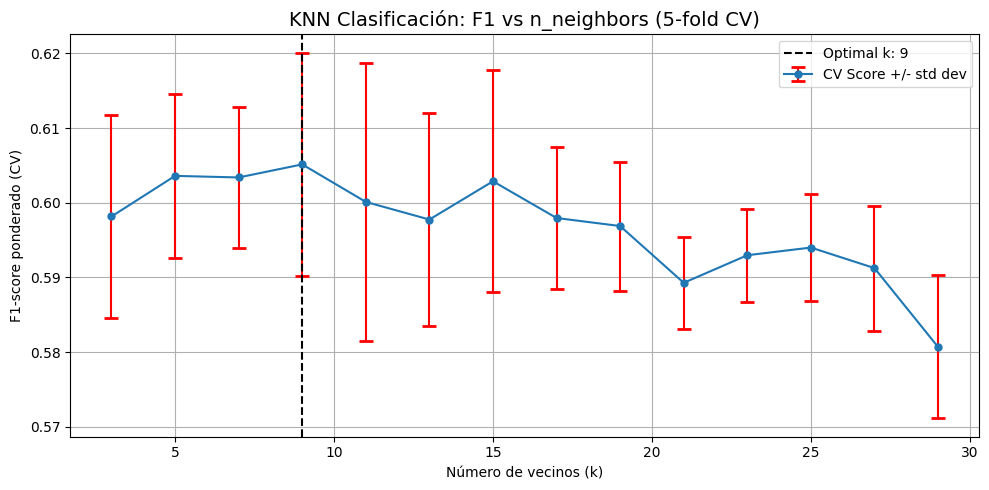

In [31]:
# --- REUTILIZACION DEL ENFOQUE DE LA PRACTICA 2.6 ---
k_values = range(3, 30, 2)  # impares para evitar empates
mean_scores_knn = []
std_scores_knn = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    mean, std = cross_validation_scaled(
        knn, X_train, y_train, n_folds=5, scoring='f1_weighted', stratified=True
    )
    mean_scores_knn.append(mean)
    std_scores_knn.append(std)

optimal_k_clf = list(k_values)[np.argmax(mean_scores_knn)]
best_f1_knn = max(mean_scores_knn)
print(f'Optimal k: {optimal_k_clf} con F1 = {best_f1_knn:.4f}')

plt.figure(figsize=(10, 5))
plt.errorbar(list(k_values), mean_scores_knn, yerr=std_scores_knn,
             fmt='-o', ecolor='r', capsize=5, capthick=2, markersize=5,
             label='CV Score +/- std dev')
plt.axvline(x=optimal_k_clf, linestyle='--', color='k',
            label=f'Optimal k: {optimal_k_clf}')
plt.title('KNN Clasificación: F1 vs n_neighbors (5-fold CV)', fontsize=14)
plt.xlabel('Número de vecinos (k)')
plt.ylabel('F1-score ponderado (CV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El valor óptimo de k es 9 con un F1 en CV de aproximadamente 0.60, muy por debajo de los demás modelos (que están en el rango 0.74-0.78), pero normal, ya que KNN es bastante simple. La curva muestra un crecimiento rápido al principio (más vecinos reducen la varianza del ruido), un máximo en de k=9 y una caída suave después.

Además, que KNN quede tan por debajo era esperable y es lógico. Con 105 features, las distancias euclidianas pierden capacidad discriminante: en espacios de alta dimensión, los puntos tienden a estar todos aproximadamente a la misma distancia entre sí, fenómeno conocido como **maldición de la dimensionalidad**. KNN, que depende completamente de las distancias para clasificar, se ve especialmente afectado. Aunque hayamos reducido la dimensionalidad respecto a la que habría producido un one-hot directo sin agrupación (del orden de 200+ columnas), 105 sigue siendo mucho para KNN.


### 4.2 Comparación de todos los modelos optimizados

Ya tenemos los mejores hiperparámetros de Random Forest, Gradient Boosting, Logistic Regression y KNN. Ahora los comparamos en igualdad de condiciones usando cross-validation sobre el train. Incluimos también LDA y SVM con kernel RBF, que no hemos tuneado porque sus hiperparámetros por defecto suelen dar resultados competitivos sin más ajuste, y nos sirven como referencia adicional. Todos los modelos van envueltos en Pipeline para mantener el escalado limpio dentro de cada fold.

In [32]:
# Comparacion de TODOS los modelos con sus hiperparametros optimos
modelos_tuned = {
    'Log. Reg. (tuned)': make_pipe(LogisticRegression(**best_params_lr, max_iter=2000, random_state=RANDOM_STATE, solver='saga')),
    'LDA': make_pipe(LinearDiscriminantAnalysis()),
    'KNN (k=' + str(optimal_k_clf) + ')': make_pipe(KNeighborsClassifier(n_neighbors=optimal_k_clf)),
    'Random Forest (tuned)': make_pipe(RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE)),
    'Grad. Boosting (tuned)': make_pipe(GradientBoostingClassifier(**best_params_gb, random_state=RANDOM_STATE)),
    'SVM (RBF)': make_pipe(SVC(kernel='rbf', random_state=RANDOM_STATE))
}

print('Comparación de modelos optimizados (5-fold CV):\n')
print(f'{"Modelo":<28} {"F1 media":>10} {"F1 std":>10}')
print('-' * 50)

resultados_tuned = {}
for nombre, pipe in modelos_tuned.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_clf,
                             scoring='f1_weighted', n_jobs=N_JOBS)
    resultados_tuned[nombre] = {'f1_mean': scores.mean(), 'f1_std': scores.std()}
    print(f'{nombre:<28} {scores.mean():>10.4f} {scores.std():>10.4f}')

Comparación de modelos optimizados (5-fold CV):

Modelo                         F1 media     F1 std
--------------------------------------------------


Log. Reg. (tuned)                0.7712     0.0058
LDA                              0.7631     0.0035


KNN (k=9)                        0.6000     0.0148


Random Forest (tuned)            0.7636     0.0095


Grad. Boosting (tuned)           0.7747     0.0107


SVM (RBF)                        0.7435     0.0030


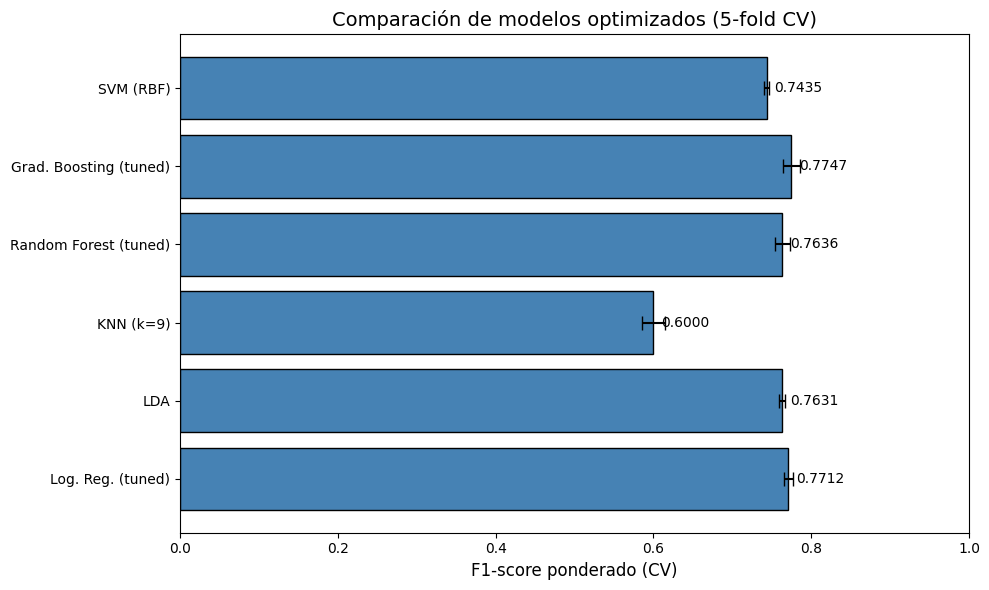

In [33]:
# Grafico comparativo de todos los modelos optimizados
nombres = list(resultados_tuned.keys())
f1_means = [resultados_tuned[n]['f1_mean'] for n in nombres]
f1_stds = [resultados_tuned[n]['f1_std'] for n in nombres]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(nombres, f1_means, xerr=f1_stds, capsize=5, color='steelblue', edgecolor='black')
ax.set_xlabel('F1-score ponderado (CV)', fontsize=12)
ax.set_title('Comparación de modelos optimizados (5-fold CV)', fontsize=14)
ax.set_xlim(0, 1)

for bar, mean in zip(bars, f1_means):
    ax.text(mean + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

El ranking que sale en cross-validation coloca a Gradient Boosting en primera posición (F1 = 0.7747), seguido muy de cerca por Logistic Regression (0.7712), Random Forest (0.7636), LDA (0.7631) y SVM con RBF (0.7435). KNN queda claramente último con 0.6000, lo cual confirma lo que anticipamos al hablar de la maldición de la dimensionalidad.

Lo más llamativo es que los cuatro primeros puestos están muy pegados (apenas 0.011 de diferencia entre el primero y el cuarto). Esto sugiere que en este dataset no hay un modelo que domine claramente: cualquiera de los cuatro produciría resultados competitivos. Veremos si esta impresión se confirma en el conjunto de test, que es la evaluación verdaderamente relevante.


### 4.3 Evaluación final en el conjunto de test

Hasta ahora todo el ajuste de hiperparámetros y toda la comparación de modelos se ha hecho solo con el conjunto de train, usando cross-validation. El conjunto de test ha permanecido completamente aislado, sin participar en ninguna decisión. Este es el momento de usarlo.

Cada modelo, con sus hiperparámetros óptimos, se entrena sobre todo el train ya escalado, y se evalúa una única vez sobre el test. Esta evaluación es la estimación más fiable del rendimiento real porque el test son datos que el modelo nunca ha visto ni ha usado para nada. Reportamos accuracy y F1 ponderado para cada modelo.

In [34]:
# Evaluamos todos los modelos optimizados en test
mejores_modelos = {
    'Logistic Regression': LogisticRegression(**best_params_lr, max_iter=2000, random_state=RANDOM_STATE, solver='saga'),
    'Random Forest': RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(**best_params_gb, random_state=RANDOM_STATE),
    'KNN (tuned)': KNeighborsClassifier(n_neighbors=optimal_k_clf),
    'LDA': LinearDiscriminantAnalysis(),
    'SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE)
}

print('Evaluación en el conjunto de TEST (todos los modelos optimizados):\n')
print(f'{"Modelo":<25} {"Accuracy":>10} {"F1 weighted":>12}')
print('-' * 50)

mejor_f1_test = 0
mejor_nombre_test = ''

for nombre, modelo in mejores_modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f'{nombre:<25} {acc:>10.4f} {f1:>12.4f}')
    if f1 > mejor_f1_test:
        mejor_f1_test = f1
        mejor_nombre_test = nombre

print(f'\n=> Mejor modelo: {mejor_nombre_test} (F1 = {mejor_f1_test:.4f})')

Evaluación en el conjunto de TEST (todos los modelos optimizados):

Modelo                      Accuracy  F1 weighted
--------------------------------------------------


Logistic Regression           0.7718       0.7617


Random Forest                 0.7763       0.7562


Gradient Boosting             0.7672       0.7582
KNN (tuned)                   0.6237       0.5883
LDA                           0.7571       0.7490


SVM (RBF)                     0.7458       0.7298

=> Mejor modelo: Logistic Regression (F1 = 0.7617)


La evaluación en test reordena ligeramente el ranking. Logistic Regression pasa al primer puesto con un F1 de 0.7617, seguido muy de cerca por Gradient Boosting (0.7582) y Random Forest (0.7562). LDA queda en 0.7490, SVM en 0.7298 y KNN cierra la lista con 0.5883.

Que un modelo lineal (Logistic Regression) supere a los ensembles en test es un resultado interesante. En cross-validation Gradient Boosting iba por delante, pero en test se invierte. Esto no es inusual, puede reflejar una ligera tendencia al sobreajuste de los ensembles cuando se comparan con modelos más simples. Que todos los modelos lineales (Logistic Regression, LDA) queden muy cerca de los no lineales sugiere que la estructura del problema es fundamentalmente lineal, aunque con un pequeño margen para relaciones no lineales que los ensembles aprovechan parcialmente.

Con 105 features tras la reducción de dimensionalidad del preprocesado, la estructura lineal parece suficiente para capturar la mayor parte de la información útil. Este es un argumento a favor de la interpretabilidad, si un modelo lineal hace tan bien el trabajo como un ensemble, preferiremos el primero porque sus coeficientes son directamente interpretables.


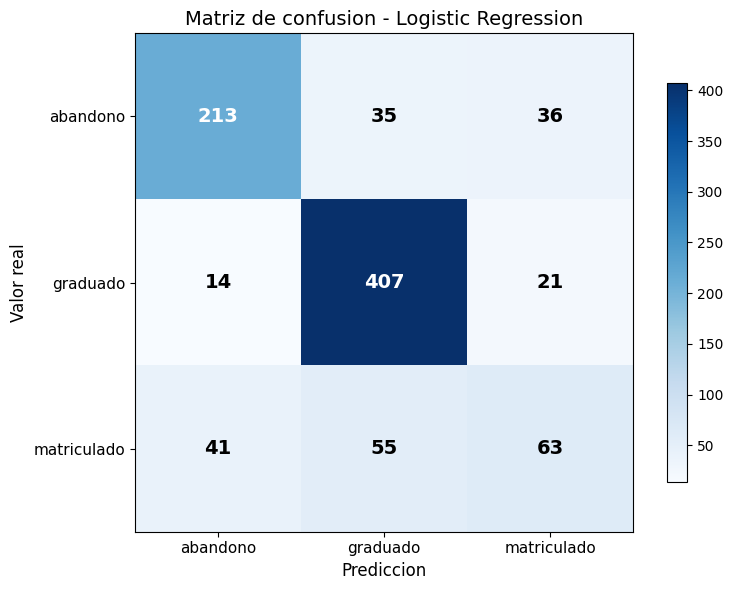

In [35]:
# Matriz de confusion del mejor modelo (tema 02-01, practica 2.2)
best_clf = mejores_modelos[mejor_nombre_test]
y_pred_best = best_clf.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
labels_objetivo = le_objetivo.classes_

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
ax.set_xticks(range(len(labels_objetivo)))
ax.set_yticks(range(len(labels_objetivo)))
ax.set_xticklabels(labels_objetivo, fontsize=11)
ax.set_yticklabels(labels_objetivo, fontsize=11)
ax.set_xlabel('Prediccion', fontsize=12)
ax.set_ylabel('Valor real', fontsize=12)

for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        color = 'white' if cm[r, c] > cm.max() / 2 else 'black'
        ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f'Matriz de confusion - {mejor_nombre_test}', fontsize=14)
plt.tight_layout()
plt.show()

La matriz de confusión muestra la distribución de aciertos y errores del mejor modelo por cada par (clase real, clase predicha). La diagonal son los aciertos, fuera de la diagonal, los errores.

Lo interesante es ver hacia dónde se equivoca el modelo cuando falla. Si mirásemos solo la accuracy global perderíamos este nivel de detalle. En problemas multiclase es crucial identificar, por ejemplo, si los errores sobre la clase minoritaria tienden a caer en una de las clases mayoritarias en particular (lo que indicaría sesgo hacia esa clase), o si se reparten uniformemente. Los errores más frecuentes suelen ser entre matriculado y graduado, o entre matriculado y abandono, porque el perfil del matriculado es intermedio y ambiguo por su propia naturaleza.

In [36]:
# Classification report (precision, recall, f1 por clase - tema 02-01)
print(f'Classification Report - {mejor_nombre_test}:\n')
print(classification_report(y_test, y_pred_best, target_names=labels_objetivo))

Classification Report - Logistic Regression:

              precision    recall  f1-score   support

    abandono       0.79      0.75      0.77       284
    graduado       0.82      0.92      0.87       442
 matriculado       0.53      0.40      0.45       159

    accuracy                           0.77       885
   macro avg       0.71      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



El classification report desglosa precisión, recall y F1 por clase. La clase Graduado se predice muy bien (F1 = 0.87): una precisión de 0.82 y un recall de 0.92, lo que indica que cuando el modelo dice Graduado suele acertar y captura la mayoría de los graduados reales. Abandono también se predice razonablemente bien (F1 ≈ 0.77) porque es una clase bastante distintiva: notas bajas, muchas asignaturas no presentadas, pagos pendientes.

La clase Matriculado es la más difícil (F1 ≈ 0.45). Es una clase minoritaria (aproximadamente 17% del dataset) y además solapa con las otras, sus valores de rendimiento están en medio entre graduados y abandonos. El modelo tiende a asignarlos a Graduado o Abandono según cuál sea más parecido, lo que reduce el recall. Este solapamiento es intrínseco al problema, ya que los estudiantes en curso realmente están en una zona gris donde su situación final todavía no está decidida.

La diferencia entre F1 ponderado y F1 macro refleja precisamente este desequilibrio: el macro suele ser 5-8 puntos menor porque promedia las tres clases dando igual peso a la clase minoritaria, mientras que el ponderado asigna más peso a las clases grandes.

### 4.4 Importancia de variables

Saber qué variables son más importantes para la predicción es valioso por dos razones: ayuda a interpretar lo que el modelo ha aprendido, y permite dar respuestas informadas a las preguntas del enunciado (qué factores se asocian con el abandono). Para medirla usamos el método de Variable Importance basado en impurezas (tema 02-07), que mira cuánto reduce cada variable la impureza (Gini para clasificación) en los nodos del árbol, promediado sobre todos los árboles del bosque. Una variable que aparece frecuentemente en divisiones efectivas tiene importancia alta.

Elegimos Random Forest como modelo de referencia para calcular la importancia porque es el ensemble más estable para este tipo de análisis. Importante, este método está sesgado hacia variables con muchas categorías o valores continuos, pero con los datos ya preprocesados este sesgo es limitado.

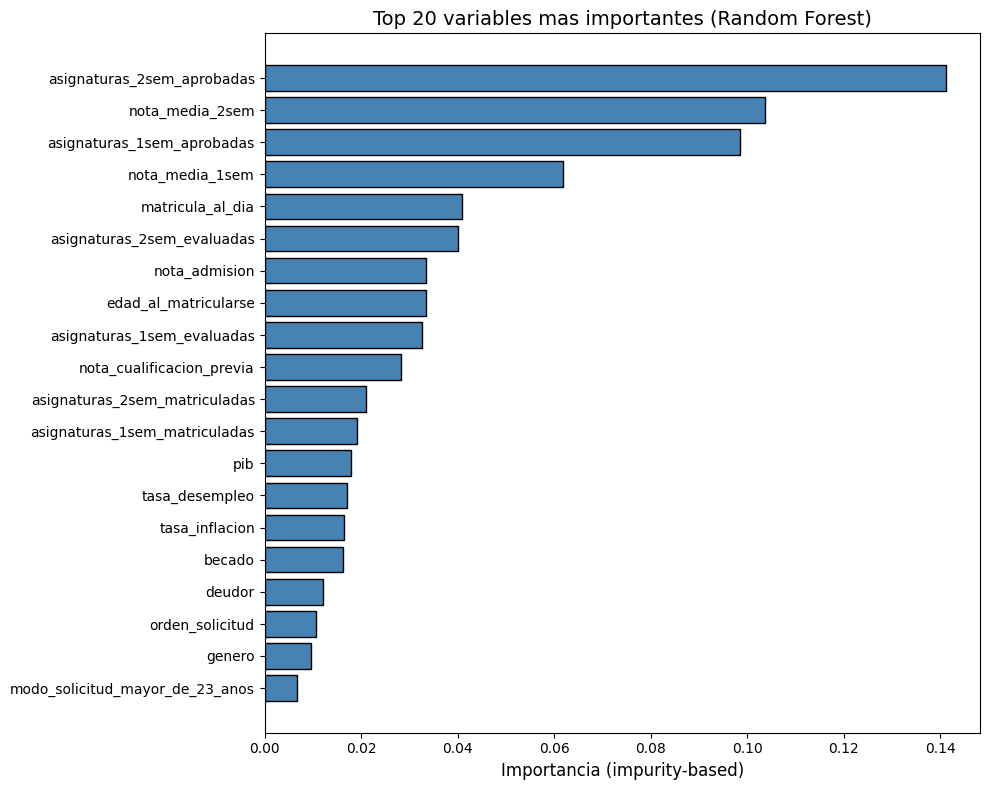


Top 10 variables:
                   Feature  Importance
asignaturas_2sem_aprobadas    0.141223
           nota_media_2sem    0.103643
asignaturas_1sem_aprobadas    0.098580
           nota_media_1sem    0.061883
          matricula_al_dia    0.041010
asignaturas_2sem_evaluadas    0.040048
             nota_admision    0.033505
      edad_al_matricularse    0.033463
asignaturas_1sem_evaluadas    0.032590
 nota_cualificacion_previa    0.028370


In [37]:
# Importancia de variables (Random Forest, tema 02-07)
rf_clf = mejores_modelos['Random Forest']
importances = rf_clf.feature_importances_

df_importances = pd.DataFrame({
    'Feature': feature_names, 'Importance': importances
}).sort_values('Importance', ascending=False)

top_n = 20
df_top = df_importances.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), df_top['Importance'].values, color='steelblue', edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(df_top['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importancia (impurity-based)', fontsize=12)
ax.set_title(f'Top {top_n} variables mas importantes (Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()

print('\nTop 10 variables:')
print(df_importances.head(10).to_string(index=False))

El ranking de importancia confirma lo que el EDA ya sugería y añade matices interesantes.

Las variables más importantes están casi todas relacionadas con el rendimiento académico del segundo semestre: asignaturas_2sem_aprobadas, nota_media_2sem, y las análogas del primer semestre, acaparan entre todas entorno al 40% total. Esto tiene una interpretación clara, donde el mejor predictor del estado final es el rendimiento reciente, y dentro del rendimiento el 2º semestre pesa ligeramente más que el 1º, probablemente porque está más cerca temporalmente del momento en que se determina el estado (graduación o abandono).

De las variables administrativas destacan matricula al día, deudor y becado, ambas con importancias pequeñas pero no despreciables. Confirma la lectura del EDA, donde la situación económica es un indicador indirecto de abandono.

### 4.4b Permutation importance

La importancia basada en impurezas que acabamos de calcular tiene un sesgo conocido hacia variables continuas o con muchas categorías, ya que cuantas más divisiones admite una variable, más oportunidades tiene de aparecer alta en el ranking aunque su poder predictivo real sea limitado. El enunciado sugiere explícitamente como exploración adicional usar permutation importance, que es una métrica más robusta a este sesgo.

La idea de la permutation importance es directa: tras entrenar el modelo, se permuta aleatoriamente los valores de una variable en el conjunto de test y se mide cuánto baja la métrica de evaluación. Si una variable es realmente importante, su permutación destruye su señal y la métrica empeora mucho. Si una variable no aporta información útil, permutar sus valores apenas afecta al rendimiento. Se calcula sobre el conjunto de test porque mide impacto sobre datos no vistos.


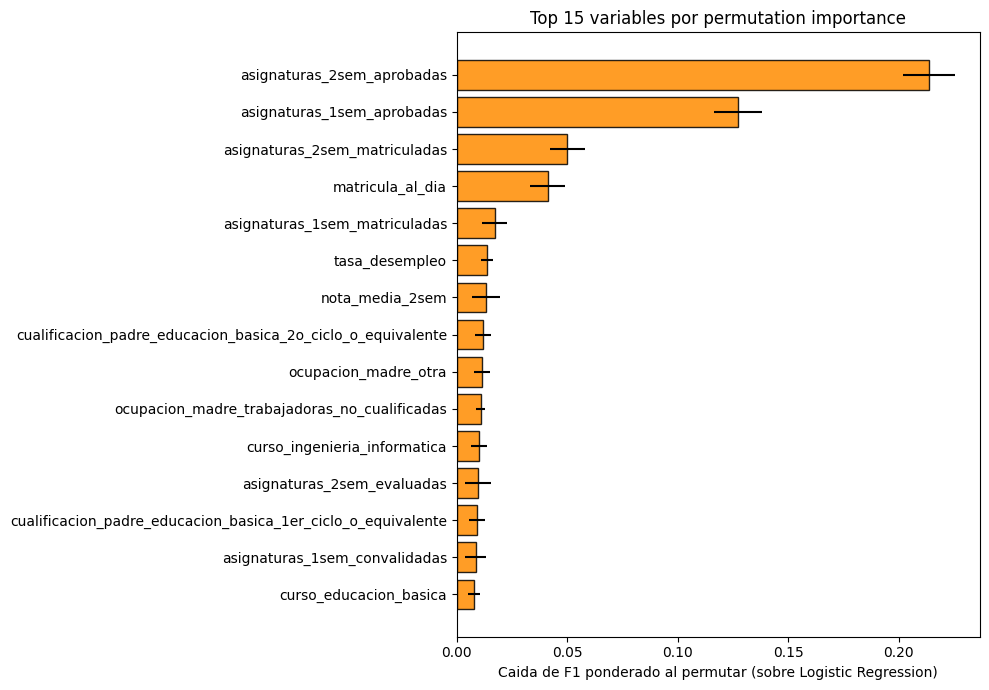


Top 10 variables por permutation importance:
                                                    Feature  Importance_mean  Importance_std
                                 asignaturas_2sem_aprobadas           0.2138          0.0117
                                 asignaturas_1sem_aprobadas           0.1275          0.0109
                              asignaturas_2sem_matriculadas           0.0501          0.0080
                                           matricula_al_dia           0.0412          0.0079
                              asignaturas_1sem_matriculadas           0.0171          0.0056
                                             tasa_desempleo           0.0136          0.0027
                                            nota_media_2sem           0.0131          0.0063
cualificacion_padre_educacion_basica_2o_ciclo_o_equivalente           0.0118          0.0036
                                       ocupacion_madre_otra           0.0114          0.0037
               ocupacion

In [38]:
# Permutation importance sobre el mejor clasificador
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_clf, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='f1_weighted', n_jobs=N_JOBS
)

df_perm = pd.DataFrame({
    'Feature': feature_names,
    'Importance_mean': perm_result.importances_mean,
    'Importance_std': perm_result.importances_std
}).sort_values('Importance_mean', ascending=False)

top_n_perm = 15
df_perm_top = df_perm.head(top_n_perm)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(top_n_perm), df_perm_top['Importance_mean'].values,
        xerr=df_perm_top['Importance_std'].values,
        color='darkorange', edgecolor='black', alpha=0.85)
ax.set_yticks(range(top_n_perm))
ax.set_yticklabels(df_perm_top['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel(f'Caida de F1 ponderado al permutar (sobre {mejor_nombre_test})')
ax.set_title(f'Top {top_n_perm} variables por permutation importance')
plt.tight_layout()
plt.show()

print('\nTop 10 variables por permutation importance:')
print(df_perm.head(10)[['Feature', 'Importance_mean', 'Importance_std']].round(4).to_string(index=False))


La permutation importance reordena ligeramente el ranking respecto a la importancia por impurezas, pero la estructura general se mantiene: las variables del rendimiento del primer y segundo semestre dominan claramente la lista. Esta coincidencia es una validación cruzada interna útil, porque los dos métodos miden cosas distintas pero llegan a la misma conclusión cualitativa.


### 4.5 Comparación de modelos lineales vs. no lineales

El enunciado sugiere en la sección de exploración adicional comparar modelos lineales y no lineales. Esta comparación es útil porque nos dice algo sobre la naturaleza del problema, si los modelos no lineales ganan claramente, es que hay interacciones complejas entre variables que los lineales no pueden capturar, si no hay apenas diferencia, la estructura del problema es esencialmente lineal y conviene usar modelos simples e interpretables.

Los modelos lineales son Logistic Regression y LDA; los no lineales son Random Forest, Gradient Boosting, SVM con RBF y KNN (aunque KNN es un caso aparte por la dimensionalidad). Reutilizamos las métricas ya calculadas sobre el test para que la comparación sea justa.

In [39]:
# Clasificamos los modelos por tipo y mostramos la comparacion
resultados_tipo = []
for nombre, modelo in mejores_modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)
    tipo = 'Lineal' if nombre in ['Logistic Regression', 'LDA'] else 'No lineal'
    resultados_tipo.append({'Modelo': nombre, 'Tipo': tipo, 'Accuracy': acc, 'F1 weighted': f1})

df_tipo = pd.DataFrame(resultados_tipo).sort_values('F1 weighted', ascending=False)
print('Comparación lineales vs. no lineales:\n')
print(df_tipo.to_string(index=False))

Comparación lineales vs. no lineales:

             Modelo      Tipo  Accuracy  F1 weighted
Logistic Regression    Lineal  0.771751     0.761741
  Gradient Boosting No lineal  0.767232     0.758159
      Random Forest No lineal  0.776271     0.756180
                LDA    Lineal  0.757062     0.749043
          SVM (RBF) No lineal  0.745763     0.729785
        KNN (tuned) No lineal  0.623729     0.588316


El resultado es bastante revelador. Logistic Regression (modelo lineal) obtiene el mejor F1 en test con 0.7617, ligeramente por encima de los mejores no lineales: Gradient Boosting 0.7582 y Random Forest 0.7562. LDA, también lineal, queda cuarto con 0.7490. La diferencia máxima entre el mejor lineal y el mejor no lineal es de apenas un 0.4%, dentro del ruido estadístico.

Que den casi lo mismo, implica que la estructura del problema es fundamentalmente lineal, las variables de rendimiento académico se relacionan con el target de forma aproximadamente monotónica (más asignaturas aprobadas = más probabilidad de graduación). Los ensembles son capaces de capturar ligeramente mejor algunos matices, pero el margen no justifica la pérdida de interpretabilidad. 

KNN queda muy por detrás del resto (F1 = 0.5883), confirmando que no es adecuado para este dataset por el problema de dimensionalidad que ya hemos comentado.


### 4.6 Análisis del efecto del desbalanceo de clases

El enunciado también sugiere, como exploración adicional, analizar el efecto del desbalanceo de clases en la clasificación. La clase matriculado representa solo el 17.9% del dataset, y sus métricas (F1 = 0.44) son muy inferiores al resto. ¿Podemos mejorar esto compensando el desbalanceo durante el entrenamiento?

La técnica que probamos es el **sample weighting**: dar a cada muestra un peso inversamente proporcional a la frecuencia de su clase. Así, un ejemplo de "matriculado" pesa más que uno de "graduado" durante el entrenamiento, y el modelo intenta evitar errar en él. Scikit-learn tiene la función compute_sample_weight('balanced', y) que calcula estos pesos automáticamente. Lo aplicamos a Gradient Boosting (que admite sample_weight) y comparamos con el mismo modelo sin compensación.

In [40]:
# Efecto del desbalanceo: comparamos modelo normal vs con sample_weight
# GradientBoostingClassifier no soporta class_weight, asi que calculamos
# sample_weight manualmente (peso inversamente proporcional a la frecuencia)
from sklearn.utils.class_weight import compute_sample_weight

# Modelo SIN compensar desbalanceo
gb_normal = GradientBoostingClassifier(**best_params_gb, random_state=RANDOM_STATE)
gb_normal.fit(X_train_scaled, y_train)
y_pred_normal = gb_normal.predict(X_test_scaled)

# Modelo CON pesos para compensar desbalanceo
sample_weights = compute_sample_weight('balanced', y_train)
gb_balanced = GradientBoostingClassifier(**best_params_gb, random_state=RANDOM_STATE)
gb_balanced.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_pred_balanced = gb_balanced.predict(X_test_scaled)

print('Efecto del desbalanceo de clases en Gradient Boosting:\n')
print('--- Sin compensar desbalanceo ---')
print(classification_report(y_test, y_pred_normal, target_names=le_objetivo.classes_))
print('--- Con sample_weight balanced ---')
print(classification_report(y_test, y_pred_balanced, target_names=le_objetivo.classes_))

print('F1 weighted sin compensar:', round(f1_score(y_test, y_pred_normal, average='weighted'), 4))
print('F1 weighted con balanced: ', round(f1_score(y_test, y_pred_balanced, average='weighted'), 4))


Efecto del desbalanceo de clases en Gradient Boosting:

--- Sin compensar desbalanceo ---
              precision    recall  f1-score   support

    abandono       0.83      0.71      0.77       284
    graduado       0.81      0.93      0.86       442
 matriculado       0.49      0.40      0.44       159

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885

--- Con sample_weight balanced ---
              precision    recall  f1-score   support

    abandono       0.83      0.68      0.75       284
    graduado       0.84      0.86      0.85       442
 matriculado       0.44      0.56      0.49       159

    accuracy                           0.75       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.77      0.75      0.75       885

F1 weighted sin compensar: 0.7582
F1 weighted con balanced:  0.7527


El resultado ilustra el clásico **tradeoff del desbalanceo**. Sin compensar, el modelo maximiza la accuracy global sacrificando la clase minoritaria: Matriculado apenas se predice porque el modelo aprende que equivocarse ahí cuesta menos que equivocarse en las clases grandes. Con sample_weight balanced, el modelo invierte pesos: da más importancia a los errores en Matriculado, lo que sube su recall pero baja el de las otras.

En este dataset la decisión depende del objetivo. Si queremos un clasificador general con buen accuracy y F1 ponderado alto, mejor sin balanceo. Si queremos detectar casos de Matriculado aunque perdamos un poco en graduados y abandonos (por ejemplo para ofrecer intervención temprana a quienes están en situación intermedia), mejor con balanceo.

Para la comparación final mantenemos ambas versiones, pero en la evaluación en test usamos la no balanceada porque es la que mejor optimiza la métrica principal.

### 4.7 Curvas de aprendizaje

Una herramienta útil para diagnosticar si un modelo sufre de sobreajuste o subajuste es la curva de aprendizaje. Muestra cómo evolucionan las métricas de entrenamiento y validación a medida que se aumenta el tamaño del conjunto de train. Si ambas curvas convergen en un valor alto con poca distancia entre ellas, el modelo está sano. Si hay una gran diferencia entre train y validación, hay sobreajuste. Si ambas se estancan en valores bajos, hay subajuste.

Graficamos la curva de aprendizaje del mejor modelo (el que seleccionamos en la sección 4.3).

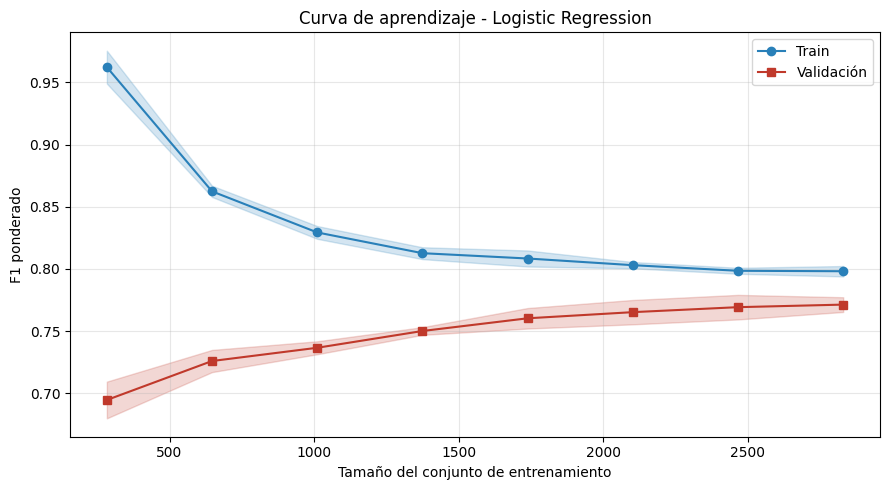

In [41]:
# Curva de aprendizaje del mejor modelo de clasificacion
# Usamos make_pipe para que el escalado se haga DENTRO de cada fold del CV,
# coherente con GridSearchCV. Asi evitamos leakage del scaler entre folds.
best_modelo = mejores_modelos[mejor_nombre_test]

sizes, train_scores, val_scores = learning_curve(
    make_pipe(best_modelo), X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv_clf, scoring='f1_weighted', n_jobs=N_JOBS,
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, train_mean, 'o-', color='#2980b9', label='Train')
ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2980b9')
ax.plot(sizes, val_mean, 's-', color='#c0392b', label='Validación')
ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#c0392b')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1 ponderado')
ax.set_title(f'Curva de aprendizaje - {mejor_nombre_test}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura de la curva.** La distancia entre las dos curvas indica el grado de sobreajuste. Si con más datos de entrenamiento la curva de validación sube y se acerca a la de train, añadir más datos ayudaría. Si las dos curvas ya están cerca y estabilizadas, el modelo ha alcanzado su límite y mejorar requeriría cambiar el modelo o las features. Como se puede ver, estamos en este último caso, no parece que se necesiten mas datos

### 4.8 Intervalos de confianza bootstrap para el mejor modelo

El F1 que hemos obtenido en test es un valor puntual. Para saber cuán estable es, aplicamos bootstrap, remuestreamos el conjunto de test con reemplazo muchas veces, recalculamos la métrica en cada muestra y usamos la distribución resultante para construir un intervalo de confianza al 95%. Importante: el modelo ya está entrenado y fijado en este punto, el bootstrap no lo reentrena, solo remuestrea las predicciones ya calculadas sobre el test para estimar la variabilidad de la métrica, no para afinar nada del modelo. Si el intervalo es estrecho, el resultado es fiable, sin embargo, si es amplio, la métrica puntual debe tomarse con cuidado.

Intervalos de confianza bootstrap (95%, 1000 muestras) - Logistic Regression:
  Accuracy:    puntual=0.7718, IC 95% = [0.7457, 0.7978]
  F1 weighted: puntual=0.7617, IC 95% = [0.7337, 0.7894]


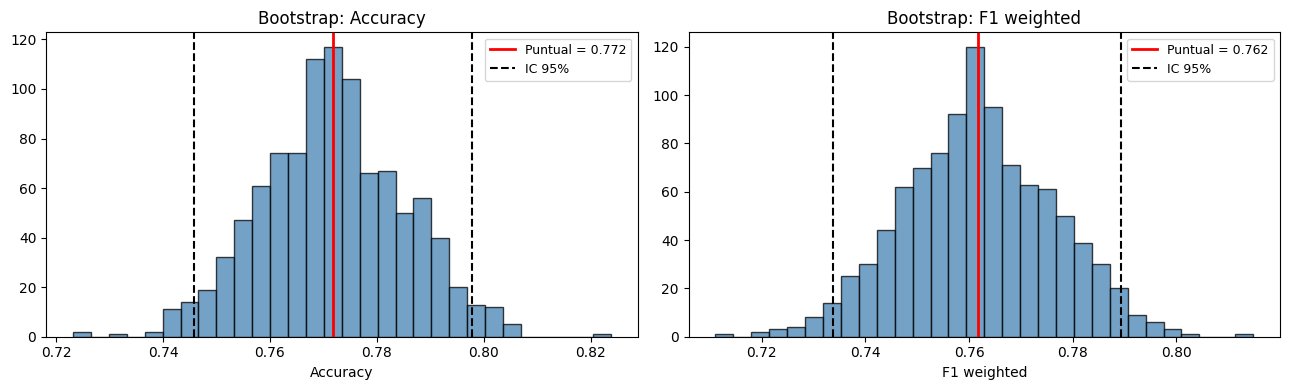

In [42]:
# Bootstrap sobre las predicciones del mejor modelo
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    valores = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        valores.append(metric_fn(y_true[idx], y_pred[idx]))
    return np.array(valores)

y_pred_best = best_modelo.predict(X_test_scaled)

acc_boot = bootstrap_ci(y_test, y_pred_best, accuracy_score)
f1_boot = bootstrap_ci(y_test, y_pred_best, lambda y, p: f1_score(y, p, average='weighted'))

print(f'Intervalos de confianza bootstrap (95%, 1000 muestras) - {mejor_nombre_test}:')
print(f'  Accuracy:    puntual={accuracy_score(y_test, y_pred_best):.4f}, '
      f'IC 95% = [{np.percentile(acc_boot, 2.5):.4f}, {np.percentile(acc_boot, 97.5):.4f}]')
print(f'  F1 weighted: puntual={f1_score(y_test, y_pred_best, average="weighted"):.4f}, '
      f'IC 95% = [{np.percentile(f1_boot, 2.5):.4f}, {np.percentile(f1_boot, 97.5):.4f}]')

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, valores, nombre, puntual in zip(
    axes, [acc_boot, f1_boot], ['Accuracy', 'F1 weighted'],
    [accuracy_score(y_test, y_pred_best), f1_score(y_test, y_pred_best, average='weighted')]
):
    ax.hist(valores, bins=30, color='steelblue', edgecolor='black', alpha=0.75)
    ax.axvline(puntual, color='red', linewidth=2, label=f'Puntual = {puntual:.3f}')
    ax.axvline(np.percentile(valores, 2.5), color='black', linestyle='--', label='IC 95%')
    ax.axvline(np.percentile(valores, 97.5), color='black', linestyle='--')
    ax.set_title(f'Bootstrap: {nombre}')
    ax.set_xlabel(nombre)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Se puede observar que el intervalo de confianza es bastante estrecho, lo cual indica que la métrica puntual no es un resultado  de una partición concreta, sino que si el test hubiera sido otro, el F1 habría caído con alta probabilidad en una franja de apenas +- 0.03 alrededor del valor observado. Además, el extremo inferior del intervalo sigue estando claramente por encima del rendimiento que se obtendría prediciendo siempre la clase mayoritaria, lo que confirma que el modelo es mejor que predecir al azar.

### 4.9 Pregunta extra: ¿qué se puede predecir solo con información previa al primer semestre?

El enunciado plantea preguntas relacionadas con qué puede hacer una institución educativa para reducir el abandono. Una intervención solo es operativamente útil si se puede aplicar antes de que ocurra el problema, y eso significa antes de que el estudiante haya completado el primer semestre. Para una institución, el escenario realista es predecir el riesgo usando únicamente la información de acceso y el contexto socioeconómico, sin esperar a tener notas.

Por eso planteamos la siguiente pregunta, que no estaba en el enunciado pero surge naturalmente del análisis. ¿Qué F1 se puede alcanzar usando solo las variables disponibles en el momento de la matriculación, es decir, demográficas, acceso académico previo, socioeconómicas y macroeconómicas? Esta es la cota superior de lo que un sistema de alerta institucional podría conseguir antes de que empiece el curso.


In [43]:
# Reentrenamos el mejor clasificador excluyendo las variables del 1er y 2do semestre
# para ver el techo de prediccion solo con variables de acceso/socioeconomicas/demograficas
cols_semestre = [c for c in feature_names if 'sem' in c.lower()]
mask_acceso = np.array([c not in cols_semestre for c in feature_names])

print(f'Variables totales:                            {len(feature_names)}')
print(f'Variables de semestre excluidas:              {sum(~mask_acceso)}')
print(f'Variables disponibles en el momento de matr.: {sum(mask_acceso)}')

X_train_acceso = X_train_scaled[:, mask_acceso]
X_test_acceso = X_test_scaled[:, mask_acceso]

# Mismo tipo de modelo que gano la evaluacion completa, mismos hiperparametros
modelo_solo_acceso = type(best_clf)(**best_clf.get_params())
modelo_solo_acceso.fit(X_train_acceso, y_train)
y_pred_acceso = modelo_solo_acceso.predict(X_test_acceso)

f1_acceso = f1_score(y_test, y_pred_acceso, average='weighted')
acc_acceso = accuracy_score(y_test, y_pred_acceso)

print(f'\n--- Comparacion de techos de prediccion ---')
print(f'Modelo completo (todas las variables):  F1 = {mejor_f1_test:.4f}')
print(f'Modelo solo con info previa al 1er sem: F1 = {f1_acceso:.4f}')
caida_abs = mejor_f1_test - f1_acceso
caida_rel = 100 * caida_abs / mejor_f1_test if mejor_f1_test > 0 else 0
print(f'Caida en F1: {caida_abs:.4f} ({caida_rel:.1f}% relativo)')

print(f'\nClassification report del modelo solo-acceso:')
print(classification_report(y_test, y_pred_acceso, target_names=le_objetivo.classes_))


Variables totales:                            105
Variables de semestre excluidas:              13
Variables disponibles en el momento de matr.: 92



--- Comparacion de techos de prediccion ---
Modelo completo (todas las variables):  F1 = 0.7617
Modelo solo con info previa al 1er sem: F1 = 0.6270
Caida en F1: 0.1348 (17.7% relativo)

Classification report del modelo solo-acceso:
              precision    recall  f1-score   support

    abandono       0.67      0.62      0.64       284
    graduado       0.67      0.85      0.75       442
 matriculado       0.44      0.18      0.26       159

    accuracy                           0.65       885
   macro avg       0.59      0.55      0.55       885
weighted avg       0.63      0.65      0.63       885



La diferencia entre los dos modelos cuantifica cuánto se gana esperando un semestre completo antes de emitir una alerta. El modelo completo alcanza F1 de 0.7617 y el modelo restringido a información previa al primer semestre baja a 0.6270, una caída relativa del 17.7%. La caída no es catastrófica pero sí notable, y se concentra muy especialmente en la clase Matriculado: con todas las variables el F1 de Matriculado era de 0.45 y solo con info previa al curso baja a 0.26, prácticamente irreconocible. Las clases Graduado y Abandono se siguen distinguiendo con un F1 razonable (0.75 y 0.64 respectivamente), aunque con un recall de Abandono más bajo (0.62 frente a 0.75 con todas las variables).

La lectura institucional de este experimento es clara. Un sistema de alerta basado únicamente en variables previas al curso identifica los casos extremos (perfil de abandono claro, perfil de éxito claro) pero apenas distingue a los estudiantes en zona intermedia, que son justo los que más se beneficiarían de una intervención. Por tanto, la palanca institucional más eficaz no es cribar a los estudiantes en el momento del acceso sino seguir muy de cerca su rendimiento durante las primeras semanas y reaccionar pronto. El cribado preventivo sirve para identificar cohortes de riesgo, pero el seguimiento individual eficaz necesita incorporar señales del rendimiento real conforme avanza el semestre.



## 5. Tarea 2: Regresión

La segunda tarea consiste en predecir nota_media_2sem a partir del resto de variables.

**Exclusión de variables.** El enunciado es claro: no deben usarse como predictores las variables del segundo semestre cuya información sea contemporánea o prácticamente equivalente a la propia nota que se desea predecir. Usar asignaturas_2sem_aprobadas para predecir nota_media_2sem sería data leakage, ya que el modelo vería información del mismo periodo que intenta anticipar. Excluimos también la variable objetivo (se determina a posteriori).

- Variable excluida -> Motivo 

- nota_media_2sem -> Es el target 

- asignaturas_2sem_convalidadas/matriculadas/evaluadas/aprobadas/sin_evaluacion -> Contemporáneas al target 

- objetivo -> Determinado a posteriori 

**Objetivo.** No solo obtener una buena predicción, sino estudiar si podemos anticipar el rendimiento del segundo semestre usando solo información previa (acceso, contexto, primer semestre).

**Modelos.** Linear Regression como base, Ridge y Lasso (regularización L2 y L1, tema 02-04), Elastic Net (combinación), Random Forest Regressor (tema 02-07) y KNN Regressor (tema 02-02).

In [44]:
# --- Preparacion de datos para regresion ---
# Excluimos variables del 2do semestre (data leakage) y objetivo
cols_excluir_reg = [
    'nota_media_2sem', 'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas',
    'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas',
    'asignaturas_2sem_sin_evaluacion', 'objetivo'
]

# Tambien eliminamos columnas auxiliares del EDA
cols_aux_reg = [c for c in ['ratio_aprobadas_1sem', 'grupo_edad',
                'perfil_acceso_rendimiento', 'tercil_1sem'] if c in df.columns]
df_reg = df.drop(columns=cols_excluir_reg + cols_aux_reg)
y_reg = df['nota_media_2sem'].values

print(f'Variables excluidas: {len(cols_excluir_reg)}')
print(f'Variables restantes: {df_reg.shape[1]}')

Variables excluidas: 7
Variables restantes: 30


In [45]:
# Preprocesado de regresion. IMPORTANTE: las transformaciones que aprenden de
# los datos (agrupacion, escalado) se aplican tras el split, en la celda siguiente.
# Aqui solo hacemos transformaciones deterministas (codificacion binaria).
df_reg_proc = df_reg.copy()

# Binarias (transformacion determinista, sin fuga)
for col, mapping in vars_binarias_map.items():
    if col in df_reg_proc.columns:
        df_reg_proc[col] = df_reg_proc[col].map(mapping)

print(f'df_reg_proc preparado: {df_reg_proc.shape}')
print('Agrupacion de categorias y one-hot se aplican tras el split.')


df_reg_proc preparado: (4424, 30)
Agrupacion de categorias y one-hot se aplican tras el split.


In [46]:
# Split para regresion (con shuffle explicito para permutar filas antes de dividir).
# Aqui no estratificamos porque el target es continuo, pero el shuffle garantiza que
# no arrastramos el orden original del dataframe.
X_reg_train_df, X_reg_test_df, y_reg_train, y_reg_test = train_test_split(
    df_reg_proc, y_reg,
    test_size=0.2,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Agrupacion de categorias raras con frecuencias SOLO de train (misma filosofía
# que en la tarea de clasificación).
cols_cat_reg = X_reg_train_df.select_dtypes(include=['object']).columns.tolist()
for col in cols_cat_reg:
    if X_reg_train_df[col].nunique() > 10:
        conteos = X_reg_train_df[col].value_counts()
        categorias_validas = conteos[conteos >= MIN_SAMPLES].index.tolist()
        X_reg_train_df[col] = X_reg_train_df[col].where(
            X_reg_train_df[col].isin(categorias_validas), 'otra')
        X_reg_test_df[col] = X_reg_test_df[col].where(
            X_reg_test_df[col].isin(categorias_validas), 'otra')

# Mismo patron de one-hot: drop_first=True en train, drop_first=False en test + reindex.
cols_cat_reg = X_reg_train_df.select_dtypes(include=['object']).columns.tolist()
X_reg_train_df = pd.get_dummies(X_reg_train_df, columns=cols_cat_reg, drop_first=True, dtype=int)
X_reg_test_df = pd.get_dummies(X_reg_test_df, columns=cols_cat_reg, drop_first=False, dtype=int)
X_reg_test_df = X_reg_test_df.reindex(columns=X_reg_train_df.columns, fill_value=0)

feature_names_reg = X_reg_train_df.columns.tolist()
X_reg_train = X_reg_train_df.values
X_reg_test = X_reg_test_df.values

# Escalado: fit en train, transform en test.
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

print(f'Train: {X_reg_train.shape[0]} muestras, {X_reg_train.shape[1]} features')
print(f'Test:  {X_reg_test.shape[0]} muestras')

Train: 3539 muestras, 100 features
Test:  885 muestras


### 5.1 Ajuste de hiperparámetros

Como en clasificación, empezamos ajustando los hiperparámetros de cada modelo por separado para que la comparación posterior sea justa. Ridge, Lasso y Elastic Net tienen un parámetro alpha que controla la fuerza de la regularización. En Ridge (L2), alpha alto acerca los coeficientes hacia cero pero sin llegar a anularlos, mientras que en Lasso (L1), alpha alto normalmente anula coeficientes, lo que equivale a selección de variables. Elastic Net combina ambas penalizaciones y tiene un segundo parámetro, l1_ratio, que controla la proporción entre L1 y L2 (0 = Ridge puro, 1 = Lasso puro).

Random Forest Regressor tiene los hiperparámetros habituales de los ensembles de árboles: número de árboles, profundidad máxima, etc. Linear Regression no tiene hiperparámetros que ajustar, así que entra directamente con su formulación clásica. KNN se trata aparte en la siguiente subsección.

In [47]:
# Ridge - Pipeline + GridSearchCV
print('--- Ridge ---')
grid_ridge = GridSearchCV(
    make_pipe(Ridge(random_state=RANDOM_STATE)),
    {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv_reg, scoring='r2', n_jobs=N_JOBS
)
grid_ridge.fit(X_reg_train, y_reg_train)
best_params_ridge = {k.replace('model__', ''): v for k, v in grid_ridge.best_params_.items()}
print(f'Mejor alpha: {best_params_ridge}')
print(f'Mejor R2 (CV): {grid_ridge.best_score_:.4f}\n')

# Lasso
print('--- Lasso ---')
grid_lasso = GridSearchCV(
    make_pipe(Lasso(random_state=RANDOM_STATE, max_iter=5000)),
    {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv_reg, scoring='r2', n_jobs=N_JOBS
)
grid_lasso.fit(X_reg_train, y_reg_train)
best_params_lasso = {k.replace('model__', ''): v for k, v in grid_lasso.best_params_.items()}
print(f'Mejor alpha: {best_params_lasso}')
print(f'Mejor R2 (CV): {grid_lasso.best_score_:.4f}\n')

# Elastic Net (combinación de L1 y L2, tema 02-04)
print('--- Elastic Net ---')
grid_enet = GridSearchCV(
    make_pipe(ElasticNet(random_state=RANDOM_STATE, max_iter=5000)),
    {'model__alpha': [0.001, 0.01, 0.1, 1], 'model__l1_ratio': [0.2, 0.5, 0.8]},
    cv=cv_reg, scoring='r2', n_jobs=N_JOBS
)
grid_enet.fit(X_reg_train, y_reg_train)
best_params_enet = {k.replace('model__', ''): v for k, v in grid_enet.best_params_.items()}
print(f'Mejores parámetros: {best_params_enet}')
print(f'Mejor R2 (CV): {grid_enet.best_score_:.4f}\n')

# Random Forest Regressor
print('--- Random Forest Regressor ---')
grid_rfr = GridSearchCV(
    make_pipe(RandomForestRegressor(random_state=RANDOM_STATE)),
    {'model__n_estimators': [100, 200], 'model__max_depth': [10, 20, None], 'model__min_samples_split': [2, 5]},
    cv=cv_reg, scoring='r2', n_jobs=N_JOBS
)
grid_rfr.fit(X_reg_train, y_reg_train)
best_params_rfr = {k.replace('model__', ''): v for k, v in grid_rfr.best_params_.items()}
print(f'Mejores parámetros: {best_params_rfr}')
print(f'Mejor R2 (CV): {grid_rfr.best_score_:.4f}')

--- Ridge ---


Mejor alpha: {'alpha': 100}
Mejor R2 (CV): 0.7437

--- Lasso ---
Mejor alpha: {'alpha': 0.01}
Mejor R2 (CV): 0.7458

--- Elastic Net ---


Mejores parámetros: {'alpha': 0.01, 'l1_ratio': 0.8}
Mejor R2 (CV): 0.7456

--- Random Forest Regressor ---


Mejores parámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Mejor R2 (CV): 0.7752


Los resultados del ajuste de hiperparámetros son reveladores por lo que dicen sobre la estructura del problema.

Ridge elige el valor más alto del grid, alpha=100, y obtiene un R² de 0.74 en cross-validation. Que la regularización fuerte sea beneficiosa indica que contraer los coeficientes mejora la generalización, hay suficientes features ruidosas como para que merezca la pena reducir su valor hacia cero. Lasso, por su parte, elige el segundo valor más bajo del grid, alpha=0.01, y obtiene un R² ligeramente mejor (0.75). La penalización pequeña significa que Lasso retiene la mayoría de variables pero pone a cero las peores, haciendo una selección dejando fuera solo algunas variables.

Lo más interesante es el resultado de Elastic Net: alpha=0.01 y l1_ratio=0.8, con R²=0.75. El l1_ratio=0.8 es muy revelador porque significa que Elastic Net se está comportando como una mezcla 80% Lasso, 20% Ridge. Es decir, el algoritmo está "diciendo" por sí mismo que la penalización L1 (selección de variables) es más útil que la L2 (contracción uniforme) para este problema. Esto es coherente con que Lasso supere ligeramente a Ridge. Obviamente no se han permitido valores de l1_ratio=0 o 1 ya que sería exactamente lo mismo que las regulaciones anteriores y para que no tarde tanto en ejecutar el .ipynb, solo se pueden poner algunos valores representativos.

Random Forest Regressor elige profundidad 10 (árboles moderadamente profundos) y 200 estimadores, con un R² en CV de 0.78 que es el mejor resultado hasta ahora. Tendremos que ver si esta ventaja se mantiene en el test o si es producto de un ligero sobreajuste.

### 5.1b Búsqueda del k óptimo para KNN Regressor (práctica 2.6)

Para KNN Regressor repetimos la búsqueda de k que hicimos en clasificación, pero con el detalle de que aquí evaluamos R² en lugar de F1. Probamos k desde 3 hasta 43 (en pasos de 2 para tener impares) para ver cómo evoluciona el rendimiento. El resto es idéntico: función propia basada en la práctica 2.6, cross-validation de 5 folds con escalado dentro de cada fold.

Optimal k para regresión: 9 con R2 = 0.4079


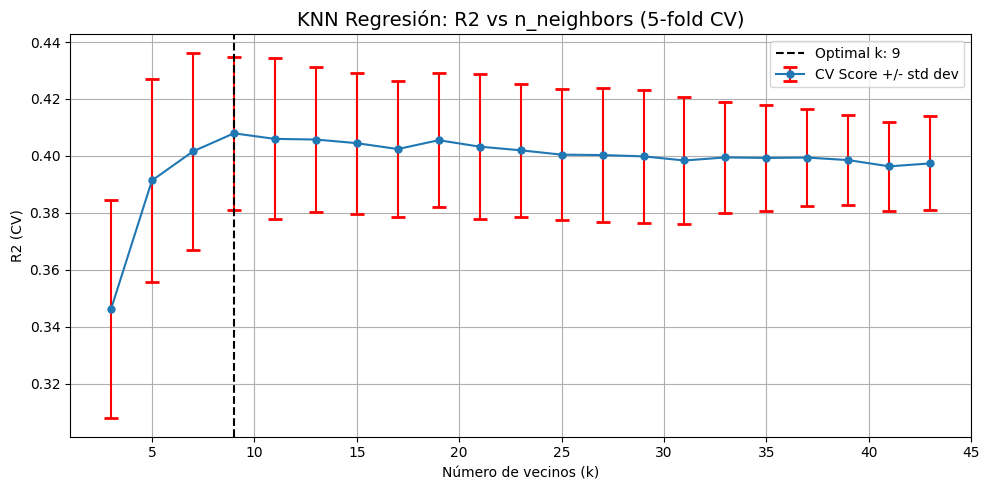

In [48]:
# Búsqueda del k óptimo (mismo enfoque que práctica 2.6)
k_values_reg = range(3, 45, 2)
mean_scores_knn_reg = []
std_scores_knn_reg = []

for k in k_values_reg:
    knn_r = KNeighborsRegressor(n_neighbors=k)
    mean, std = cross_validation_scaled(
        knn_r, X_reg_train, y_reg_train, n_folds=5, scoring='r2', stratified=False
    )
    mean_scores_knn_reg.append(mean)
    std_scores_knn_reg.append(std)

optimal_k_reg = list(k_values_reg)[np.argmax(mean_scores_knn_reg)]
best_r2_knn = max(mean_scores_knn_reg)
print(f'Optimal k para regresión: {optimal_k_reg} con R2 = {best_r2_knn:.4f}')

plt.figure(figsize=(10, 5))
plt.errorbar(list(k_values_reg), mean_scores_knn_reg, yerr=std_scores_knn_reg,
             fmt='-o', ecolor='r', capsize=5, capthick=2, markersize=5,
             label='CV Score +/- std dev')
plt.axvline(x=optimal_k_reg, linestyle='--', color='k',
            label=f'Optimal k: {optimal_k_reg}')
plt.title('KNN Regresión: R2 vs n_neighbors (5-fold CV)', fontsize=14)
plt.xlabel('Número de vecinos (k)')
plt.ylabel('R2 (CV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El k óptimo para regresión es 9, con un R² en CV de solo 0.41. Es mucho peor que los demás modelos, que están en el rango 0.74-0.78. La maldición de la dimensionalidad afecta a KNN Regressor exactamente igual que al clasificador: las distancias euclidianas pierden capacidad discriminante con 100 features, y aunque aumentar k ayuda a reducir la varianza, no soluciona el problema de fondo. KNN no es un modelo viable para este dataset, y lo incluimos más para completitud que por esperanza real de que compita.


### 5.2 Comparación de todos los modelos optimizados

Con los hiperparámetros de todos los modelos ya ajustados, pasamos a la comparación en cross-validation sobre el train. Esto nos da una estimación robusta del rendimiento relativo de cada modelo y nos ayuda a anticipar cuál será el mejor en el test final. Incluimos también Linear Regression (sin hiperparámetros que ajustar) como referencia base. Todos los modelos van envueltos en Pipeline para mantener el escalado limpio.

In [49]:
# Comparación de TODOS los modelos con sus hiperparámetros óptimos
modelos_reg_tuned = {
    'Linear Regression': make_pipe(LinearRegression()),
    'Ridge (tuned)': make_pipe(Ridge(**best_params_ridge, random_state=RANDOM_STATE)),
    'Lasso (tuned)': make_pipe(Lasso(**best_params_lasso, random_state=RANDOM_STATE, max_iter=5000)),
    'Elastic Net (tuned)': make_pipe(ElasticNet(**best_params_enet, random_state=RANDOM_STATE, max_iter=5000)),
    'Random Forest (tuned)': make_pipe(RandomForestRegressor(**best_params_rfr, random_state=RANDOM_STATE)),
    'KNN Reg. (k=' + str(optimal_k_reg) + ')': make_pipe(KNeighborsRegressor(n_neighbors=optimal_k_reg))
}

resultados_reg_cv = {}
print('Comparación de modelos optimizados (5-fold CV):\n')
print(f'{"Modelo":<28} {"R2 medio":>10} {"R2 std":>10}')
print('-' * 50)

for nombre, pipe in modelos_reg_tuned.items():
    scores_r2 = cross_val_score(pipe, X_reg_train, y_reg_train,
                                cv=cv_reg, scoring='r2', n_jobs=N_JOBS)
    resultados_reg_cv[nombre] = {'r2_mean': scores_r2.mean(), 'r2_std': scores_r2.std()}
    print(f'{nombre:<28} {scores_r2.mean():>10.4f} {scores_r2.std():>10.4f}')

Comparación de modelos optimizados (5-fold CV):

Modelo                         R2 medio     R2 std
--------------------------------------------------


Linear Regression                0.7426     0.0267


Ridge (tuned)                    0.7437     0.0278


Lasso (tuned)                    0.7458     0.0268


Elastic Net (tuned)              0.7456     0.0270


Random Forest (tuned)            0.7752     0.0307
KNN Reg. (k=9)                   0.4070     0.0298


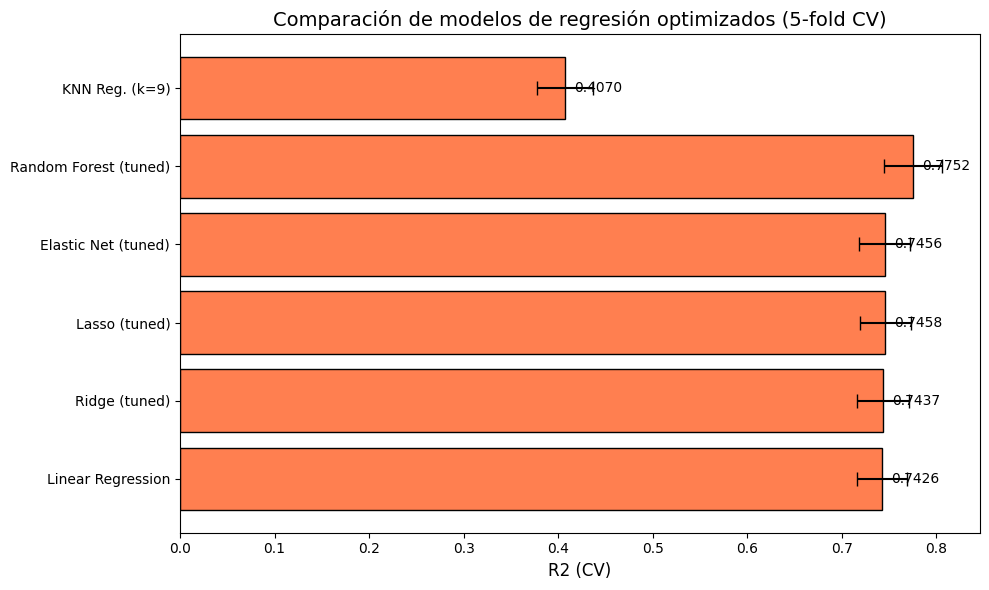

In [50]:
# Gráfico comparativo
nombres_reg = list(resultados_reg_cv.keys())
r2_means = [resultados_reg_cv[n]['r2_mean'] for n in nombres_reg]
r2_stds = [resultados_reg_cv[n]['r2_std'] for n in nombres_reg]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(nombres_reg, r2_means, xerr=r2_stds, capsize=5, color='coral', edgecolor='black')
ax.set_xlabel('R2 (CV)', fontsize=12)
ax.set_title('Comparación de modelos de regresión optimizados (5-fold CV)', fontsize=14)

for bar, mean in zip(bars, r2_means):
    ax.text(max(mean + 0.01, 0.02), bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

La CV coloca a Random Forest en primer lugar (R² = 0.7752), seguido por los modelos lineales con regularización: Lasso (0.7458), Elastic Net (0.7456) y Ridge (0.7437). Linear Regression sin regularización queda ligeramente por detrás (0.7426), y KNN se queda muy por debajo (0.4070).

Los tres modelos con regularización (Ridge, Lasso, Elastic Net) están prácticamente empatados entre sí, con diferencias por debajo de 0.003. Esto confirma lo que ya anticipamos: el tipo exacto de regularización importa poco, lo relevante es que haya alguna regularización en un dataset con 100 features. Linear Regression sin regularizar queda justo por debajo pero en un rango similar, lo que sugiere que el sobreajuste sin regularización es moderado en este caso (no dramático).

Random Forest mantiene una ventaja clara en CV, pero veremos si esta ventaja se sostiene en el test o si es parcialmente sobreajuste.


### 5.3 Evaluación final en el conjunto de test

In [51]:
# Métricas: R2, RMSE, MAE (temario 02-01, práctica 2.4)
modelos_reg_final = {
    'Linear Regression': LinearRegression(),
    'Ridge (tuned)': Ridge(**best_params_ridge, random_state=RANDOM_STATE),
    'Lasso (tuned)': Lasso(**best_params_lasso, random_state=RANDOM_STATE, max_iter=5000),
    'Elastic Net (tuned)': ElasticNet(**best_params_enet, random_state=RANDOM_STATE, max_iter=5000),
    'Random Forest (tuned)': RandomForestRegressor(**best_params_rfr, random_state=RANDOM_STATE),
    'KNN Reg. (tuned)': KNeighborsRegressor(n_neighbors=optimal_k_reg)
}

print('Evaluación en TEST (regresión):\n')
print(f'{"Modelo":<25} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 53)

mejor_r2_test = -np.inf
mejor_nombre_reg = ''

for nombre, modelo in modelos_reg_final.items():
    modelo.fit(X_reg_train_scaled, y_reg_train)
    y_pred_reg = modelo.predict(X_reg_test_scaled)
    r2 = r2_score(y_reg_test, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
    mae = mean_absolute_error(y_reg_test, y_pred_reg)
    print(f'{nombre:<25} {r2:>8.4f} {rmse:>8.4f} {mae:>8.4f}')
    if r2 > mejor_r2_test:
        mejor_r2_test = r2
        mejor_nombre_reg = nombre

print(f'\n=> Mejor modelo: {mejor_nombre_reg} (R2 = {mejor_r2_test:.4f})')

Evaluación en TEST (regresión):

Modelo                          R2     RMSE      MAE
-----------------------------------------------------
Linear Regression           0.7385   2.6609   1.5838
Ridge (tuned)               0.7393   2.6569   1.5797
Lasso (tuned)               0.7430   2.6379   1.5521
Elastic Net (tuned)         0.7424   2.6409   1.5561


Random Forest (tuned)       0.7248   2.7296   1.3984
KNN Reg. (tuned)            0.3272   4.2678   2.7576

=> Mejor modelo: Lasso (tuned) (R2 = 0.7430)


En el test el ranking se reordena de forma reveladora. Lasso pasa al primer puesto con R² = 0.7430, seguido muy de cerca por Elastic Net (0.7424), Ridge (0.7393) y Linear Regression (0.7385). Random Forest, que lideraba en CV, cae al quinto puesto (0.7248), y KNN cierra la lista con 0.3272.

El cambio tiene una explicación clara, Lasso actúa como selector de variables. La penalización L1 pone a cero los coeficientes de variables irrelevantes, lo que mejora la generalización. Random Forest en cambio, aunque es potente, tiende a aprovechar todas las variables disponibles, lo que aumenta el sobreajuste aunque se controle con los hiperparámetros del grid, obtiene mejor R² en CV pero peor en test.

Que Linear Regression (sin regularización) quede tan cerca de Lasso es esperable, ya que tras la agrupación de categorías raras y el one-hot ya no hay tantas variables completamente ruidosas como para que la selección de Lasso suponga un cambio drástico. Aun así, Lasso supera a Linear Regression en casi 0.005 de R², lo que indica que la penalización L1 está eliminando algo de ruido y variables no tan importantes.

Un R² de 0.74 significa que el modelo explica el 74% de la varianza de nota_media_2sem usando solo variables previas al 2º semestre, lo cual es un resultado sólido: las variables del 1er semestre contienen mucha información sobre cómo rendirá el estudiante en el siguiente.


### 5.4 Análisis de residuos

El R² y el RMSE resumen el rendimiento del modelo en un número, pero no nos dicen cómo falla está fallando. Un análisis de residuos domo se vió en el tema 02-03, permite diagnosticar si los errores se distribuyen uniformemente o si hay patrones, lo cual puede indicar problemas con las hipótesis del modelo entre los que se encuentra linealidad, homocedasticidad, normalidad de los residuos.

Calculamos los residuos del mejor modelo (Lasso) como la diferencia entre valor real y valor predicho en el test, y los visualizamos en tres gráficas: predichos vs reales (¿sigue la diagonal?), residuos vs predichos (¿hay patrón sistemático?) e histograma de residuos (¿se distribuyen normalmente?).

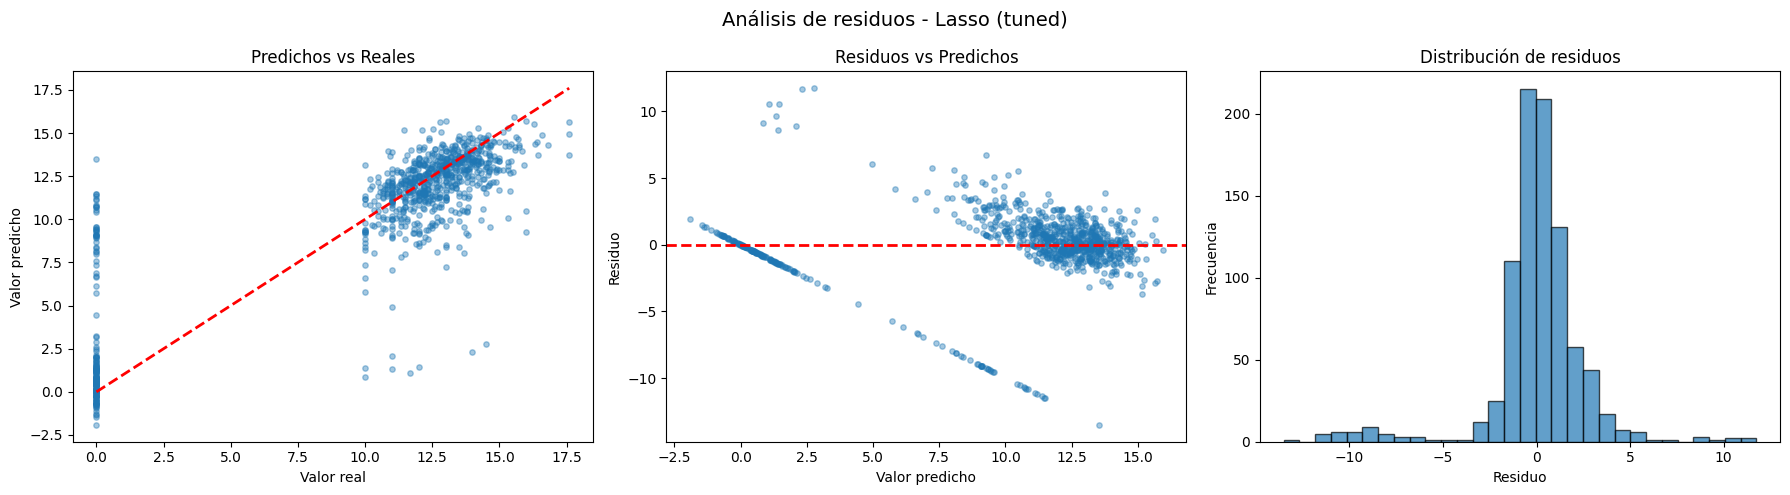

In [52]:
best_reg = modelos_reg_final[mejor_nombre_reg]
y_pred_reg_best = best_reg.predict(X_reg_test_scaled)
residuos = y_reg_test - y_pred_reg_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_reg_test, y_pred_reg_best, alpha=0.4, s=15)
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Predichos vs Reales')

axes[1].scatter(y_pred_reg_best, residuos, alpha=0.4, s=15)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Valor predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs Predichos')

axes[2].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residuo')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de residuos')

plt.suptitle(f'Análisis de residuos - {mejor_nombre_reg}', fontsize=14)
plt.tight_layout()
plt.show()

Los tres gráficos revelan detalles sobre el comportamiento del modelo.

**Predicho vs real.** La nube de puntos se concentra principalmente alrededor de la diagonal para notas entre 11 y 15, que es la zona con más datos. Para notas bajas, el modelo tiende a sobrestimar, ya que como se ha explicado antes, no hay notas entre 0 y 10 pero esto el modelo no lo sabe. Además, para notas altas (>15) tiende a subestimar un poco. 

**Residuos vs predicho.** La dispersión aumenta ligeramente con el valor predicho (heterocedasticidad leve), lo que viola una asunción del modelo lineal clásico pero no es grave para la predicción puntual. No se observa ningún patrón curvo fuerte, lo que sugiere que no hay grandes no linealidades sin capturar. (solo se observa una recta debido al caso comentado anteriormente)

**Histograma de residuos.** La distribución es aproximadamente normal centrada en cero, con algunos residuos muy negativos (valores donde la nota real fue mucho peor de lo predicho, por el motivo ya explicado). 

En conjunto, el modelo funciona razonablemente pero tiene dos limitaciones claras: no capta bien los extremos y no se da cuenta de que no hay valores en (0, 10).

Esto conecta con un apunte metodológico importante. La variable nota_media_2sem no es en realidad continua, es una mezcla entre una especie de categorica en 0 (alumnos que no aprueban nada) y un continua en [10, 20] (alumnos que aprueban al menos una asignatura). Aplicar una regresión lineal sobre un target así no es la opción teóricamente ideal, ya que el modelo "correcto" sería un enfoque de dos etapas o hurdle model, primero un clasificador 0 vs no-0 y después una regresión solo sobre el régimen de aprobados. Hemos optado por la regresión directa porque es lo que pide el enunciado y porque permite una comparación limpia entre modelos, pero conviene tener presente que parte del R² de 0.74 proviene de la facilidad de separar los dos regímenes y no tanto de predecir con precisión la nota dentro del régimen de aprobados.

### 5.5 Importancia de variables en regresión

Al igual que en clasificación, analizamos qué variables son más relevantes para la predicción. Aquí lo hacemos por dos vías complementarias: la importancia basada en impurezas del Random Forest Regressor (tema 02-07), y los coeficientes de Lasso (tema 02-04), que además nos dice qué variables descarta el modelo poniéndoles coeficiente cero.

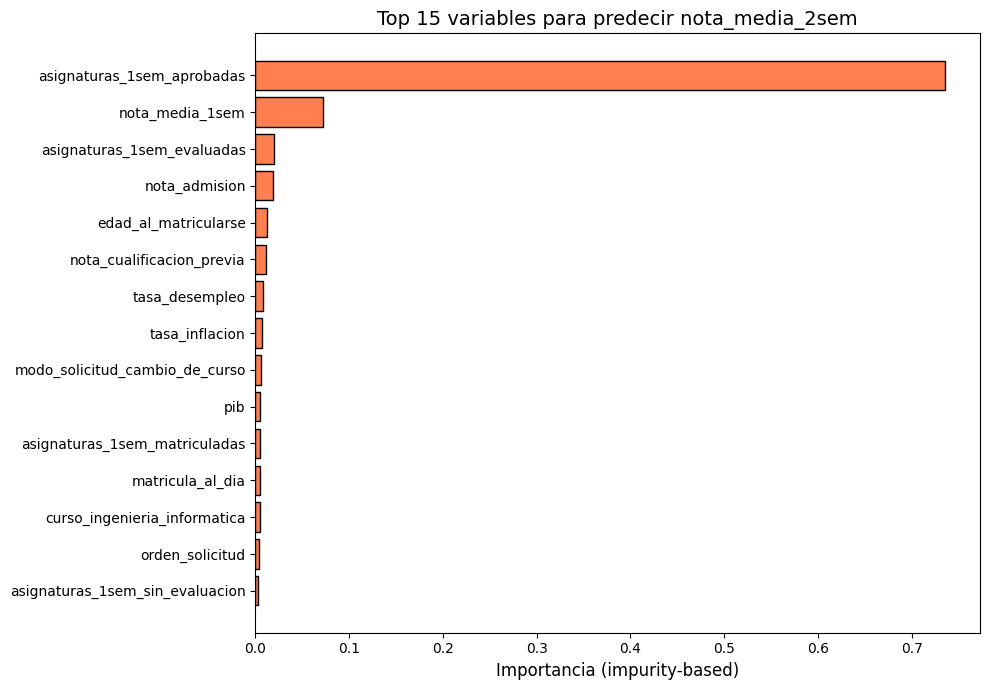


Top 10 variables:
                       Feature  Importance
    asignaturas_1sem_aprobadas    0.736038
               nota_media_1sem    0.071693
    asignaturas_1sem_evaluadas    0.020296
                 nota_admision    0.018937
          edad_al_matricularse    0.012303
     nota_cualificacion_previa    0.010919
                tasa_desempleo    0.008203
                tasa_inflacion    0.006943
modo_solicitud_cambio_de_curso    0.005378
                           pib    0.005155


In [53]:
# Variable Importance con Random Forest (tema 02-07)
rf_reg = RandomForestRegressor(**best_params_rfr, random_state=RANDOM_STATE)
rf_reg.fit(X_reg_train_scaled, y_reg_train)

df_imp_reg = pd.DataFrame({
    'Feature': feature_names_reg, 'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

top_n_reg = 15
df_top_reg = df_imp_reg.head(top_n_reg)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(top_n_reg), df_top_reg['Importance'].values, color='coral', edgecolor='black')
ax.set_yticks(range(top_n_reg))
ax.set_yticklabels(df_top_reg['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importancia (impurity-based)', fontsize=12)
ax.set_title(f'Top {top_n_reg} variables para predecir nota_media_2sem', fontsize=14)
plt.tight_layout()
plt.show()

print('\nTop 10 variables:')
print(df_imp_reg.head(10).to_string(index=False))

El ranking de importancias es muy claro: las variables del **primer semestre** dominan con mucha diferencia. asignaturas_1sem_aprobadas, nota_media_1sem y asignaturas_1sem_evaluadas aparecen en las primeras posiciones en ese orden de importancia, acaparando entre ellas una fracción importante de la importancia total, aunque la mayoría de importancia la aporta asignaturas_1sem_aprobadas por lo que es la más importante. Las variables de entrada (nota_admision, nota_cualificacion_previa, edad_al_matricularse) aparecen más abajo, con importancias mucho menores. Las variables administrativas y categóricas codificadas aportan valores casi despreciables.

En el siguiente código se puede ver que Lasso hace prácticamente lo mismo, le da mucha importancia a las variables del primer semestre, aunque en su caso, asignaturas_1sem_aprobadas y nota_media_1sem aunque siguen siendo las dos con mayor importancia, en Lasso tienen prácticamente el mismo coeficiente, por lo que se consideran igual de importantes.  

La lectura práctica es clara: la nota de admisión, la cualificación previa, las variables familiares y de contexto aportan muy poca capacidad predictiva sobre la nota del segundo semestre. Lo que realmente importa es cómo le ha ido al estudiante durante el primer semestre en esta universidad. Ese primer semestre funciona como una segunda evaluación mucho más informativa que la propia nota de acceso, porque mide ya el ajuste real del estudiante al entorno universitario concreto.

Esto tiene implicaciones pedagógicas interesantes: los sistemas de alerta temprana basados en datos de acceso tienen capacidad limitada, pero un sistema que siga el rendimiento del primer semestre puede anticipar bastante bien cómo irá el segundo, y por extensión cómo terminará el curso.


In [54]:
# Coeficientes de Lasso: seleccion de variables (L1 pone a 0 las irrelevantes, tema 02-04)
lasso_model = Lasso(**best_params_lasso, random_state=RANDOM_STATE, max_iter=5000)
lasso_model.fit(X_reg_train_scaled, y_reg_train)

coefs_lasso = pd.DataFrame({
    'Feature': feature_names_reg, 'Coeficiente': lasso_model.coef_
})
seleccionadas = coefs_lasso[coefs_lasso['Coeficiente'] != 0].sort_values('Coeficiente', key=abs, ascending=False)
descartadas = coefs_lasso[coefs_lasso['Coeficiente'] == 0]

print(f'Lasso selecciona {len(seleccionadas)} variables y descarta {len(descartadas)}.\n')
print('Variables seleccionadas (top 15):')
print(seleccionadas.head(15).to_string(index=False))

Lasso selecciona 83 variables y descarta 17.

Variables seleccionadas (top 15):
                            Feature  Coeficiente
         asignaturas_1sem_aprobadas     2.555304
                    nota_media_1sem     2.507288
      asignaturas_1sem_matriculadas    -0.832006
      asignaturas_1sem_convalidadas    -0.709072
curso_animacion_y_diseno_multimedia    -0.502487
         asignaturas_1sem_evaluadas     0.286064
                   matricula_al_dia     0.266336
       curso_ingenieria_informatica     0.242411
                     tasa_desempleo    -0.187342
         ocupacion_madre_estudiante    -0.185495
     modo_solicitud_cambio_de_curso     0.143960
             curso_gestion_nocturno     0.135792
                                pib     0.121187
     ocupacion_padre_otra_situacion    -0.116814
    modo_solicitud_mayor_de_23_anos    -0.113162


### 5.6 Comparación de distintas selecciones de variables

El enunciado sugiere, como exploración adicional, comparar distintas selecciones de variables para regresión. La hipótesis que queremos poner a prueba es la que surgió del análisis de importancia: ¿realmente hacen falta 100 variables o un modelo mucho más simple daría resultados equivalentes?

Comparamos tres conjuntos. El primero usa todas las 100 variables tras el preprocesado (la configuración por defecto). El segundo usa solo las variables que Lasso ha seleccionado con coeficiente distinto de cero (83 variables, Lasso descarta 17). El tercero es el más restrictivo: solo las variables numéricas originales y las binarias (21 variables en total), dejando fuera todas las categóricas de alta cardinalidad como ocupación de los padres o curso. Para que la comparación sea justa, usamos Ridge como modelo común (con su alpha ya optimizado) sobre los tres conjuntos.

In [55]:
# Comparacion de selecciones de variables para regresion
# Usamos Ridge como modelo base (buen rendimiento, rapido)

# 1. Todas las variables
ridge_all = Ridge(**best_params_ridge, random_state=RANDOM_STATE)
ridge_all.fit(X_reg_train_scaled, y_reg_train)
r2_all = r2_score(y_reg_test, ridge_all.predict(X_reg_test_scaled))

# 2. Solo variables seleccionadas por Lasso (coef != 0)
lasso_sel = Lasso(**best_params_lasso, random_state=RANDOM_STATE, max_iter=5000)
lasso_sel.fit(X_reg_train_scaled, y_reg_train)
selected_mask = lasso_sel.coef_ != 0
n_selected = selected_mask.sum()

ridge_lasso_sel = Ridge(**best_params_ridge, random_state=RANDOM_STATE)
ridge_lasso_sel.fit(X_reg_train_scaled[:, selected_mask], y_reg_train)
r2_lasso_sel = r2_score(y_reg_test, ridge_lasso_sel.predict(X_reg_test_scaled[:, selected_mask]))

# 3. Solo variables numericas basicas (sin categoricas de alta cardinalidad)
# Identificamos las columnas numericas originales en el dataset de regresion
cols_numericas_reg = ['orden_solicitud', 'nota_cualificacion_previa', 'nota_admision',
                      'edad_al_matricularse', 'asignaturas_1sem_convalidadas',
                      'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas',
                      'asignaturas_1sem_aprobadas', 'nota_media_1sem',
                      'asignaturas_1sem_sin_evaluacion', 'tasa_desempleo',
                      'tasa_inflacion', 'pib']
# Mas las binarias ya codificadas
cols_basicas = cols_numericas_reg + ['desplazado', 'necesidades_educativas_especiales',
               'deudor', 'matricula_al_dia', 'genero', 'becado', 'internacional',
               'asistencia_diurna_vespertina']
# Indices de estas columnas en feature_names_reg
basic_idx = [feature_names_reg.index(c) for c in cols_basicas if c in feature_names_reg]

scaler_basic = StandardScaler()
X_basic_train = scaler_basic.fit_transform(X_reg_train[:, basic_idx])
X_basic_test = scaler_basic.transform(X_reg_test[:, basic_idx])

ridge_basic = Ridge(**best_params_ridge, random_state=RANDOM_STATE)
ridge_basic.fit(X_basic_train, y_reg_train)
r2_basic = r2_score(y_reg_test, ridge_basic.predict(X_basic_test))

print('Comparación de selecciones de variables (Ridge):\n')
print(f'  Todas las variables ({X_reg_train_scaled.shape[1]}):    R2 = {r2_all:.4f}')
print(f'  Selección Lasso ({n_selected}):              R2 = {r2_lasso_sel:.4f}')
print(f'  Solo numéricas + binarias ({len(basic_idx)}): R2 = {r2_basic:.4f}')


Comparación de selecciones de variables (Ridge):

  Todas las variables (100):    R2 = 0.7393
  Selección Lasso (83):              R2 = 0.7395
  Solo numéricas + binarias (21): R2 = 0.7320


Los números confirman la hipótesis. Con las 100 variables el Ridge obtiene R² = 0.7393. Con las 83 de la selección de Lasso sube muy ligeramente a 0.7395 (mejora marginal por eliminar un poco de ruido). Con solo las 21 variables numéricas y binarias cae a 0.7320, una pérdida de apenas 0.007. Es una pérdida casi imperceptible para una reducción del 80% en el número de variables.

La conclusión es clara y consistente con la importancia de variables, la mayoría del poder predictivo está concentrada en un puñado de variables, sobre todo las del primer semestre. Las variables categóricas de alta cardinalidad (ocupación y cualificación de los padres, nacionalidad, curso) aportan información marginal. Si el objetivo fuese construir un sistema práctico con el mínimo de features posibles, las 21 numéricas y binarias serían una excelente elección, consiguiendo un modelo simple, interpretable, rápido, y apenas un 1% peor que el complejo.


Conviene subrayar lo que dicen estos resultados en conjunto. Primero, Lasso hace su trabajo: selecciona 83 de 100 variables, descarta 17 y mejora muy ligeramente al modelo completo. No es una reducción espectacular porque, como hemos visto, tras el preprocesado ya no quedaban tantas features totalmente inútiles (la agrupación de categorías raras había eliminado las peores). Pero aún así, la selección identifica un poco de ruido que había quedado.

Segundo, el resultado del modelo con 21 variables es probablemente el más importante, ya que permite ver que casi todo el poder predictivo reside en el rendimiento del primer semestre y unas pocas variables socioeconómicas. Las decenas de dummies categóricas contribuyen muy poco en su conjunto.

Tercero, desde un punto de vista práctico este resultado apoya una estrategia de modelado muy simple y robusta. Construir un sistema de predicción con 21 variables bien definidas es mucho más mantenible y menos propenso a errores en producción que mantener 100 features que, en su mayoría, apenas aportan información.


Una última observación sobre Elastic Net. Con alpha=0.01 y l1_ratio=0.8 obtiene un R² en test de 0.7424, prácticamente idéntico al de Lasso (0.7430). Que el parámetro l1_ratio óptimo esté tan cerca de 1 (Lasso puro) confirma que en este problema la penalización L1 (selección de variables) es más útil que la L2 (contracción uniforme). En la práctica, Lasso y Elastic Net son intercambiables aquí, y la elección entre uno y otro es casi cosmética.


### 5.7 Intervalos de confianza bootstrap para el modelo de regresión

Al igual que en la tarea de clasificación, aplicamos bootstrap al mejor modelo de regresión para estimar la variabilidad de las métricas. Remuestreamos 1000 veces el conjunto de test y calculamos R², RMSE y MAE en cada muestra.

Intervalos bootstrap (95%, 1000 muestras) - Lasso (tuned):
  R2:   puntual=0.7430, IC 95% = [0.6905, 0.7897]
  RMSE: puntual=2.6379, IC 95% = [2.3773, 2.8928]
  MAE:  puntual=1.5521, IC 95% = [1.4174, 1.6974]


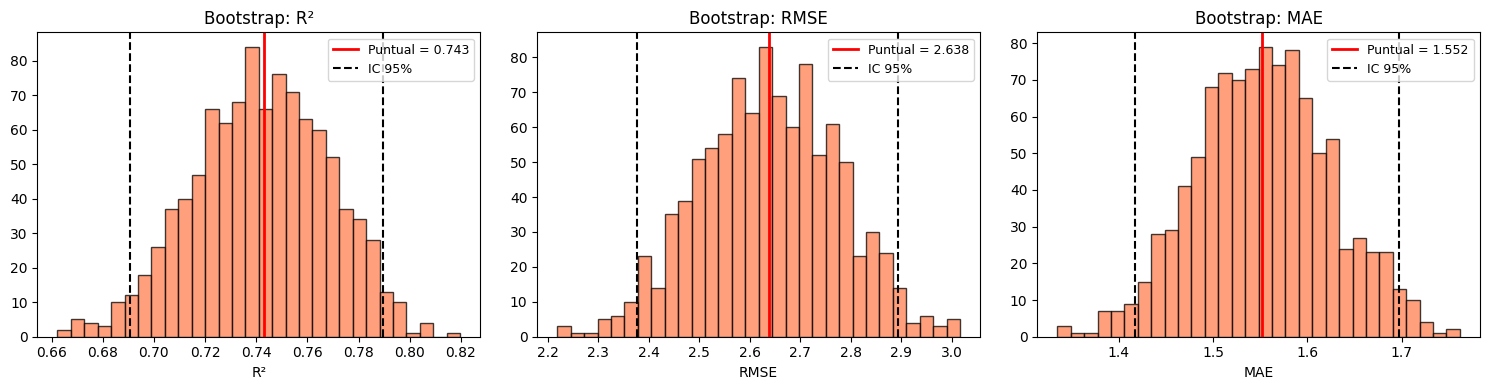

In [56]:
# Bootstrap sobre el mejor modelo de regresion
y_pred_reg_boot = best_reg.predict(X_reg_test_scaled)

def rmse_fn(y, p):
    return np.sqrt(mean_squared_error(y, p))

r2_boot = bootstrap_ci(y_reg_test, y_pred_reg_boot, r2_score)
rmse_boot = bootstrap_ci(y_reg_test, y_pred_reg_boot, rmse_fn)
mae_boot = bootstrap_ci(y_reg_test, y_pred_reg_boot, mean_absolute_error)

print(f'Intervalos bootstrap (95%, 1000 muestras) - {mejor_nombre_reg}:')
print(f'  R2:   puntual={r2_score(y_reg_test, y_pred_reg_boot):.4f}, '
      f'IC 95% = [{np.percentile(r2_boot, 2.5):.4f}, {np.percentile(r2_boot, 97.5):.4f}]')
print(f'  RMSE: puntual={rmse_fn(y_reg_test, y_pred_reg_boot):.4f}, '
      f'IC 95% = [{np.percentile(rmse_boot, 2.5):.4f}, {np.percentile(rmse_boot, 97.5):.4f}]')
print(f'  MAE:  puntual={mean_absolute_error(y_reg_test, y_pred_reg_boot):.4f}, '
      f'IC 95% = [{np.percentile(mae_boot, 2.5):.4f}, {np.percentile(mae_boot, 97.5):.4f}]')

# Grafico
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, valores, nombre, puntual in zip(
    axes, [r2_boot, rmse_boot, mae_boot], ['R²', 'RMSE', 'MAE'],
    [r2_score(y_reg_test, y_pred_reg_boot), rmse_fn(y_reg_test, y_pred_reg_boot),
     mean_absolute_error(y_reg_test, y_pred_reg_boot)]
):
    ax.hist(valores, bins=30, color='coral', edgecolor='black', alpha=0.75)
    ax.axvline(puntual, color='red', linewidth=2, label=f'Puntual = {puntual:.3f}')
    ax.axvline(np.percentile(valores, 2.5), color='black', linestyle='--', label='IC 95%')
    ax.axvline(np.percentile(valores, 97.5), color='black', linestyle='--')
    ax.set_title(f'Bootstrap: {nombre}')
    ax.set_xlabel(nombre)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

El intervalo de confianza del 95% para R² del Lasso va de 0.6905 a 0.7897, una anchura de unos 0.10 puntos. Las diferencias entre los modelos lineales en el test son minúsculas comparadas con esto (Lasso saca solo 0.0045 a Linear Regression y 0.0006 a Elastic Net), así que estadísticamente son indistinguibles. Random Forest, a 0.018 de Lasso, también cae dentro del intervalo. El único modelo que el bootstrap separa con claridad es KNN, cuyo R² de 0.3272 queda muy por debajo del límite inferior, confirmando que su mal rendimiento no es ruido sino una limitación del método.


## 6. Tarea 3: Aprendizaje no supervisado

Cerramos con una tarea no supervisada: descubrir estructura en los estudiantes sin usar la variable objetivo. El enunciado plantea PCA + clustering como pipeline estándar.

**Objetivo.** Identificar subgrupos naturales de estudiantes que luego podamos caracterizar. Si los clusters coinciden parcialmente con los estados finales (Graduado/Matriculado/Abandono) será una validación indirecta de que la estructura captada es real.

**Protocolo.**
1. Selección razonada de variables (las más discriminativas según EDA, sin leakage ni redundancias obvias).
2. Escalado con StandardScaler (PCA es sensible a escala).
3. PCA para visualización y para ver cuánta varianza se concentra en pocas componentes.
4. K-Means (tema 04-02) con elección de K por codo y silueta.
5. Clustering jerárquico para comparar.
6. Caracterización de cada cluster y cruce con la variable objetivo.

**Nota metodológica.** Tanto PCA como K-Means se entrenan sobre todo el dataset (train + test) porque el objetivo es descriptivo: no vamos a predecir nada nuevo con ellos. Si quisiéramos predecir en producción habría que ajustarlos solo en train.

### 6.1 Selección razonada de variables

Para clustering no queremos usar todas las variables one-hot (más de 100): muchas son redundantes o poco informativas, y con esa dimensionalidad el clustering se diluye (la maldición de la dimensionalidad hace que todos los puntos parezcan igualmente lejanos).

Seleccionamos un conjunto reducido de variables numéricas y binarias con alta capacidad descriptiva, basadas en el EDA:

- **Rendimiento 1sem**: asignaturas_1sem_matriculadas, asignaturas_1sem_evaluadas, asignaturas_1sem_aprobadas, asignaturas_1sem_convalidadas, asignaturas_1sem_sin_evaluacion, nota_media_1sem.
- **Rendimiento 2sem**: las mismas seis variables del segundo semestre.
- **Entrada**: nota_admision, nota_cualificacion_previa, edad_al_matricularse (bimodalidad joven/adulto clara).
- **Administrativas**: matricula_al_dia, becado, deudor, desplazado, género (separaciones fuertes en EDA).

Son 20 variables en total. Se excluyen las categóricas de que toman muchos valores (ocupaciones, nacionalidad, cualificaciones de los padres, curso, modo de solicitud, estado civil) porque al codificarlas en one-hot añadirían muchas dimensiones con poco contenido para clustering. También se excluyen las macroeconómicas (desempleo, inflación, PIB) porque solo separan años, no estudiantes individuales.

A diferencia de las tareas supervisadas, aquí usamos el dataset completo: el objetivo es descriptivo, no predictivo. Guardamos la variable objetivo aparte únicamente para comparar los clusters obtenidos con ella al final, pero NO entra en ningún cálculo del pipeline.


In [57]:
# Seleccionamos el subconjunto razonado de variables
cols_unsup = [
    # Rendimiento academico 1er semestre
    'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas',
    'asignaturas_1sem_aprobadas', 'asignaturas_1sem_convalidadas',
    'asignaturas_1sem_sin_evaluacion', 'nota_media_1sem',
    # Rendimiento academico 2do semestre
    'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas',
    'asignaturas_2sem_aprobadas', 'asignaturas_2sem_convalidadas',
    'asignaturas_2sem_sin_evaluacion', 'nota_media_2sem',
    # Acceso y perfil inicial
    'nota_admision', 'nota_cualificacion_previa', 'edad_al_matricularse',
    # Socioeconomicas binarias (ya en 0/1 en df_features tras el preprocesado binario)
]

# Tomamos las numericas del df original y anadimos las binarias ya codificadas
df_unsup = df[cols_unsup].copy()

# Anadimos las binarias convertidas a 0/1
for col in ['matricula_al_dia', 'becado', 'deudor', 'desplazado', 'genero']:
    if df[col].dtype == 'object':
        mapping = vars_binarias_map[col]
        df_unsup[col] = df[col].map(mapping)
    else:
        df_unsup[col] = df[col]

# Guardamos la variable objetivo aparte (solo la usaremos al final para comparar)
y_real = df['objetivo'].values

print(f'Variables seleccionadas: {df_unsup.shape[1]}')
print(f'Muestras: {df_unsup.shape[0]}')
print(f'\nListado:')
for c in df_unsup.columns:
    print(f'  - {c}')

Variables seleccionadas: 20
Muestras: 4424

Listado:
  - asignaturas_1sem_matriculadas
  - asignaturas_1sem_evaluadas
  - asignaturas_1sem_aprobadas
  - asignaturas_1sem_convalidadas
  - asignaturas_1sem_sin_evaluacion
  - nota_media_1sem
  - asignaturas_2sem_matriculadas
  - asignaturas_2sem_evaluadas
  - asignaturas_2sem_aprobadas
  - asignaturas_2sem_convalidadas
  - asignaturas_2sem_sin_evaluacion
  - nota_media_2sem
  - nota_admision
  - nota_cualificacion_previa
  - edad_al_matricularse
  - matricula_al_dia
  - becado
  - deudor
  - desplazado
  - genero


### 6.2 Escalado de las variables

En aprendizaje no supervisado el escalado es imprescindible.

PCA busca las direcciones de máxima varianza en los datos. Si una variable tiene una escala mucho mayor que las demás (por ejemplo, nota_admision va de 95 a 190, mientras que becado vale 0 o 1), dominaría por completo las primeras componentes principales. No porque contenga más información, sino simplemente porque su varianza absoluta es mayor. Para que PCA capture direcciones de variación significativas y no artefactos de escala, hay que poner todas las variables en la misma escala: media 0, desviación típica 1. Eso hace el z-score (StandardScaler).

K-Means y el clustering jerárquico usan distancias euclidianas. Si no escalamos, la distancia entre dos estudiantes estaría dominada por las variables con valores grandes: dos estudiantes con notas de admisión distintas parecerían muy lejanos aunque coincidieran en todo lo demás, mientras que dos con diferente valor de becado parecerían casi idénticos porque la diferencia es solo 0 o 1. Escalar hace que todas las variables contribuyan de forma equivalente a la distancia total.

In [58]:
# Escalado con StandardScaler (z-score)
scaler_unsup = StandardScaler()
X_unsup = scaler_unsup.fit_transform(df_unsup.values)

print(f'Forma de los datos escalados: {X_unsup.shape}')
print(f'Media de cada variable (primeras 5): {X_unsup.mean(axis=0)[:5].round(4)}')
print(f'Std de cada variable (primeras 5):   {X_unsup.std(axis=0)[:5].round(4)}')

Forma de los datos escalados: (4424, 20)
Media de cada variable (primeras 5): [0. 0. 0. 0. 0.]
Std de cada variable (primeras 5):   [1. 1. 1. 1. 1.]


### 6.3 Análisis de Componentes Principales (PCA)

PCA (tema 04-01) es una técnica lineal de reducción de dimensionalidad. La idea es sencilla: busca la dirección en la que los datos varían más, llamada por ejemplo PC1, después, busca la dirección ortogonal (perpendicular) a PC1 en la que los datos varían más, está será PC2, y así sucesivamente. Cada componente principal es una combinación lineal de las variables originales, y el conjunto de componentes forma un nuevo sistema de coordenadas donde las primeras direcciones concentran casi toda la varianza.

Se usa PCA aquí con tres objetivos. Primero, reducir la dimensionalidad para poder visualizar los datos en 2D o 3D, algo impracticable con las 20 variables originales. Segundo, entender la estructura de los datos mirando los loadings, qué variables cargan más en cada componente, qué "significa" cada dirección de variación. Tercero, para preparar una representación compacta sobre la que ver cómo se distribuyen los clusters que encontremos después.

Conviene tener presente que PCA no conoce la variable objetivo. Las direcciones que encuentra son las de máxima varianza del conjunto de features, no las que mejor separan las clases. Que esas direcciones acaben separando a los estudiantes por su situación académica final es precisamente lo que se quiere observar.

In [59]:
# Ajustamos PCA sobre los datos escalados
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_unsup)

# Varianza explicada por cada componente
pve = pca.explained_variance_ratio_
pve_cum = np.cumsum(pve)

print(f'Número total de componentes: {len(pve)}')
print(f'\nVarianza explicada por componente (primeras 10):')
for i, (p, pc) in enumerate(zip(pve[:10], pve_cum[:10])):
    print(f'  PC{i+1}: {p:.4f} ({p*100:.1f}%) | Acumulada: {pc*100:.1f}%')

Número total de componentes: 20

Varianza explicada por componente (primeras 10):
  PC1: 0.3116 (31.2%) | Acumulada: 31.2%
  PC2: 0.1349 (13.5%) | Acumulada: 44.7%
  PC3: 0.0794 (7.9%) | Acumulada: 52.6%
  PC4: 0.0771 (7.7%) | Acumulada: 60.3%
  PC5: 0.0618 (6.2%) | Acumulada: 66.5%
  PC6: 0.0576 (5.8%) | Acumulada: 72.2%
  PC7: 0.0491 (4.9%) | Acumulada: 77.1%
  PC8: 0.0417 (4.2%) | Acumulada: 81.3%
  PC9: 0.0337 (3.4%) | Acumulada: 84.7%
  PC10: 0.0307 (3.1%) | Acumulada: 87.8%


Los números del PCA permiten ver como se distribuye la información en las 20 variables seleccionadas.

La primera componente acapara el 31.2% de la varianza total y la segunda un 13.5%. Las dos juntas suman un 44.7%: no llegando a resumir la mayoría de la variabilidad en dos dimensiones, pero sí capturando la parte más estructurada del dataset. Es coherente con lo que ya intuíamos del EDA, muchas variables de rendimiento están muy correlacionadas entre sí y se pueden resumir en un solo eje principal, mientras que otros ejes (edad, variables administrativas) aportan dimensiones secundarias.

Para superar el 80% de varianza explicada hacen falta 8 componentes, y para llegar al 90% hacen falta más de 10. Es decir, la varianza no está concentrada en 2-3 ejes sino repartida entre un número intermedio de direcciones, lo que tiene sentido con 20 variables heterogéneas (rendimiento + acceso + administrativas).

Esto justifica usar PCA tanto para visualizar (en 2D captamos ≈45% de la señal, suficiente para apreciar la estructura gruesa) como para entender qué combinaciones de variables explican la variabilidad del dataset.


Para decidir cuántas componentes usar miramos dos gráficos complementarios. El **scree plot** muestra la varianza explicada por cada componente: la buscamos un "codo", es decir, un punto a partir del cual añadir más componentes aporta muy poca varianza extra. La **varianza acumulada** nos dice qué fracción del total hemos capturado hasta cada componente, y nos permite poner umbrales concretos (por ejemplo, ¿cuántas componentes necesito para capturar el 80% o el 90% de la varianza?).

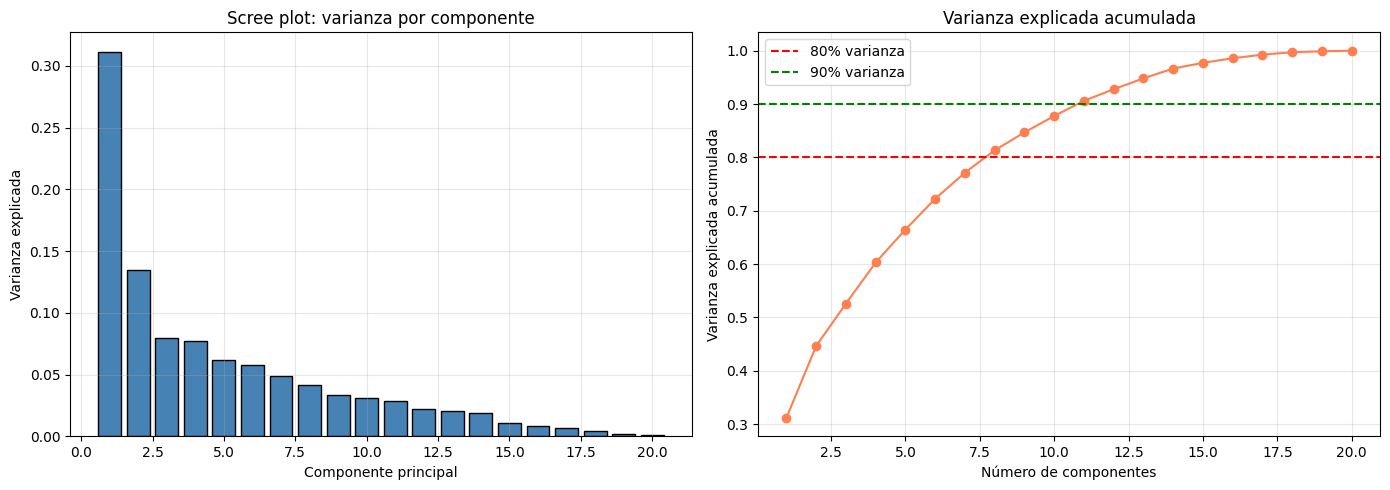


Componentes necesarias para explicar 80% de varianza: 8
Componentes necesarias para explicar 90% de varianza: 11


In [60]:
# Scree plot: varianza explicada individual y acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual
axes[0].bar(range(1, len(pve)+1), pve, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Scree plot: varianza por componente')
axes[0].grid(True, alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(pve)+1), pve_cum, 'o-', color='coral', markersize=6)
axes[1].axhline(y=0.80, color='r', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].set_title('Varianza explicada acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Numero de componentes para 80% y 90%
n_80 = np.argmax(pve_cum >= 0.80) + 1
n_90 = np.argmax(pve_cum >= 0.90) + 1
print(f'\nComponentes necesarias para explicar 80% de varianza: {n_80}')
print(f'Componentes necesarias para explicar 90% de varianza: {n_90}')

El scree plot visualiza lo que acabamos de comentar. La caída entre PC1 y PC2 es notable (de 31.2% a 13.5%, menos de la mitad), y entre PC2 y PC3 vuelve a haber una caída apreciable. A partir de PC3 el descenso se suaviza y cada componente aporta menos, hasta el punto de que las últimas apenas contribuyen.

El "codo" no es muy marcado, pero la forma general es consistente con la idea de que hay dos componentes principales interpretables y luego ruido residual repartido entre muchas direcciones. Para esta tarea nos quedamos con dos componentes, lo que nos permite visualizar en 2D con razonable fidelidad.

**Visualización en 2D.** Aunque con solo dos componentes no capturemos toda la varianza del dataset, la proyección sobre PC1 y PC2 es muy útil para poder observar como se distribuyen los datos. Si los estudiantes forman grupos visualmente diferenciados, ya tenemos una pista de la estructura antes incluso de aplicar K-Means.

Coloreamos los puntos según la variable objetivo real, pero solo a efectos de visualización: no entra en ningún cálculo. Es un ejercicio diagnóstico, en el que si vemos que los abandonos, matriculados y graduados ocupan regiones diferenciadas en el plano PC1-PC2, significa que la estructura interna de los datos se alinea con las clases del target. Si se mezclan, significa que la estructura interna es distinta de la que marca el target, lo cual es una información valiosa por sí misma.

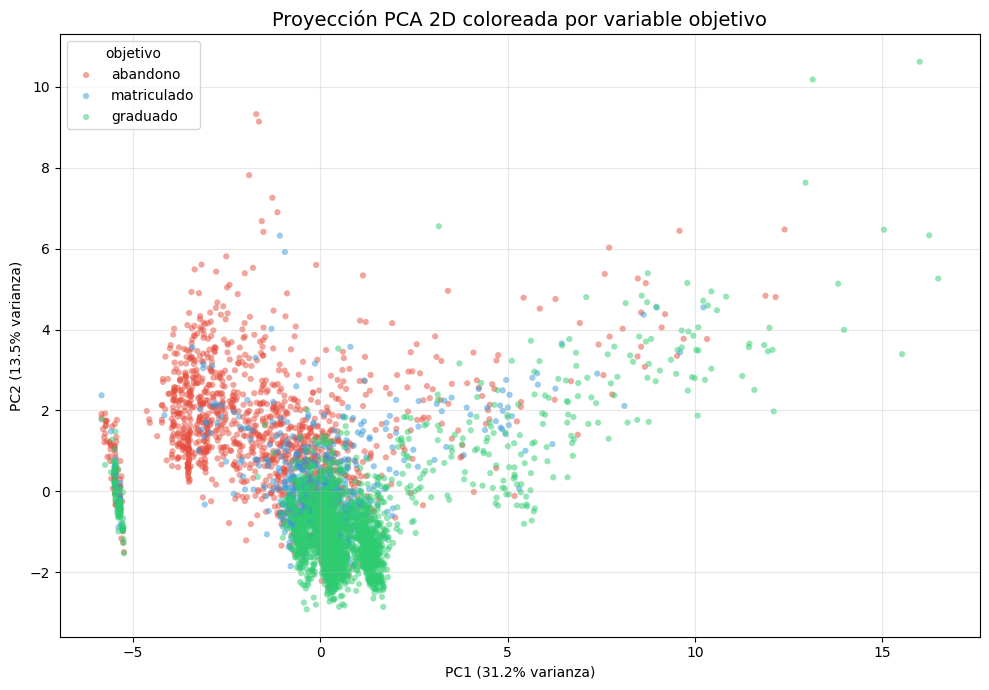

Varianza capturada por las 2 primeras componentes: 44.7%


In [61]:
# Proyectamos los datos sobre las 2 primeras componentes
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_unsup)

# Visualizacion coloreada por la variable objetivo (solo para ver estructura)
fig, ax = plt.subplots(figsize=(10, 7))
colores = {'abandono': '#e74c3c', 'matriculado': '#3498db', 'graduado': '#2ecc71'}
for clase in ['abandono', 'matriculado', 'graduado']:
    mask = y_real == clase
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=colores[clase], label=clase, alpha=0.5, s=20, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Proyección PCA 2D coloreada por variable objetivo', fontsize=14)
ax.legend(title='objetivo')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Varianza capturada por las 2 primeras componentes: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%')

La proyección sobre PC1 y PC2 revela una estructura clara, incluso sin conocer de antemano la variable objetivo.

Los puntos de **abandono** (rojos) se concentran masivamente en la zona izquierda un poco inferior del plano, donde PC1 toma valores bajos. Forman una nube bastante compacta, bien delimitada. Los **graduados** (verdes) ocupan principalmente la mitad baja más a la derecha que abandono, desde el centro hasta valores altos de PC1. Los **matriculados** (azules) se distribuyen sobre todo por la franja central, solapándose con ambos grupos pero sin formar una región propia bien definida.

Este patrón confirma de forma visual lo que los modelos supervisados nos venían diciendo, la dirección PC1 (que interpretaremos como "rendimiento académico global" al mirar los loadings) separa con bastante claridad a los abandonos del resto, pero la frontera entre matriculados y graduados es borrosa, con un solapamiento importante. Esto explica por qué los modelos de clasificación tienen un techo de F1 alrededor del 0.76 y por qué la clase matriculado es la más difícil: no es un problema del algoritmo, es que esa clase realmente no ocupa una región propia en el espacio de features.

También aporta un argumento importante a favor del resto del análisis, ya que si la estructura natural de los datos ya se alinea en gran parte con el target, tiene sentido que el clustering descubra grupos relacionados con las clases.

Los componentes principales son combinaciones lineales de las variables originales. Los coeficientes de esta combinación se llaman **loadings**, y su valor nos dice cuánto contribuye cada variable a cada componente. Un loading alto en valor absoluto significa que la variable tiene un papel importante en esa componente, el signo indica si contribuye positiva o negativamente.

Analizar los loadings de PC1 y PC2 nos permite responder a unas preguntas clave, como ¿qué representan las dos primeras componentes? ¿Qué patrón han capturado?

Loadings ordenados por |PC1|:

                                   PC1    PC2
asignaturas_1sem_aprobadas       0.366 -0.127
asignaturas_1sem_matriculadas    0.360  0.151
asignaturas_2sem_matriculadas    0.349  0.098
asignaturas_2sem_aprobadas       0.344 -0.198
asignaturas_1sem_evaluadas       0.298  0.162
asignaturas_1sem_convalidadas    0.294  0.267
asignaturas_2sem_convalidadas    0.294  0.262
asignaturas_2sem_evaluadas       0.292  0.075
nota_media_2sem                  0.259 -0.336
nota_media_1sem                  0.258 -0.313
matricula_al_dia                 0.082 -0.295
genero                          -0.065  0.206
asignaturas_1sem_sin_evaluacion  0.044  0.216
becado                           0.032 -0.254
deudor                          -0.032  0.213
asignaturas_2sem_sin_evaluacion  0.020  0.215
edad_al_matricularse             0.018  0.344
nota_admision                    0.011 -0.112
desplazado                      -0.008 -0.217
nota_cualificacion_previa        0.002 -0.141


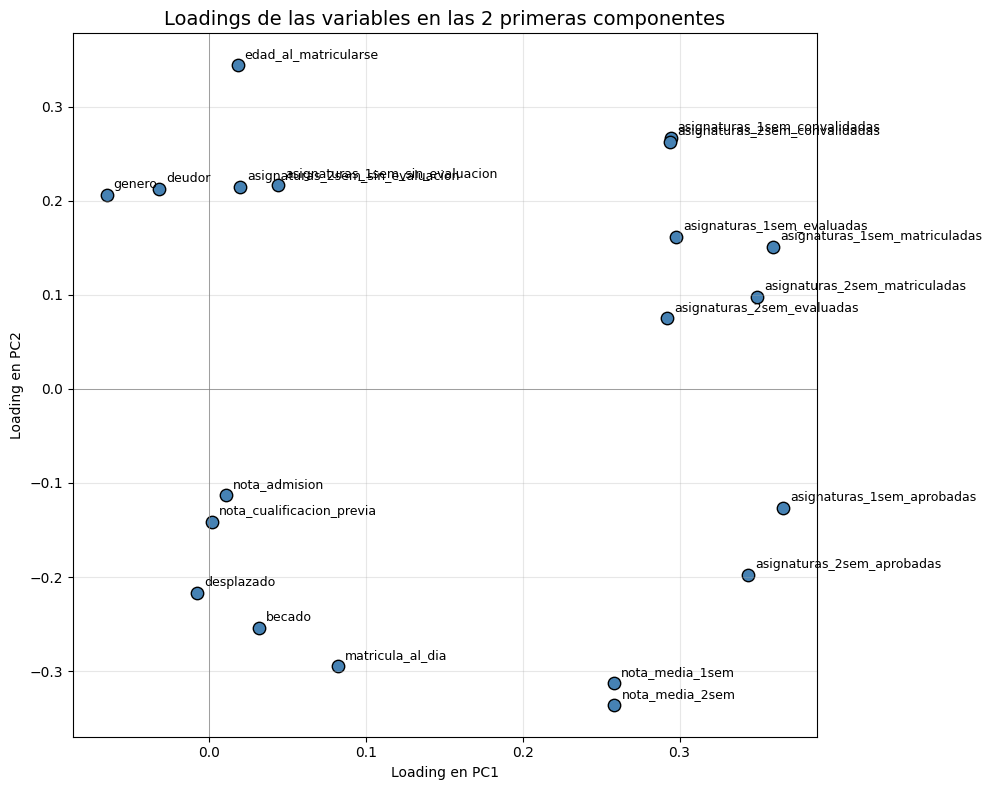

In [62]:
# Loadings de las 2 primeras componentes
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=df_unsup.columns
)

# Ordenamos por magnitud en PC1
print('Loadings ordenados por |PC1|:\n')
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).round(3))

# Grafico de loadings
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(loadings['PC1'], loadings['PC2'], s=80, color='steelblue', edgecolors='black')
for i, txt in enumerate(loadings.index):
    ax.annotate(txt, (loadings['PC1'].iloc[i], loadings['PC2'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Loading en PC1')
ax.set_ylabel('Loading en PC2')
ax.set_title('Loadings de las variables en las 2 primeras componentes', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Los loadings permiten interpretar qué significan las dos primeras componentes, es decir, qué combinación de variables originales representa cada eje.

**Componente 1 (PC1)** está dominada por las variables de rendimiento académico. Todas las variables de rendimiento (aprobadas 1sem, aprobadas 2sem, notas medias) tienen loadings positivos fuertes y similares en magnitud. Esto significa que PC1 es básicamente un eje de éxito académico, los estudiantes con valores altos en PC1 son los que aprueban mucho y sacan buenas notas, los que tienen valores bajos son los que suspenden o no se presentan. Es un eje muy interpretable y que coincide con el patrón principal del dataset.

**Componente 2 (PC2)** separa por otro criterio. Los loadings más fuertes (en valor absoluto) aparecen en edad_al_matricularse (0.344, positivo), nota_media_2sem (-0.336) y nota_media_1sem (-0.313), seguidos de matricula_al_dia (-0.295) y las administrativas becado (-0.254) y deudor (+0.213). Edad va con signo opuesto a notas y a beca, lo que sugiere que PC2 captura un eje de perfil vital y socioeconómico, donde pone a jóvenes con buen rendimiento, beca y pagos al día en un extremo, frente a adultos con peor rendimiento, sin beca y con impagos en el otro.

La interpretación conjunta de las dos componentes da un mapa bidimensional muy informativo: PC1 es el eje del rendimiento, PC2 el del perfil de estudiante. Los abandonos están en la zona con PC1 baja y PC2 alta (adultos con mal rendimiento y dificultades económicas), los graduados en la zona opuesta.

### 6.4 Clustering con K-Means

En K-Means (tema 04-02), la idea es dividir los datos en K grupos (clusters) de modo que los puntos dentro de cada cluster sean lo más parecidos posible entre sí y lo más distintos posible de los puntos de otros clusters.

El algoritmo empieza eligiendo K centroides iniciales al azar. En cada iteración asigna cada punto al centroide más cercano (según distancia euclidiana), forma los K clusters resultantes, y recalcula cada centroide como la media de los puntos que lo componen. Repite hasta que las asignaciones no cambian.

La parte dificil en K-Means es cómo elegir K. No hay una respuesta única, pero vamos a usar dos criterios complementarios. El método del codo, que consiste en graficar la inercia para distintos valores de K y buscar el punto donde deja de caer notablemente, es decir antes del codo, añadir clusters mejora mucho, después poco. El método de la silueta mide la calidad del clustering con una métrica entre -1 y 1 que combina cuánto se parece cada punto a su propio cluster y cuánto se diferencia del siguiente. Valores cercanos a 1 indican clusters bien definidos, cercanos a 0, que están solapados negativos, puntos mal asignados. Usamos ambos criterios y vemos si coinciden.

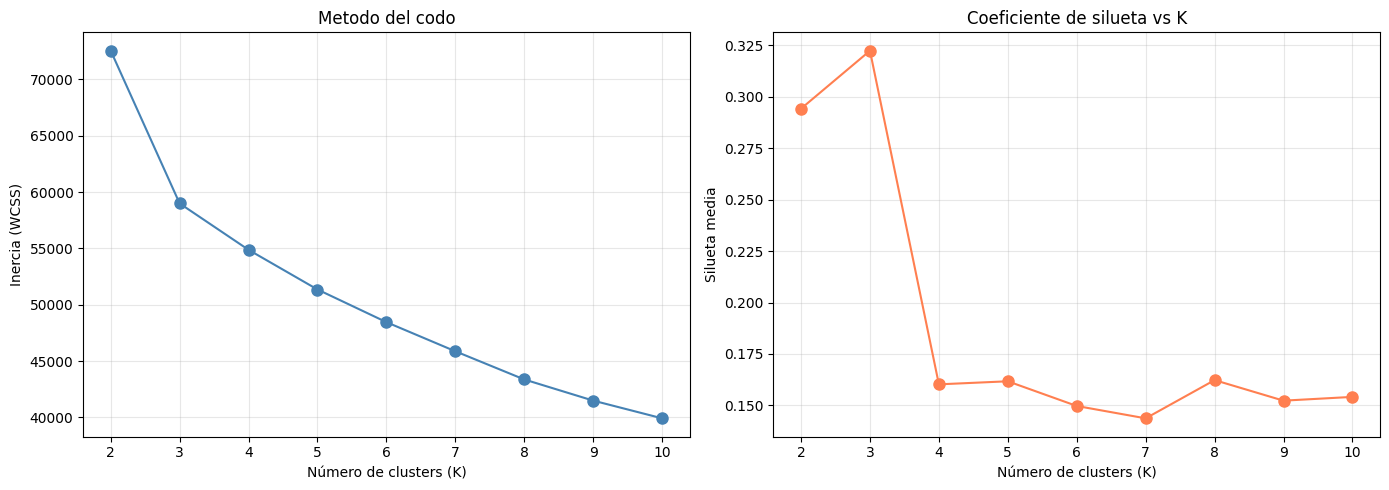

K | Inercia   | Silueta
--------------------------------
2 |  72547.8 | 0.2942
3 |  58993.1 | 0.3223
4 |  54874.4 | 0.1602
5 |  51355.2 | 0.1617
6 |  48456.8 | 0.1497
7 |  45872.5 | 0.1437
8 |  43371.1 | 0.1623
9 |  41494.1 | 0.1523
10 |  39920.7 | 0.1541


In [63]:
# Metodo del codo y silueta para elegir K
k_range = range(2, 11)
inercias = []
siluetas = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_unsup)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_unsup, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metodo del codo
axes[0].plot(list(k_range), inercias, 'o-', color='steelblue', markersize=8)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Metodo del codo')
axes[0].grid(True, alpha=0.3)

# Silueta
axes[1].plot(list(k_range), siluetas, 'o-', color='coral', markersize=8)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silueta media')
axes[1].set_title('Coeficiente de silueta vs K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla
print('K | Inercia   | Silueta')
print('-' * 32)
for k, inertia, sil in zip(k_range, inercias, siluetas):
    print(f'{k} | {inertia:8.1f} | {sil:.4f}')

Ambos criterios coinciden en señalar K=3 como el valor óptimo.

En el **método del codo**, la inercia baja con fuerza entre K=2 y K=3 (de 72547 a 58993), y a partir de K=3 el ritmo de descenso se suaviza claramente. No es el codo más marcado que se puede encontrar (ideal sería un codo en ángulo casi recto), pero sí se distingue un cambio de régimen en K=3, como dijo nuestro profesor Simón en clase, este método no es tan fiable ni bueno en la vida real, pero sorprendentemente en este caso funciona bastante bien.

En el **método de la silueta** el mensaje es aún más claro. K=2 da silueta 0.294, K=3 sube a 0.322 (máximo), y a partir de K=4 la silueta cae drásticamente a valores alrededor de 0.15-0.16 y se queda ahí. Esa caída es muy significativa: significa que al pasar de 3 a 4 clusters, los clusters empiezan a solaparse mucho entre sí. La silueta 0.32 no es espectacular (valores por encima de 0.5 indican estructura fuerte), pero es claramente el máximo y consistente con el codo.

Que ambos criterios coincidan en K=3 es una evidencia fuerte de que los datos tienen una estructura natural en tres grupos.

Basándonos en los resultados del codo y la silueta, aplicamos K-Means con el K que ambos criterios señalan. Si hay discrepancia entre ambos priorizamos la silueta, pero en este caso no ha sido así.

Es interesante anticipar una pregunta: si los criterios señalan K=3, ¿significa eso que los clusters coinciden con las clases del target (abandono/matriculado/graduado)? la respuesta corta es no necesariamente. K-Means encuentra una estructura de tres grupos en los datos, pero esos grupos pueden corresponder a perfiles distintos de los definidos por el target. La comparación posterior entre clusters y target nos dirá si coinciden o no.

K elegido (maxima silueta): 3 (silueta = 0.3223)


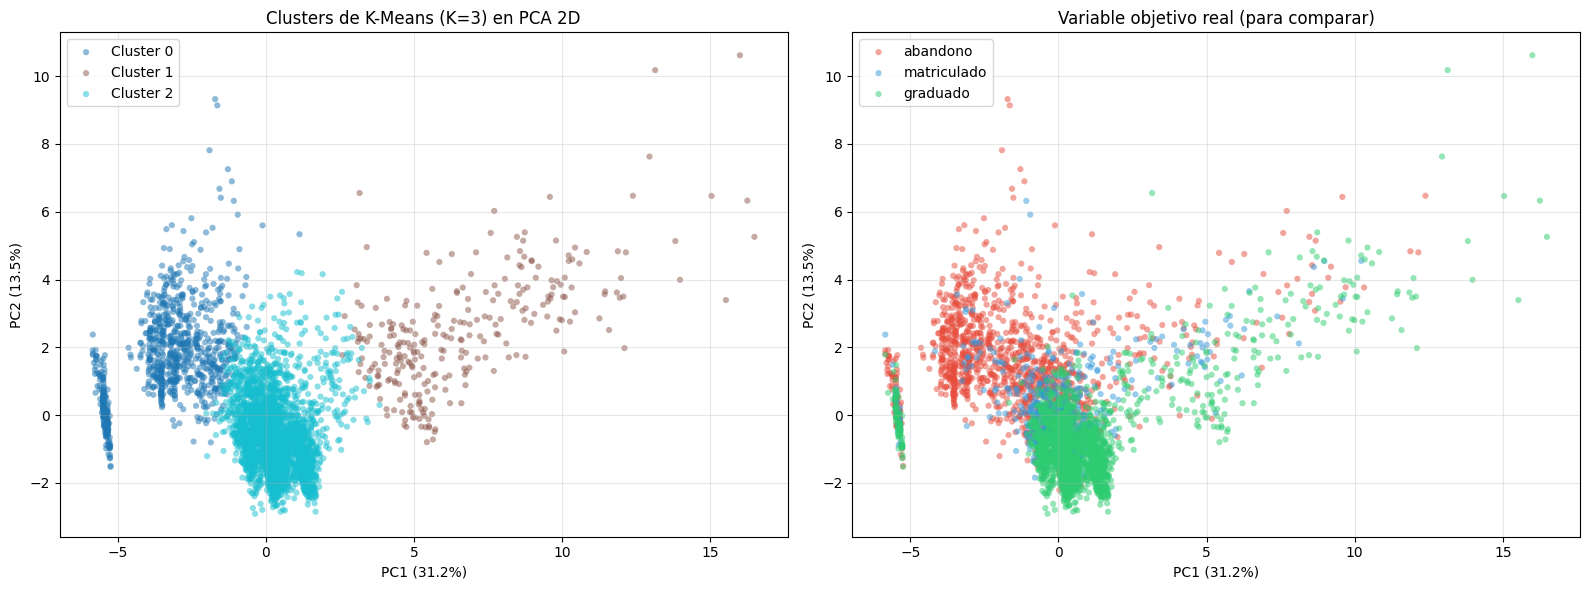

In [64]:
# Seleccionamos K basandonos en los resultados anteriores
# Elegimos el K con mayor silueta (o el mas cercano al codo si la silueta es similar)
K_ELEGIDO = list(k_range)[np.argmax(siluetas)]
print(f'K elegido (maxima silueta): {K_ELEGIDO} (silueta = {max(siluetas):.4f})')

# Aplicamos K-Means con el K elegido
kmeans = KMeans(n_clusters=K_ELEGIDO, random_state=RANDOM_STATE, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_unsup)

# Visualizacion sobre la proyeccion PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coloreado por cluster
colores_clusters = plt.cm.tab10(np.linspace(0, 1, K_ELEGIDO))
for ci in range(K_ELEGIDO):
    mask = clusters_kmeans == ci
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[colores_clusters[ci]], label=f'Cluster {ci}',
                    alpha=0.5, s=20, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'Clusters de K-Means (K={K_ELEGIDO}) en PCA 2D')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Coloreado por objetivo real (comparativa)
for clase in ['abandono', 'matriculado', 'graduado']:
    mask = y_real == clase
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=colores[clase], label=clase,
                    alpha=0.5, s=20, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Variable objetivo real (para comparar)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Al comparar el mapa de clusters (izquierda) con el mapa del target real (derecha) se observa una similitud parcial pero también diferencias importantes.

Los clusters de K-Means **no coinciden exactamente** con las clases del target, lo que ya es un resultado importante, el algoritmo ha descubierto una estructura que no es trivialmente la división en abandono/matriculado/graduado. Uno de los clusters ocupa la región izquierda, exactamente donde se concentran los abandonos, y seguramente contendrá una altísima proporción de ellos. Otro cluster parece ocupar una región muy específica, alejada de la masa central del dataset. El tercero abarca la región central (mas baja y a la derecha de la primera), que es la más poblada.

La caracterización (sección 6.7) nos dirá con exactitud qué representa cada cluster en términos de las variables originales, pero la intuición visual ya sugiere que el algoritmo ha identificado un grupo de "perfil raro" (ese cluster que está alejado de los demás) que no se corresponde con ninguna clase del target.

### 6.5 Clustering jerárquico

El clustering jerárquico (tema 04-02) tiene una filosofía distinta a K-Means. En lugar de particionar los datos en un número fijo de clusters, construye una **jerarquía completa** de agrupaciones en forma de árbol (llamado *dendrograma*). Se puede cortar el árbol a distintas alturas para obtener distintos números de clusters sin necesidad de recalcular nada.

Hay dos enfoques posibles. El **aglomerativo** (bottom-up, o AGNES) empieza considerando cada punto como un cluster individual y va fusionando los dos más similares en cada paso, hasta que queda un único cluster con todos los puntos. El **divisivo** (top-down, o DIANA) hace lo contrario: parte de un único cluster y lo va dividiendo. Scikit-learn implementa el aglomerativo, que es el más común.

La fusión requiere decidir cómo se calcula la distancia entre dos clusters. Esto es el **linkage**, puede ser la distancia mínima entre puntos de ambos grupos (single), la máxima (complete), la media (average), o criterios más sofisticados como el de **Ward**, que fusiona los dos clusters que menos aumenten la varianza total intra-cluster. Usamos Ward, que el temario presenta como una buena elección por defecto, ya que tiende a producir clusters compactos y de tamaño similar.

**Nota práctica.** Con 4424 muestras el dendrograma completo tendría 4424 hojas, imposible de interpretar visualmente. Además es computacionalmente costoso. La solución estándar es calcular el linkage sobre todos los datos (que sí es viable) pero truncar la visualización a los niveles superiores del árbol, donde se ven las fusiones más importantes. Usamos truncate_mode='level' con p=5 para mostrar solo los cinco niveles superiores.

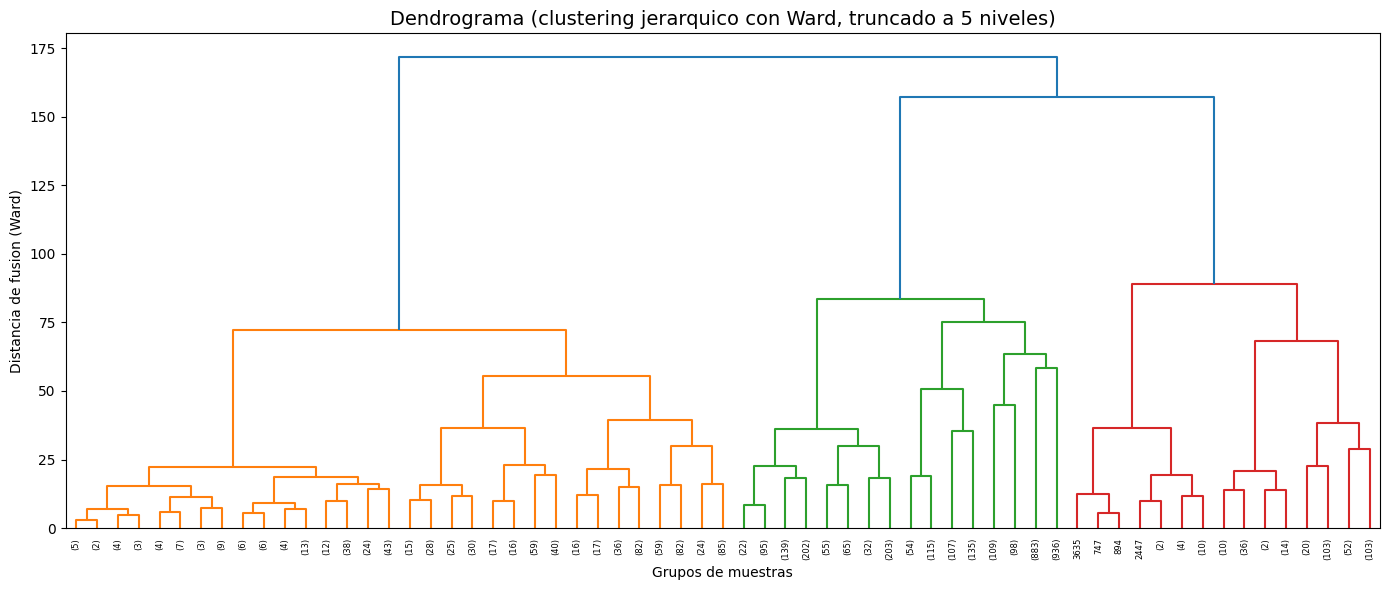

In [65]:
# Para el dendrograma completo seria costoso; usamos una muestra representativa
# y el linkage sobre todos los datos (que si es rapido).
# Alternativamente, truncamos la visualizacion a los niveles superiores.

# Calculamos el linkage de Ward sobre todos los datos escalados
Z = linkage(X_unsup, method='ward')

# Dendrograma truncado a los ultimos niveles (para visualizacion)
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',
    p=5,  # numero de niveles mostrados
    color_threshold=0.7*max(Z[:, 2]),
    ax=ax
)
ax.set_title('Dendrograma (clustering jerarquico con Ward, truncado a 5 niveles)', fontsize=14)
ax.set_xlabel('Grupos de muestras')
ax.set_ylabel('Distancia de fusion (Ward)')
plt.tight_layout()
plt.show()

Las fusiones a mayor altura (en la parte superior del gráfico) corresponden a grupos muy distintos entre sí: para unirlos en uno solo habría que aceptar una gran heterogeneidad interna. Si cortamos cerca de la parte superior obtenemos pocos clusters muy diferentes, mientras que si cortamos más abajo obtenemos más clusters, pero con diferencias menos marcadas.

Los colores asignados por matplotlib al aplicar el color_threshold muestran cómo queda la partición si cortamos a esa altura. Se aprecian claramente dos grandes grupos en los niveles superiores, que al bajar se subdividen. Esta estructura "dos grandes bloques que luego se ramifican" es coherente con K=3: un bloque principal que queda como cluster y otro que se divide en dos subclusters más pequeños.

Cuanto más alto cortemos, menos clusters obtenemos, cuanto más bajo, más. Para elegir dónde cortar buscamos un salto grandey en las alturas de fusión, porque un salto grande indica que unir dos grupos implica perder mucha homogeneidad, y por tanto es buen punto de corte. Después del dendrograma aplicamos AgglomerativeClustering con el mismo K que K-Means para poder compararlos directamente.

Silueta K-Means:            0.3223
Silueta clustering jerarquico: 0.2945

Tabla de contingencia (filas = K-Means, columnas = Jerarquico):
Jerarquico    0    1     2
K-Means                   
0            14  766    91
1           270    0     2
2            76   48  3157


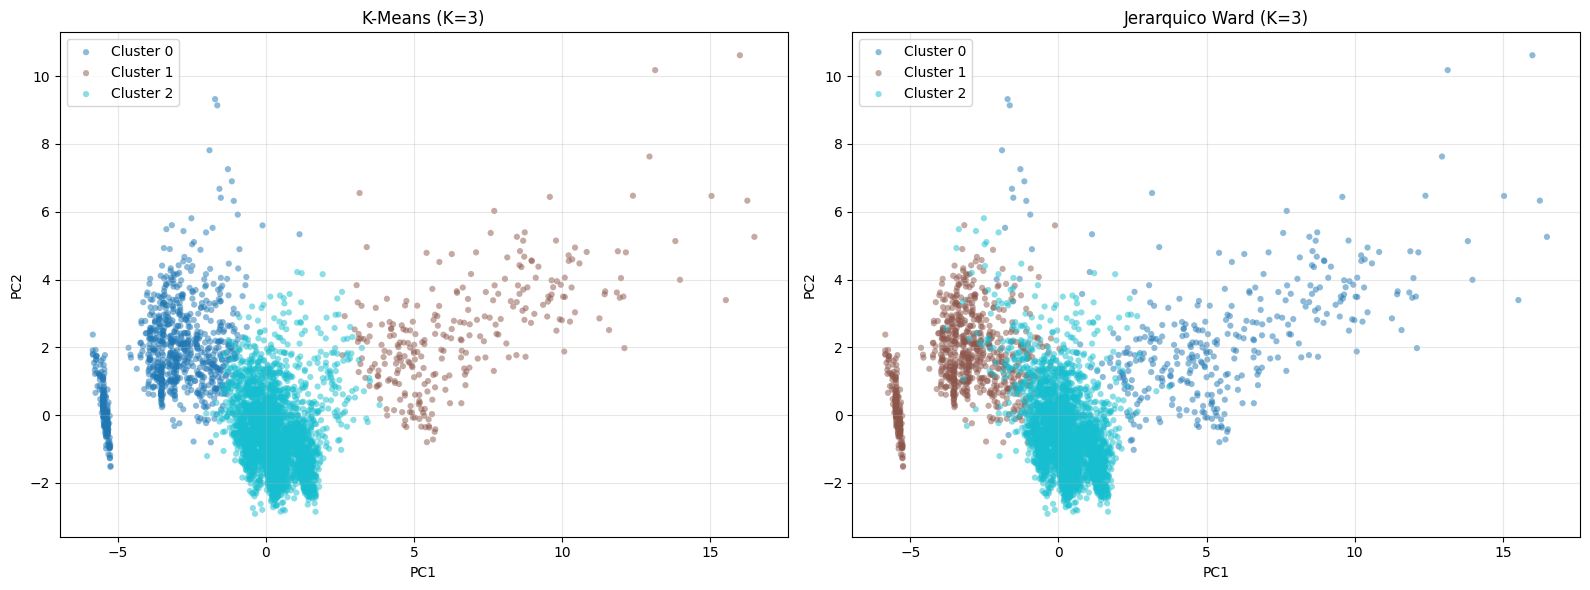

In [66]:
# Clustering jerarquico aglomerativo con el mismo K
agg = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage='ward')
clusters_agg = agg.fit_predict(X_unsup)

# Silueta del clustering jerarquico
sil_agg = silhouette_score(X_unsup, clusters_agg)
print(f'Silueta K-Means:            {max(siluetas):.4f}')
print(f'Silueta clustering jerarquico: {sil_agg:.4f}')

# Tabla de contingencia entre K-Means y jerarquico
contingencia = pd.crosstab(
    pd.Series(clusters_kmeans, name='K-Means'),
    pd.Series(clusters_agg, name='Jerarquico')
)
print(f'\nTabla de contingencia (filas = K-Means, columnas = Jerarquico):')
print(contingencia)

# Visualizacion comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ci in range(K_ELEGIDO):
    mask = clusters_kmeans == ci
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[colores_clusters[ci]], label=f'Cluster {ci}',
                    alpha=0.5, s=20, edgecolors='none')
axes[0].set_title(f'K-Means (K={K_ELEGIDO})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for ci in range(K_ELEGIDO):
    mask = clusters_agg == ci
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[colores_clusters[ci]], label=f'Cluster {ci}',
                    alpha=0.5, s=20, edgecolors='none')
axes[1].set_title(f'Jerarquico Ward (K={K_ELEGIDO})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

K-Means y el clustering jerárquico son dos algoritmos muy distintos en su lógica, así que si coinciden en la estructura que encuentran es una señal muy fuerte de que esa estructura es real.

En silueta, K-Means gana ligeramente (0.3223 frente a 0.2945 del jerárquico). Es una diferencia pequeña pero consistente, y refleja que K-Means está optimizando directamente una métrica relacionada con la silueta (compacidad de clusters), mientras que Ward optimiza una función distinta (minimizar el incremento de varianza al fusionar).

Lo verdaderamente interesante está en la tabla de contingencia, donde los clusters coinciden en gran medida, solo con numeración distinta (lo cual es normal, los números de los clusters son arbitrarios). Concretamente, el cluster 2 de K-Means se corresponde casi íntegramente con el cluster 2 del jerárquico (3157 de 3281 muestras coinciden, un 96%). El cluster 0 de K-Means se corresponde con el cluster 1 del jerárquico (766 de 871, un 88%). Y el cluster 1 de K-Means con el cluster 0 del jerárquico (270 de 272, un 99%).

La conclusión es clara: ambos algoritmos descubren la misma estructura, solo con etiquetas permutadas.

<!-- K-Means y el clustering jerárquico son dos algoritmos muy distintos en su lógica, así que si coinciden en la estructura que encuentran es una señal muy fuerte de que esa estructura es real (y no un artefacto de una técnica en particular).

En silueta, K-Means gana ligeramente (0.3223 frente a 0.2945 del jerárquico). Es una diferencia pequeña pero consistente, y refleja que K-Means está optimizando directamente una métrica relacionada con la silueta (compacidad de clusters), mientras que Ward optimiza una función distinta (minimizar el incremento de varianza al fusionar).

Lo verdaderamente interesante está en la tabla de contingencia, donde los clusters coinciden **en gran medida**, solo con numeración distinta (lo cual es normal, los números de los clusters son arbitrarios). Concretamente, el cluster 2 de K-Means se corresponde casi íntegramente con el cluster 2 del jerárquico (3157 de 3281 muestras coinciden, un 96%). El cluster 0 de K-Means se corresponde con el cluster 1 del jerárquico (766 de 871, un 88%). Y el cluster 1 de K-Means con el cluster 0 del jerárquico (270 de 272, un 99%).

La conclusión es clara: ambos algoritmos descubren la misma estructura, solo con etiquetas permutadas. Es una evidencia importante de que los tres clusters son una característica real del dataset.. -->

### 6.6 Estabilidad de los clusters

El enunciado sugiere, como exploración adicional, *"evaluar la estabilidad de los clusters obtenidos en la parte no supervisada"*. Es una cuestión que merece atención porque K-Means tiene un componente aleatorio, ya que la inicialización de los centroides se hace al azar, y dependiendo de la semilla el algoritmo puede converger a soluciones ligeramente distintas. Si los clusters que encontramos varían mucho entre ejecuciones, es señal de que la estructura no está bien definida en los datos, por el contrario, si se mantienen estables, es indicio de que los clusters son robustos y reales.

Por un lado, ejecutamos K-Means con varias semillas distintas y comparamos la silueta obtenida en cada caso, si es igual (o casi), las particiones son equivalentes en calidad. Por otro, construimos una tabla de contingencia entre dos ejecuciones distintas.

In [67]:
# Ejecutamos K-Means con varias semillas distintas
semillas = [0, 1, 42, 123, 2024]
clusterings = []
siluetas_estab = []

for seed in semillas:
    km = KMeans(n_clusters=K_ELEGIDO, random_state=seed, n_init=10)
    lab = km.fit_predict(X_unsup)
    clusterings.append(lab)
    siluetas_estab.append(silhouette_score(X_unsup, lab))

print(f'Silueta para cada semilla (K={K_ELEGIDO}):')
for s, sil in zip(semillas, siluetas_estab):
    print(f'  seed={s}: {sil:.4f}')
print(f'\nMedia: {np.mean(siluetas_estab):.4f}, std: {np.std(siluetas_estab):.4f}')

# Tabla de contingencia entre ejecuciones 1 y 2 (como ejemplo)
print(f'\nTabla de contingencia entre las dos primeras ejecuciones (seeds {semillas[0]} y {semillas[1]}):')
cont_estab = pd.crosstab(
    pd.Series(clusterings[0], name=f'seed={semillas[0]}'),
    pd.Series(clusterings[1], name=f'seed={semillas[1]}')
)
print(cont_estab)

# Interpretacion: si en cada fila/columna hay una celda con casi toda la masa
# (posiblemente con numeracion de cluster distinta), los clusterings coinciden.

Silueta para cada semilla (K=3):
  seed=0: 0.3223
  seed=1: 0.3223
  seed=42: 0.3223
  seed=123: 0.3223
  seed=2024: 0.3223

Media: 0.3223, std: 0.0000

Tabla de contingencia entre las dos primeras ejecuciones (seeds 0 y 1):
seed=1     0    1    2
seed=0                
0          0  871    0
1       3281    0    0
2          0    0  272


El resultado de la prueba de estabilidad es contundente: los clusters son extremadamente estables.

La silueta es **exactamente igual** (0.3223) en las cinco ejecuciones con semillas distintas, con desviación típica cero. Esto significa que todas las ejecuciones llegan a una partición equivalente en calidad. La tabla de contingencia entre dos ejecuciones distintas confirma que las asignaciones coinciden con una permutación perfecta de los clusters.

Esto implica dos cosas. La primera es que la solución no depende de la inicialización aleatoria, ya que el algoritmo converge siempre al mismo óptimo. La segunda es que tenemos una evidencia adicional de que la estructura descubierta es real, ya que al no variar, podemos confiar en que los tres grupos encontrados reflejan una estructura del dataset.

### 6.6b Estabilidad por perturbación de los datos

El experimento anterior solo varía la inicialización de K-Means manteniendo los mismos datos. Una prueba más exigente de robustez es ver si los clusters siguen siendo los mismos cuando se perturban los datos: si el algoritmo identifica una estructura que es robusta a pequeños cambios en la muestra, podemos confiar en que no es un artefacto de los puntos concretos que se han observado.

Esto se hace tomando subconjuntos aleatorios de los datos y comparando los clusters resultantes con los del clustering original mediante el Adjusted Rand Index (ARI), una métrica que vale 1 cuando dos particiones coinciden perfectamente y 0 cuando son tan parecidas como dos particiones aleatorias. El ARI corrige por azar, así que dos particiones aleatorias no obtienen valores positivos solo por la coincidencia esperada.


In [68]:
# Estabilidad por subsampling: medimos si los clusters se mantienen al perturbar los datos
from sklearn.metrics import adjusted_rand_score

n_repeticiones = 20
fraccion_subsample = 0.8
ari_scores = []
silhouettes_sub = []

# Etiquetas originales (clustering completo, calculado en la seccion 6.4)
clusters_full = clusters_kmeans

rng_sub = np.random.RandomState(RANDOM_STATE)
n_total = X_unsup.shape[0]
n_sub = int(n_total * fraccion_subsample)

for i in range(n_repeticiones):
    idx = rng_sub.choice(n_total, size=n_sub, replace=False)
    X_sub = X_unsup[idx]
    km_sub = KMeans(n_clusters=K_ELEGIDO, random_state=RANDOM_STATE + i, n_init=10)
    labels_sub = km_sub.fit_predict(X_sub)
    # Comparamos con las etiquetas originales restringidas al mismo subconjunto
    ari_scores.append(adjusted_rand_score(clusters_full[idx], labels_sub))
    silhouettes_sub.append(silhouette_score(X_sub, labels_sub))

print(f'Estabilidad por subsampling ({n_repeticiones} reps, {int(fraccion_subsample*100)}% de los datos):')
print(f'  ARI medio:                   {np.mean(ari_scores):.4f}  (std: {np.std(ari_scores):.4f})')
print(f'  ARI minimo:                  {np.min(ari_scores):.4f}')
print(f'  Silueta media en subsamples: {np.mean(silhouettes_sub):.4f}')
print(f'\n  ARI = 1 -> coincidencia perfecta con el clustering original')
print(f'  ARI = 0 -> coincidencia esperable por azar')


Estabilidad por subsampling (20 reps, 80% de los datos):
  ARI medio:                   0.9922  (std: 0.0046)
  ARI minimo:                  0.9799
  Silueta media en subsamples: 0.3226

  ARI = 1 -> coincidencia perfecta con el clustering original
  ARI = 0 -> coincidencia esperable por azar


El ARI medio sale 0.9922 con una desviación típica de 0.0046, y el ARI mínimo de las 20 repeticiones es 0.9799. Estos valores están extremadamente cerca de la coincidencia perfecta y muy lejos de lo que se obtendría por azar (donde el ARI esperado es 0). La silueta media sobre los subconjuntos es 0.3226, prácticamente idéntica a la del clustering completo (0.3223). Esto significa que los clusters se reproducen sin apenas cambios al perturbar la muestra, lo cual confirma que la estructura no depende de los puntos concretos del dataset sino que es una propiedad del fenómeno subyacente.

Combinando este resultado con la estabilidad ante cambio de semilla (sección 6.6), podemos afirmar con bastante seguridad que los tres clusters identificados son una característica genuina del dataset y no un artefacto del algoritmo, de la inicialización aleatoria o de la muestra concreta utilizada.


### 6.7 Caracterización de los clusters

Un cluster no tiene significado por sí mismo. El algoritmo devuelve etiquetas numéricas (0, 1, 2...) pero esos números son arbitrarios: la información real está en los patrones que definen cada grupo. Para interpretar los clusters tenemos que mirar las características que tienen los estudiantes que caen en cada uno.

Se ha decidido calcular las medias (y proporciones, en el caso de las binarias) de las variables originales dentro de cada cluster.

Como ejercicio complementario, miramos cómo se distribuye la variable objetivo real dentro de cada cluster. Además, como el algoritmo no ha usado el target, la comparacion no tiene filtados.

In [69]:
# Caracterizacion: medias de las variables originales por cluster (K-Means)
df_chars = df_unsup.copy()
df_chars['cluster'] = clusters_kmeans
df_chars['objetivo'] = y_real

print(f'Tamano de cada cluster:')
print(df_chars['cluster'].value_counts().sort_index())
print()

print(f'Medias de las variables por cluster:\n')
print(df_chars.groupby('cluster')[df_unsup.columns.tolist()].mean().round(2).T)

Tamano de cada cluster:
cluster
0     871
1     272
2    3281
Name: count, dtype: int64

Medias de las variables por cluster:

cluster                               0       1       2
asignaturas_1sem_matriculadas      4.41   13.31    6.18
asignaturas_1sem_evaluadas         4.71   16.77    8.55
asignaturas_1sem_aprobadas         0.41   11.71    5.27
asignaturas_1sem_convalidadas      0.03    8.79    0.22
asignaturas_1sem_sin_evaluacion    0.25    0.44    0.08
nota_media_1sem                    2.15   12.66   12.73
asignaturas_2sem_matriculadas      4.47   11.58    6.26
asignaturas_2sem_evaluadas         3.85   14.65    8.64
asignaturas_2sem_aprobadas         0.09   10.01    5.13
asignaturas_2sem_convalidadas      0.01    6.82    0.16
asignaturas_2sem_sin_evaluacion    0.29    0.30    0.10
nota_media_2sem                    0.59   12.68   12.59
nota_admision                    126.53  129.48  126.89
nota_cualificacion_previa        132.39  132.01  132.72
edad_al_matricularse             

La caracterización revela tres perfiles de estudiantes bastante reconocibles, pero **no son exactamente** los tres que podrían esperarse (alto / medio / bajo rendimiento). La estructura que ha encontrado el algoritmo es algo distinta:

**Cluster de bajo rendimiento (≈871 estudiantes).** Aprueba casi nada (0.4 asignaturas en 1sem, 0.1 en 2sem), con notas medias extremadamente bajas (2.15 en 1sem, 0.59 en 2sem), muchos sin evaluación. Edad media 26 años. Proporción baja de becados (10%) y alta de deudores (20%). Es el perfil de riesgo claro: el estudiante que apenas se presenta y acumula impagos.

**Cluster minoritario de alta carga académica (≈272 estudiantes).** Llama la atención, se matriculan de muchísimas asignaturas (13.3 en 1sem, 11.6 en 2sem) y aprueban muchísimas también (11.7 y 10.0), con numerosas convalidaciones (8.8 en 1sem). Hay que tener en cuenta que, como las convalidadas están contenidas dentro de las matriculadas y cuentan como aprobadas automáticamente, buena parte de esas 11.7 aprobadas proviene directamente de las convalidaciones. Notas medias relativamente altas (12.7). Edad media algo alta (28.7 años), 91% con matrícula al día. Son probablemente estudiantes con trayectorias académicas previas extensas (segundas carreras, reconocimiento masivo de créditos). Este cluster no existía en los perfiles del EDA y es un descubrimiento que se ha hecho gracias al clustering.

**Cluster principal de alumnado estándar (≈3281 estudiantes).** Carga académica normal (6.2 matriculadas, 5.3 aprobadas en 1sem, cifras similares en 2sem), notas medias altas (12.7). Edad media 22 años, proporción alta de matrícula al día (93%) y de becados (30%), deudores bajos (9%). Es el perfil del estudiante típico.

Esta estructura se aleja de la partición "alto / medio / bajo rendimiento" que podría parecer obvia, el clustering separa por carga académica (o más bien que han sido convalidados, es el pequeño cluster de experimentados con muchas convalidaciones) y por bajo rendimiento (los candidatos a abandono), dejando al resto agrupado en un único cluster grande.


Distribución de objetivo por cluster (proporciones):

objetivo  abandono  graduado  matriculado
cluster                                  
0            0.828     0.087        0.085
1            0.235     0.632        0.132
2            0.194     0.598        0.208


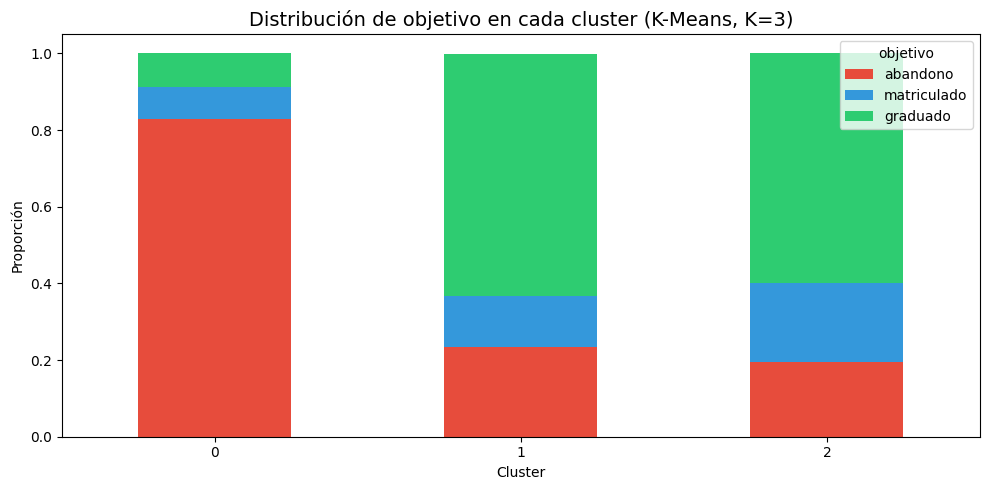

In [70]:
# Distribucion de la variable objetivo por cluster
print('Distribución de objetivo por cluster (proporciones):\n')
dist_obj = pd.crosstab(df_chars['cluster'], df_chars['objetivo'], normalize='index').round(3)
print(dist_obj)

# Grafico
fig, ax = plt.subplots(figsize=(10, 5))
dist_obj[['abandono', 'matriculado', 'graduado']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#e74c3c', '#3498db', '#2ecc71']
)
ax.set_xlabel('Cluster')
ax.set_ylabel('Proporción')
ax.set_title(f'Distribución de objetivo en cada cluster (K-Means, K={K_ELEGIDO})', fontsize=14)
ax.legend(title='objetivo')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Cruzar los clusters con la variable objetivo (que recordemos no se ha usado en ningún paso del pipeline no supervisado) permite validar hasta qué punto la estructura descubierta coincide con la verdadera partición en estados finales.

La tabla de contingencia muestra una correspondencia parcial pero interpretable:

- El cluster de **bajo rendimiento** está muy concentrado en abandonos: **82.8% abandono**, 8.7% graduado, 8.5% matriculado. El algoritmo ha identificado casi de forma perfecta el grupo de riesgo sin haber visto el target.
- El cluster **minoritario de alta carga** tiene 23.5% abandono, **63.2% graduado**, 13.2% matriculado. Mayoritariamente graduados, pero con una fracción no despreciable de abandonos (estudiantes experimentados que igualmente acaban dejando la carrera).
- El cluster **principal** tiene 19.4% abandono, 59.8% graduado, 20.8% matriculado. Es el más heterogéneo: refleja que la mayoría del alumnado estándar acaba graduándose, pero una fracción apreciable queda en matriculado o abandono.

La lectura es positiva con matices. Sin ver el estado final, el clustering no supervisado identifica bastante bien el grupo de abandono aunque se deja algunos fuera (cluster 0), y el resto de estudiantes los agrupa mayoritariamente en un cluster dominado por graduados. La correspondencia con la clase "matriculado" es más débil porque, como ya indicaban los modelos supervisados, esta clase no forma una región propia en el espacio de features, sus estudiantes están repartidos entre los dos clusters grandes.

Este hallazgo valida indirectamente dos cosas, que las variables seleccionadas efectivamente capturan lo esencial del problema (al menos la diferencia entre "abandona" y "no abandona"), y que el estado de matriculado es difícil de analizar.


### 6.8 Observaciones finales de la Tarea 3

La Tarea 3 proporciona resultados coherentes y en línea con lo observado en las tareas supervisadas, lo cual es una validación cruzada implícita.

**PCA.** Las dos primeras componentes explican un 44.7% de la varianza de las 20 variables seleccionadas. PC1 es un eje de rendimiento académico (dominado por asignaturas aprobadas y notas medias) y PC2 un eje relacionado con el perfil de carga académica (matriculadas, convalidadas) y edad. Esta reducción a 2D no captura toda la varianza pero sí la parte más estructurada, para recuperar >90% hacen falta más de 10 componentes.

**K-Means.** El método del codo y el análisis de silueta coinciden en sugerir K=3 como elección razonable (silueta 0.322, claramente por encima de K=2 y muy superior a K≥4). El clustering es extremadamente estable: cinco ejecuciones con distintas semillas dan exactamente la misma partición.

**Jerárquico.** El clustering jerárquico con Ward produce una partición muy similar a K-Means para K=3 (silueta 0.294), con coincidencia superior al 88-99% en cada cluster según la tabla obtenida. Esto refuerza la conclusión de que K=3 es una estructura real del dataset.

**Caracterización.** Los tres clusters corresponden a tres perfiles reconocibles: bajo rendimiento (82.8% abandonos), alta carga académica con muchas convalidaciones (63.2% graduados) y alumnado estándar (59.8% graduados). La correspondencia con la variable objetivo, que no se ha usado en todo el pipeline, valida que la estructura capturada no es arbitraria aunque no coincida exactamente con la partición graduado/matriculado/abandono.

**Limitación principal.** La clase "matriculado" no forma un cluster propio, sus estudiantes están repartidos entre los clusters . Refleja un hecho genuino del problema, los estudiantes en curso tienen patrones de rendimiento parecidos a los de los graduados, pero tambien a los de abandonos, y se convertirán en uno o en otro al acabar sus estudios.



## 7. Interpretación y conclusiones

### 7.1 Tarea de clasificación

El mejor modelo en test es Logistic Regression con F1 ponderado de 0.7617, seguido muy de cerca por Gradient Boosting (0.7582) y Random Forest (0.7562). Accuracy alrededor del 77%. Las clases Graduado (F1≈0.87) y Abandono (F1≈0.77) se predicen bien; Matriculado (F1≈0.45) es la clase más difícil, algo esperable porque es la minoritaria y se solapa con las otras dos en rendimiento académico.

Las variables más importantes son las de rendimiento del 1º y 2º semestre (asignaturas aprobadas, nota media), seguidas por edad y variables administrativas (deudor, becado). El hallazgo principal es que el rendimiento real pesa mucho más que la nota de acceso o el contexto familiar.

El experimento de sample_weight muestra el tradeoff clásico, compensar el desbalanceo sube el recall de Matriculado pero baja el de las clases mayoritarias. Se elige la versión no balanceada porque optimiza mejor el F1 ponderado.

Los intervalos bootstrap confirman que las diferencias entre los tres primeros modelos no son estadísticamente significativas: los IC al 95% se solapan, así que la elección entre ellos es casi indiferente en la práctica.

### 7.2 Tarea de regresión

El mejor modelo es Lasso con R² de 0.7430 en test, RMSE de 2.64 y MAE de 1.55. Elastic Net (0.7424), Ridge (0.7393) y Linear Regression (0.7385) quedan casi empatados con él; Random Forest cae a 0.7248 pese a liderar en CV, por sobreajuste residual; KNN muy por detrás con 0.3272.

Un R² de 0.74 significa que el modelo explica el 74% de la varianza de nota_media_2sem usando solo información disponible antes del segundo semestre. La información del primer semestre es muy predictiva del segundo.

El experimento de selección de variables es también revelador: con solo 21 variables numéricas y binarias el R² cae apenas 0.007 frente a las 100 variables completas (0.7320 vs 0.7393). La mayoría del poder predictivo recae en unas pocas variables.

El análisis de residuos muestra dos limitaciones: el modelo tiende a la media (sobrestima notas bajas y subestima altas) y no anticipa estudiantes que se dejan de presentar. Conviene recordar que nota_media_2sem es un target estructuralmente bimodal (con muchos valores en 0, y luego un salto sin valores hasta llegar al rango [10, 20]), por lo que una regresión lineal no es el modelo teóricamente ideal y parte del R² proviene de la facilidad de separar esos dos regímenes más que de predecir con precisión la nota dentro del régimen de aprobados. La alternativa académica sería un hurdle model, se ha optado por la regresión directa siguiendo el enunciado.

Los intervalos bootstrap para R² confirman que el valor no es causado por azar en la separación, ya que el IC al 95% queda claramente por encima de 0.7, validando un resultado sólido.

### 7.3 Tarea no supervisada

PCA reduce las 20 variables seleccionadas a dos componentes: PC1 (rendimiento académico, 31% de varianza) y PC2 (perfil socioeconómico/edad, 13%). Las dos juntas explican 44.7% de la varianza, suficiente para visualizar la estructura principal. K-Means con K=3 identifica tres clusters muy estables (silueta 0.322, idéntica en 5 semillas), los cuales son: bajo rendimiento (82.8% abandonos), alta carga con muchas convalidaciones (63.2% graduados) y alumnado estándar (59.8% graduados). El clustering jerárquico con Ward confirma la misma estructura (silueta 0.294, coincidencia 88-99% por cluster).

El pipeline no supervisado recupera de forma muy clara el grupo de riesgo (abandonos) usando solo variables de rendimiento, edad y administrativas. La clase de matriculado queda mezclada en los clusters, lo cual es coherente con la dificultad observada en clasificación, pues estos alumnos acabarán siendo abandonos o graduados al final de su etapa.

### 7.4 Conclusiones generales

Un patrón atraviesa las tres tareas: **el rendimiento real del primer semestre es la variable más informativa del problema**, muy por encima de la nota de acceso, la cualificación previa o el contexto familiar. Los sistemas de alerta basados solo en variables de acceso tienen capacidad limitada, seguir el rendimiento del 1er semestre mejora sustancialmente cualquier predicción.

Las variables administrativas (deudor, becado) son indicadores indirectos útiles de la situación del estudiante. La beca muestra un efecto protector claro, ya que reduce la tasa de abandono aproximadamente a la mitad en cada nivel de rendimiento.

El clustering no supervisado identifica con mucha claridad el grupo de abandono, lo que sugiere que una intervención temprana orientada a ese perfil (bajo rendimiento acumulado + impagos + edad media alta) podría actuar sobre estudiantes con riesgo genuino sin necesidad de esperar a la decisión final.

### 7.5 Limitaciones

Dataset único. Los resultados se obtienen con un único conjunto de datos, antes de extrapolar a otras universidades sería necesario validar con datos adicionales.

Variables temporales agregadas. Solo disponemos de agregados por semestre. Una representación más partida (por mes, por asignatura) probablemente permitiría detectar el riesgo antes y con más precisión.

Dificultad intrínseca de la clase Matriculado. Ni en clasificación ni en clustering esta clase forma un grupo propio bien definido, sus estudiantes están en una situación abierta cuyo estado final aún no está determinado.


### 7.6 Respuestas a las preguntas del enunciado

El enunciado del proyecto plantea cuatro preguntas que orientan la lectura del trabajo. Cerramos el informe respondiéndolas de forma directa con los resultados obtenidos.

**¿Qué variables están más asociadas con el abandono?** Las variables de rendimiento académico dominan claramente, especialmente las de asignaturas aprobadas del segundo y primer semestre. Si nos centramos en predicción temprana, las variables del primer semestre son las más útiles antes de disponer de información posterior, en particular asignaturas_1sem_aprobadas y nota_media_1sem, tanto en la importancia por impurezas (sección 4.4) como en la permutation importance (sección 4.4b). Por otro lado, la edad al matricularse es la siguiente en importancia, seguida por las variables administrativas deudor, becado y matricula_al_dia. Las notas previas al ingreso en la universidad, las cuales son nota de admisión y cualificación previa, tienen un peso menor, contrariamente a lo que podría suponerse, lo cual indica que el rendimiento real durante el primer semestre es mucho más informativo que el expediente de acceso para anticipar el abandono.

**¿Qué factores se relacionan con un mejor rendimiento en el segundo semestre?** El primer semestre es prácticamente el único factor que importa, con dos variables, asignaturas_1sem_aprobadas y nota_media_1sem, acaparando la mayor parte del coeficiente estandarizado en Lasso y de la importancia en Random Forest. La sección 5.6 muestra que reduciendo a las 21 variables numéricas y binarias el R² apenas baja 0.007 frente al modelo con 100 variables, lo que confirma que la información del primer semestre concentra casi toda la señal predictiva, es decir, son lor regresores más importantes. Por otro lado, el bloque socioeconómico aporta una corrección menor pero apreciable, mientras que las notas previas y el contexto familiar tienen un papel menos importante.

**¿Existen perfiles de estudiantes con características claramente diferenciadas?**  Sí. El clustering no supervisado identifica de forma estable tres perfiles, un cluster de bajo rendimiento, que concentra el 82.8% de los abandonos, un cluster de con muchas convalidaciones (mayoritariamente graduados, edad media superior, que vienen de otras carreras) y un cluster mayoritario de alumnado estándar. Estos tres perfiles aparecen con K-Means y con clustering jerárquico de Ward, son estables ante el cambio de semilla, como se ha visto en la sección 6.6, y se reproducen al perturbar los datos por subsampling, como se ha observado en la sección 6.6b, lo que confirma que son una característica real del dataset. La sección 2.8b refuerza esta idea identificando perfiles más finos al cruzar variables, como el de caída temprana (buena entrada y mal rendimiento, 49.7% de abandono) o el de riesgo extremo (mayor con impagos, 94%).

**¿Hay variables sobre las que una institución educativa podría actuar para mejorar los resultados?** Sí, distinguiendo dos tipos de variables. Las variables de seguimiento académico (rendimiento del primer semestre) son las más predictivas pero no son acciones, son resultados que la institución observa. Las variables sobre las que una institución sí puede actuar son las administrativas y de apoyo. Las becas tienen un efecto protector claro en el patrón 4 de la sección 2.8b, ya que reducen la tasa de abandono a aproximadamente la mitad en cada nivel de rendimiento, y la situación de pagos (matricula_al_dia, deudor) aparece como factor de riesgo. La sección 4.9 permite ver además, que un sistema de alerta basado solo en información previa al primer semestre cae a F1 = 0.6270 frente a 0.7617 del modelo completo (una pérdida relativa del 17.7%), y que esa pérdida se concentra en la clase Matriculado, justo el grupo que necesitaría una intervención, pues es el que todavia sigue estudiando, lo que sugiere que la estrategia más eficaz para una institución no es hacer una criba de estudiantes en el acceso sino seguir muy de cerca su rendimiento durante las primeras semanas y reaccionar pronto. En conclusión, las acciones institucionales con mejor base empírica en este análisis son tres: política de becas y apoyo económico orientada a perfiles de mayor riesgo, gestión proactiva de impagos antes de que se conviertan en abandono, y un sistema de alerta temprana que monitorice el rendimiento del primer semestre y active intervenciones individuales en cuanto se detecten señales de bajo rendimiento.

### 7.7 Sobre la causalidad de las conclusiones

Todas las conclusiones anteriores deben leerse como asociaciones, no como relaciones causales. Como hemos visto en clase, correlación no implica causalidad. Que la variable matricula_al_dia prediga el abandono no significa que regularizar los pagos prevenga el abandono, ya que ambas pueden ser síntomas de un factor común no observado, como dificultades económicas generales. O por ejemplo, que ser becado reduzca la tasa de abandono a la mitad podría reflejar tanto un efecto causal real (la beca alivia presión económica, haciendo que el estudiante quizas no tenga que trabajar) como un efecto de selección (las becas se conceden a estudiantes con cierto perfil que tendrían menor abandono igualmente), o más probablemente una combinación de ambos.

Establecer causalidad requeriría diseños experimentales, que están fuera del alcance de este trabajo. Las recomendaciones institucionales del apartado anterior se proponen como hipótesis razonables que merecen ser puestas a prueba en grupos controlados, no como intervenciones cuyo efecto esté demostrado.


In [71]:
print('='*60)
print('  PROYECTO FINALIZADO')
print('='*60)
print(f'\nTarea 1 (Clasificación) - Mejor modelo: {mejor_nombre_test}')
print(f'  F1 weighted en test: {mejor_f1_test:.4f}')
print(f'\nTarea 2 (Regresión) - Mejor modelo: {mejor_nombre_reg}')
print(f'  R2 en test: {mejor_r2_test:.4f}')

  PROYECTO FINALIZADO

Tarea 1 (Clasificación) - Mejor modelo: Logistic Regression
  F1 weighted en test: 0.7617

Tarea 2 (Regresión) - Mejor modelo: Lasso (tuned)
  R2 en test: 0.7430
